In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### Importación de datos

In [ ]:

## Dataset en google drive (Carpeta personalizada)
  # df = pd.read_csv("/content/drive/MyDrive/INTELIGENTES/PROYECTO/train.csv")
##Dataset en la misma caarpeta del código
df = pd.read_csv("train.csv")
df.set_index(df["ID"], inplace=True)
df.drop(columns=["ID"], inplace=True)
df.head(10)

In [ ]:
df.shape

(692500, 16)

### Limpieza de datos

Para la limpieza de datos, primero se analizará columna por columna, así como rellenaran valores en blanco y pasará a un formato entrendible por los modelos y luego se generarán funciones de limpieza (importante correr) que harán todo esto sobre el dataset y son los que serán usadas para la generación de modelos.

In [ ]:
df.isnull().sum()

PERIODO                               0
ESTU_PRGM_ACADEMICO                   0
ESTU_PRGM_DEPARTAMENTO                0
ESTU_VALORMATRICULAUNIVERSIDAD     6287
ESTU_HORASSEMANATRABAJA           30857
FAMI_ESTRATOVIVIENDA              32137
FAMI_TIENEINTERNET                26629
FAMI_EDUCACIONPADRE               23178
FAMI_TIENELAVADORA                39773
FAMI_TIENEAUTOMOVIL               43623
ESTU_PRIVADO_LIBERTAD                 0
ESTU_PAGOMATRICULAPROPIO           6498
FAMI_TIENECOMPUTADOR              38103
FAMI_TIENEINTERNET.1              26629
FAMI_EDUCACIONMADRE               23664
RENDIMIENTO_GLOBAL                    0
dtype: int64

In [ ]:
df.dtypes

PERIODO                            int64
ESTU_PRGM_ACADEMICO               object
ESTU_PRGM_DEPARTAMENTO            object
ESTU_VALORMATRICULAUNIVERSIDAD    object
ESTU_HORASSEMANATRABAJA           object
FAMI_ESTRATOVIVIENDA              object
FAMI_TIENEINTERNET                object
FAMI_EDUCACIONPADRE               object
FAMI_TIENELAVADORA                object
FAMI_TIENEAUTOMOVIL               object
ESTU_PRIVADO_LIBERTAD             object
ESTU_PAGOMATRICULAPROPIO          object
FAMI_TIENECOMPUTADOR              object
FAMI_TIENEINTERNET.1              object
FAMI_EDUCACIONMADRE               object
RENDIMIENTO_GLOBAL                object
dtype: object

La mayoria de las variables tienen tipos object, lo cual sugiere que son variables categoricas, mientras unicamente periodo tiene un tipo entero, el cual puede sugerir variable cuantitativa, pero no puede descartarse la posibilidad de que sea una variable catgorica. Estos tipos se definiran en la revisión columna por columns realizada a continuación.

In [ ]:
df.describe(include="all")

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,ESTU_PAGOMATRICULAPROPIO,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET.1,FAMI_EDUCACIONMADRE,RENDIMIENTO_GLOBAL
count,692500.000000,692500,692500,686213,661643,660363,665871,669322,652727,648877,692500,686002,654397,665871,668836,692500
unique,NaN,948,31,8,5,7,2,12,2,2,2,2,2,2,12,4
top,NaN,DERECHO,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,Más de 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,alto
freq,NaN,53244,282159,204048,249352,232671,592514,128289,563390,412606,692466,382201,597670,592514,141744,175619
mean,20198.366679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,10.535037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,20183.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,20195.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,20195.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,20203.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


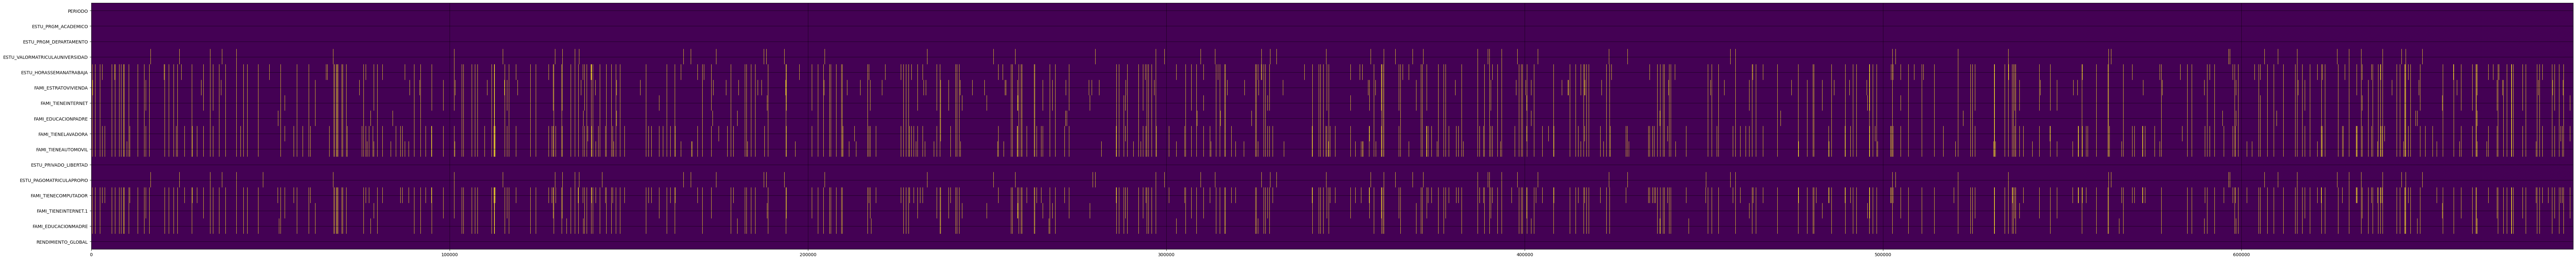

In [ ]:
fig, ax = plt.subplots(figsize=(100, 10))  # Increase the width significantly

# Display the array
cax = ax.imshow(df.isna().values.T, aspect='auto', cmap='viridis', interpolation='none')

# Set y-ticks to column names (if columns are not too many)
plt.yticks(range(df.shape[1]), df.columns)

# Show grid for better separation
ax.grid(True, which='both', color='black', linestyle='-', linewidth=0.5)

plt.show()

Se observan muchos valores vacios en registros únicos, con lo cual posira darse la posibilidad de eliminarse aquellos registros que no tengan al menos el 50% de los datos, pero esto se deja de lado, teniendo encuenta que podrian ser demasiados y se necesitan varios registros para lograr las predicciones complejas. Así pues, nos centraremos en la correcta limpieza y relleno de los datos.

In [ ]:
df_cleanprocess = df.copy()

#### Columna periodo

In [ ]:
df_cleanprocess["PERIODO"].describe()

count    692500.000000
mean      20198.366679
std          10.535037
min       20183.000000
25%       20195.000000
50%       20195.000000
75%       20203.000000
max       20213.000000
Name: PERIODO, dtype: float64

<Axes: xlabel='PERIODO'>

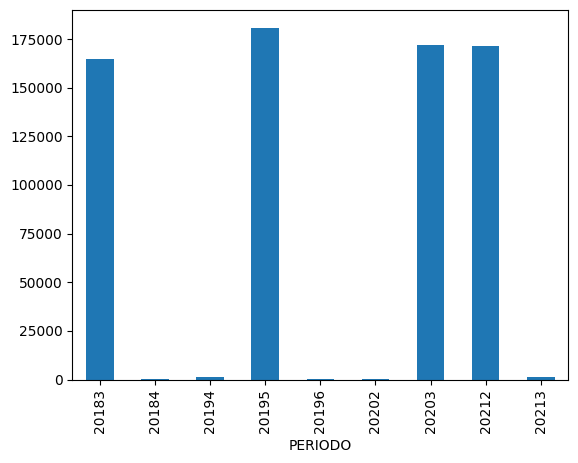

In [ ]:
df_cleanprocess['PERIODO'].value_counts().reindex(np.sort(df_cleanprocess['PERIODO'].unique())).plot(kind="bar")

<Axes: xlabel='PERIODO', ylabel='count'>

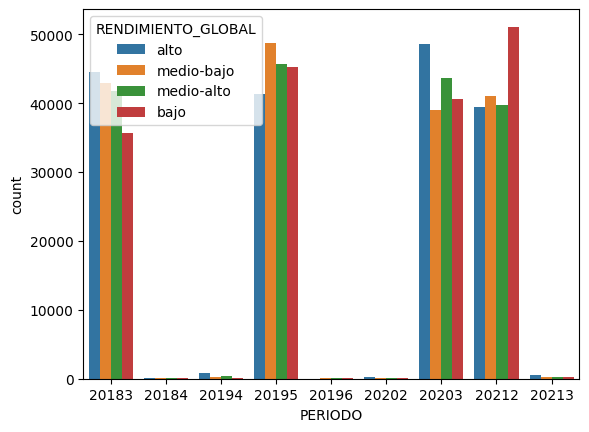

In [ ]:
sns.countplot(df_cleanprocess, x="PERIODO", hue="RENDIMIENTO_GLOBAL")

Variable categorica donde se evidencia muy pocas variables de algunos periodos

In [ ]:
diccPeriods={}
index=0
for period in np.sort(df_cleanprocess['PERIODO'].unique()):
  diccPeriods[index]=period
  index = index+1
df_cleanprocess['PERIODO'].replace(diccPeriods.values(), diccPeriods.keys(), inplace=True)

<Axes: xlabel='PERIODO'>

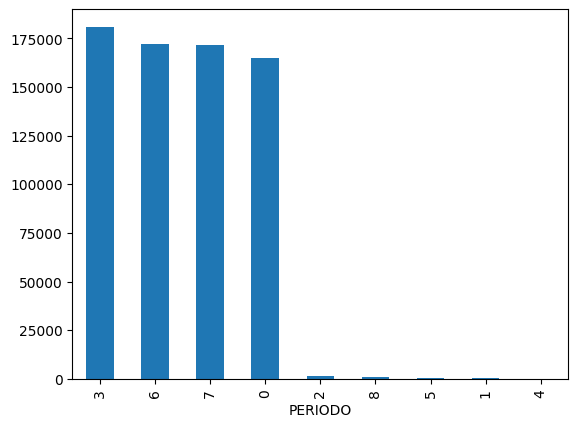

In [ ]:
df_cleanprocess['PERIODO'].value_counts().plot(kind="bar")

#### Columna programa académico

In [ ]:
df_cleanprocess['ESTU_PRGM_ACADEMICO']

ID
904256                             ENFERMERIA
645256                                DERECHO
308367                  MERCADEO Y PUBLICIDAD
470353             ADMINISTRACION DE EMPRESAS
989032                             PSICOLOGIA
                         ...                 
25096                                BIOLOGIA
754213                             PSICOLOGIA
504185    ADMINISTRACIÓN EN SALUD OCUPACIONAL
986620                             PSICOLOGIA
933374                             PSICOLOGIA
Name: ESTU_PRGM_ACADEMICO, Length: 692500, dtype: object

In [ ]:
values = df_cleanprocess['ESTU_PRGM_ACADEMICO'].unique()
dicc= dict()
for i in range(len(values)):
  dicc[i]=values[i]
len(values)
dicc

{0: 'ENFERMERIA',
 1: 'DERECHO',
 2: 'MERCADEO Y PUBLICIDAD',
 3: 'ADMINISTRACION DE EMPRESAS',
 4: 'PSICOLOGIA',
 5: 'MEDICINA VETERINARIA',
 6: 'INGENIERIA MECANICA',
 7: 'ADMINISTRACIÓN EN SALUD OCUPACIONAL',
 8: 'INGENIERIA INDUSTRIAL',
 9: 'ADMINISTRACIÓN FINANCIERA',
 10: 'HOTELERIA Y TURISMO',
 11: 'LICENCIATURA EN CIENCIAS SOCIALES',
 12: 'LICENCIATURA EN PEDAGOGIA INFANTIL',
 13: 'COMUNICACION SOCIAL',
 14: 'CIENCIA POLITICA',
 15: 'PROFESIONAL EN GESTIÓN DE LA SEGURIDAD Y LA SALUD LABORAL',
 16: 'MAESTRO EN MÚSICA',
 17: 'INGENIERIA MECATRONICA',
 18: 'TRABAJO SOCIAL',
 19: 'LICENCIATURA EN BIOLOGIA Y EDUCACION AMBIENTAL',
 20: 'INGENIERIA CIVIL',
 21: 'CONTADURIA PÚBLICA',
 22: 'ADMINISTRACION EN SALUD',
 23: 'ADMINISTRACIÓN DE EMPRESAS',
 24: 'ESTADISTICA',
 25: 'LICENCIATURA EN BIOLOGIA',
 26: 'INGENIERIA AGROINDUSTRIAL',
 27: 'ZOOTECNIA',
 28: 'COMUNICACION AUDIOVISUAL',
 29: 'LICENCIATURA EN EDUCACION BASICA CON ENFASIS EN HUMANIDADES-INGLES',
 30: 'COMUNICACION SOCIAL  

In [ ]:
dicc[1]

'DERECHO'

Variable categorica con muchos posibles valores, variando sus posibles valores tanto en train.csv como en test.csv. Deberia tener one hot encoding pero pueden ser muchas columnas a procesar,

In [ ]:
#opcion 1
# for val in df_cleanprocess['ESTU_PRGM_ACADEMICO']:
#   print(dicc[val])
df_cleanprocess['ESTU_PRGM_ACADEMICO'] = df_cleanprocess['ESTU_PRGM_ACADEMICO'].replace(dicc.values(), dicc.keys())
df_cleanprocess[['ESTU_PRGM_ACADEMICO']]

,ESTU_PRGM_ACADEMICO
ID,
904256,0
645256,1
308367,2
470353,3
989032,4
...,...
25096,148
754213,4
504185,7


In [ ]:
#opcion 2
df_cleanprocessOHE= df.copy()
dfOneHotEncoding = pd.get_dummies(df_cleanprocessOHE[['ESTU_PRGM_ACADEMICO']])
df_cleanprocessOHE=pd.concat([df_cleanprocessOHE,dfOneHotEncoding], axis=1)
df_cleanprocessOHE.drop(columns=['ESTU_PRGM_ACADEMICO'], inplace=True)
df_cleanprocessOHE.head()

,PERIODO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,...,ESTU_PRGM_ACADEMICO_TEOLOGÍA,ESTU_PRGM_ACADEMICO_TERAPIA CARDIORRESPIRATORIA,ESTU_PRGM_ACADEMICO_TERAPIA OCUPACIONAL,ESTU_PRGM_ACADEMICO_TERAPIA RESPIRATORIA,ESTU_PRGM_ACADEMICO_TERAPIAS PSICOSOCIALES,ESTU_PRGM_ACADEMICO_TRABAJO SOCIAL,ESTU_PRGM_ACADEMICO_TRADUCCION INGLES-FRANCES-ESPAÑOL,ESTU_PRGM_ACADEMICO_TURISMO,ESTU_PRGM_ACADEMICO_URBANISMO,ESTU_PRGM_ACADEMICO_ZOOTECNIA
ID,,,,,,,,,,,,,,,,,,,,,
904256,20212,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,...,False,False,False,False,False,False,False,False,False,False
645256,20212,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
308367,20203,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
470353,20195,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
989032,20212,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,...,False,False,False,False,False,False,False,False,False,False


#### Columna programa departamento

In [ ]:
df_cleanprocess["ESTU_PRGM_DEPARTAMENTO"].value_counts()

ESTU_PRGM_DEPARTAMENTO
BOGOTÁ             282159
ANTIOQUIA           83607
VALLE               44588
ATLANTICO           41020
SANTANDER           28828
NORTE SANTANDER     22588
BOLIVAR             20629
BOYACA              14048
CUNDINAMARCA        14018
NARIÑO              13454
RISARALDA           12679
CORDOBA             12188
TOLIMA              11921
CALDAS              11640
CAUCA               11471
HUILA                9995
MAGDALENA            9512
SUCRE                8674
CESAR                8279
QUINDIO              8229
META                 7910
LA GUAJIRA           4778
CHOCO                4289
CAQUETA              2659
CASANARE             1852
PUTUMAYO              795
ARAUCA                589
AMAZONAS               40
GUAVIARE               37
VAUPES                 14
SAN ANDRES             10
Name: count, dtype: int64

<ipython-input-12-b2ceaf6fb09c>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_dept.set_xticklabels(my_plot_dept.get_xticklabels(), rotation=45,


[Text(0, 0, 'BOGOTÁ'),
 Text(1, 0, 'ATLANTICO'),
 Text(2, 0, 'SANTANDER'),
 Text(3, 0, 'ANTIOQUIA'),
 Text(4, 0, 'HUILA'),
 Text(5, 0, 'SUCRE'),
 Text(6, 0, 'CAQUETA'),
 Text(7, 0, 'CUNDINAMARCA'),
 Text(8, 0, 'BOLIVAR'),
 Text(9, 0, 'TOLIMA'),
 Text(10, 0, 'VALLE'),
 Text(11, 0, 'QUINDIO'),
 Text(12, 0, 'RISARALDA'),
 Text(13, 0, 'CORDOBA'),
 Text(14, 0, 'META'),
 Text(15, 0, 'LA GUAJIRA'),
 Text(16, 0, 'BOYACA'),
 Text(17, 0, 'NARIÑO'),
 Text(18, 0, 'CAUCA'),
 Text(19, 0, 'NORTE SANTANDER'),
 Text(20, 0, 'CESAR'),
 Text(21, 0, 'PUTUMAYO'),
 Text(22, 0, 'CALDAS'),
 Text(23, 0, 'MAGDALENA'),
 Text(24, 0, 'CHOCO'),
 Text(25, 0, 'CASANARE'),
 Text(26, 0, 'ARAUCA'),
 Text(27, 0, 'GUAVIARE'),
 Text(28, 0, 'AMAZONAS'),
 Text(29, 0, 'VAUPES'),
 Text(30, 0, 'SAN ANDRES')]

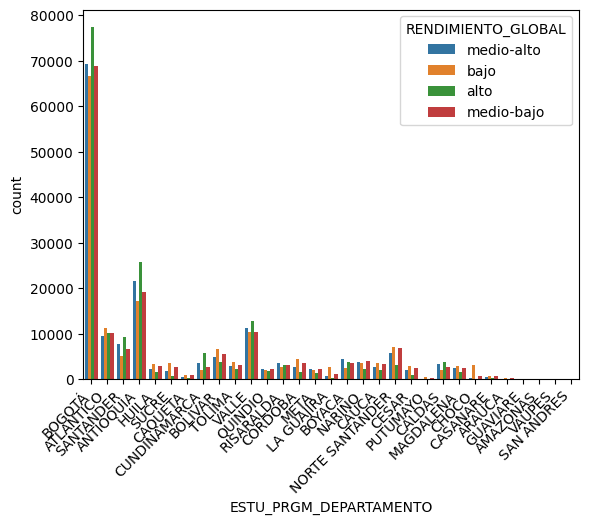

In [ ]:
my_plot_dept= sns.countplot(df_cleanprocess, x="ESTU_PRGM_DEPARTAMENTO", hue="RENDIMIENTO_GLOBAL")
my_plot_dept.set_xticklabels(my_plot_dept.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

Variable categorica que muestra los 30 departamentos de colombia, donde se evidencia que la cantidad de regsitrso depende de la cantidad de población que habita en este departamento-

In [ ]:
valuesDept = df_cleanprocess['ESTU_PRGM_DEPARTAMENTO'].unique()
diccDept= dict()
for i in range(len(valuesDept)):
  diccDept[i]=valuesDept[i]
len(valuesDept)
diccDept

{0: 'BOGOTÁ',
 1: 'ATLANTICO',
 2: 'SANTANDER',
 3: 'ANTIOQUIA',
 4: 'HUILA',
 5: 'SUCRE',
 6: 'CAQUETA',
 7: 'CUNDINAMARCA',
 8: 'BOLIVAR',
 9: 'TOLIMA',
 10: 'VALLE',
 11: 'QUINDIO',
 12: 'RISARALDA',
 13: 'CORDOBA',
 14: 'META',
 15: 'LA GUAJIRA',
 16: 'BOYACA',
 17: 'NARIÑO',
 18: 'CAUCA',
 19: 'NORTE SANTANDER',
 20: 'CESAR',
 21: 'PUTUMAYO',
 22: 'CALDAS',
 23: 'MAGDALENA',
 24: 'CHOCO',
 25: 'CASANARE',
 26: 'ARAUCA',
 27: 'GUAVIARE',
 28: 'AMAZONAS',
 29: 'VAUPES',
 30: 'SAN ANDRES'}

In [ ]:
#Opción 1
df_cleanprocess['ESTU_PRGM_DEPARTAMENTO'] = df_cleanprocess['ESTU_PRGM_DEPARTAMENTO'].replace(diccDept.values(), diccDept.keys())
df_cleanprocess[['ESTU_PRGM_DEPARTAMENTO']]

,ESTU_PRGM_DEPARTAMENTO
ID,
904256,0
645256,1
308367,0
470353,2
989032,3
...,...
25096,15
754213,19
504185,0


In [ ]:
#opcion 2
df_cleanprocessOHE= df.copy()
dfOneHotEncoding = pd.get_dummies(df_cleanprocessOHE[['ESTU_PRGM_DEPARTAMENTO']])
df_cleanprocessOHE=pd.concat([df_cleanprocessOHE,dfOneHotEncoding], axis=1)
df_cleanprocessOHE.drop(columns=['ESTU_PRGM_DEPARTAMENTO'], inplace=True)
df_cleanprocessOHE.head()

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,20212,ENFERMERIA,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,...,False,False,False,False,False,False,False,False,False,False
645256,20212,DERECHO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
308367,20203,MERCADEO Y PUBLICIDAD,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
470353,20195,ADMINISTRACION DE EMPRESAS,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,...,False,False,False,False,False,True,False,False,False,False
989032,20212,PSICOLOGIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,...,False,False,False,False,False,False,False,False,False,False


#### Columna valor matricula

<Axes: xlabel='ESTU_VALORMATRICULAUNIVERSIDAD'>

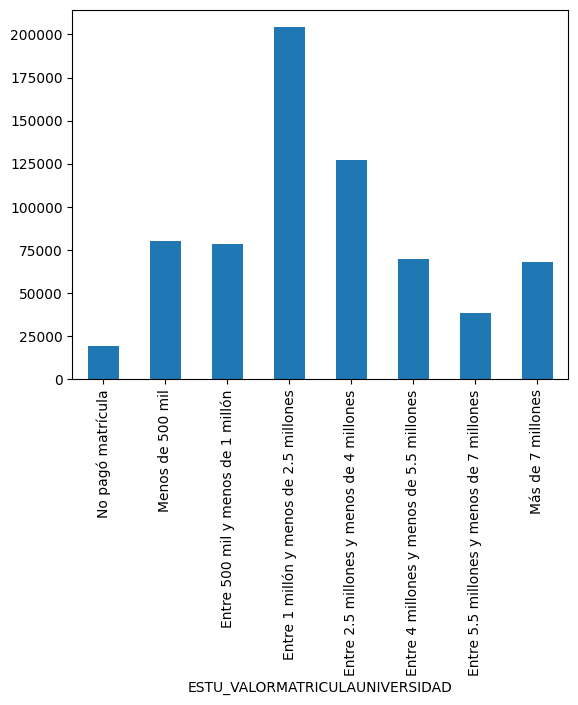

In [ ]:
x_valMatr=["No pagó matrícula", "Menos de 500 mil", "Entre 500 mil y menos de 1 millón", "Entre 1 millón y menos de 2.5 millones", "Entre 2.5 millones y menos de 4 millones",
   "Entre 4 millones y menos de 5.5 millones", "Entre 5.5 millones y menos de 7 millones", "Más de 7 millones"]
df_cleanprocess['ESTU_VALORMATRICULAUNIVERSIDAD'].value_counts().reindex(x_valMatr).plot(kind="bar")

Variable categórica que representa valor matricula universidad, sugiere un orden con lo cual se puede evitar el one hot encoding.

In [ ]:
df_cleanprocess["ESTU_VALORMATRICULAUNIVERSIDAD"].value_counts()

ESTU_VALORMATRICULAUNIVERSIDAD
Entre 1 millón y menos de 2.5 millones      204048
Entre 2.5 millones y menos de 4 millones    127430
Menos de 500 mil                             80263
Entre 500 mil y menos de 1 millón            78704
Entre 4 millones y menos de 5.5 millones     69736
Más de 7 millones                            68014
Entre 5.5 millones y menos de 7 millones     38490
No pagó matrícula                            19528
Name: count, dtype: int64

<ipython-input-14-8c67db593879>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_mat.set_xticklabels(my_plot_mat.get_xticklabels(), rotation=45,


[Text(0, 0, 'Entre 5.5 millones y menos de 7 millones'),
 Text(1, 0, 'Entre 2.5 millones y menos de 4 millones'),
 Text(2, 0, 'Entre 4 millones y menos de 5.5 millones'),
 Text(3, 0, 'Más de 7 millones'),
 Text(4, 0, 'Entre 1 millón y menos de 2.5 millones'),
 Text(5, 0, 'Entre 500 mil y menos de 1 millón'),
 Text(6, 0, 'Menos de 500 mil'),
 Text(7, 0, 'No pagó matrícula')]

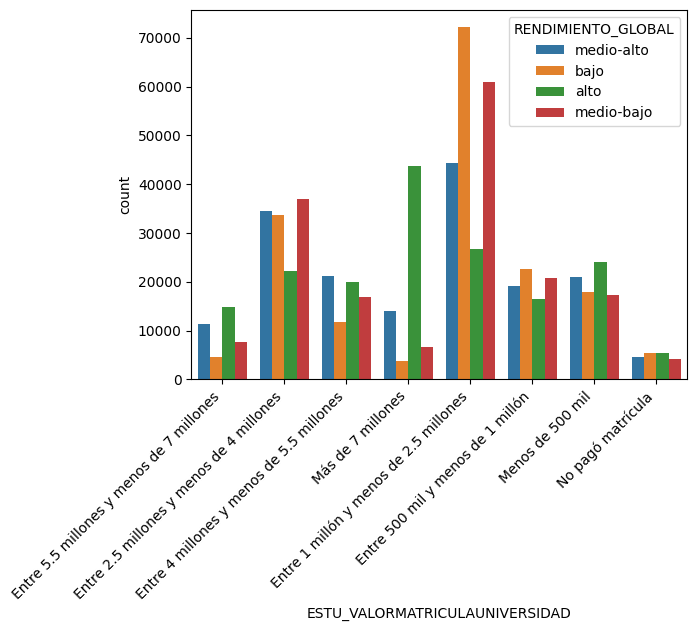

In [ ]:
my_plot_mat= sns.countplot(df_cleanprocess, x="ESTU_VALORMATRICULAUNIVERSIDAD", hue="RENDIMIENTO_GLOBAL")
my_plot_mat.set_xticklabels(my_plot_mat.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

In [ ]:
df_cleanprocess["ESTU_VALORMATRICULAUNIVERSIDAD"].isna().sum()

6287

In [ ]:
df_cleanprocess["ESTU_VALORMATRICULAUNIVERSIDAD"].fillna(df_cleanprocess["ESTU_VALORMATRICULAUNIVERSIDAD"].mode()[0], inplace=True)
df_cleanprocess["ESTU_VALORMATRICULAUNIVERSIDAD"].isna().sum()

0

In [ ]:
diccMatr= dict()
for i in range(len(x_valMatr)):
  diccMatr[i]=x_valMatr[i]
df_cleanprocess['ESTU_VALORMATRICULAUNIVERSIDAD'].replace(diccMatr.values(), diccMatr.keys(), inplace=True)
df_cleanprocess[['ESTU_VALORMATRICULAUNIVERSIDAD']]

,ESTU_VALORMATRICULAUNIVERSIDAD
ID,
904256,6
645256,4
308367,4
470353,5
989032,4
...,...
25096,2
754213,4
504185,3


#### Columna hora semana trabjo

<Axes: xlabel='ESTU_HORASSEMANATRABAJA'>

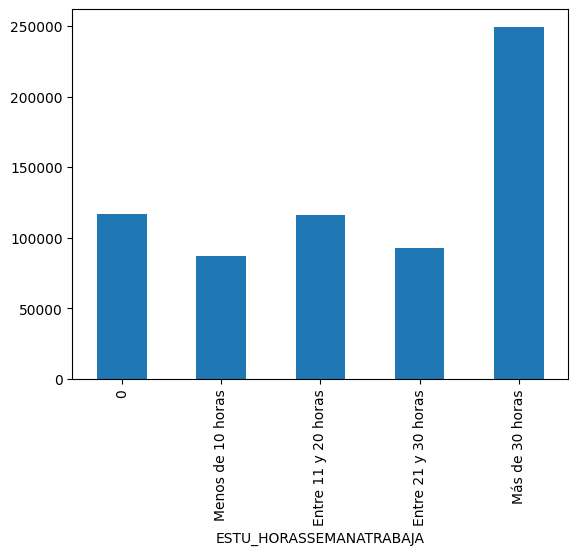

In [ ]:
x_hrTrab=["0", "Menos de 10 horas", "Entre 11 y 20 horas", "Entre 21 y 30 horas", "Más de 30 horas"]
df_cleanprocess['ESTU_HORASSEMANATRABAJA'].value_counts().reindex(x_hrTrab).plot(kind="bar")

Variable categórica de horas de trabajo semanal que infiere un orden (posible evitar one hot encoding)

In [ ]:
df_cleanprocess["ESTU_HORASSEMANATRABAJA"].value_counts()

ESTU_HORASSEMANATRABAJA
Más de 30 horas        249352
0                      116550
Entre 11 y 20 horas    115857
Entre 21 y 30 horas     92693
Menos de 10 horas       87191
Name: count, dtype: int64

<ipython-input-16-5bedcef5b202>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_trab.set_xticklabels(my_plot_trab.get_xticklabels(), rotation=45,


[Text(0, 0, 'Menos de 10 horas'),
 Text(1, 0, '0'),
 Text(2, 0, 'Más de 30 horas'),
 Text(3, 0, 'Entre 21 y 30 horas'),
 Text(4, 0, 'Entre 11 y 20 horas')]

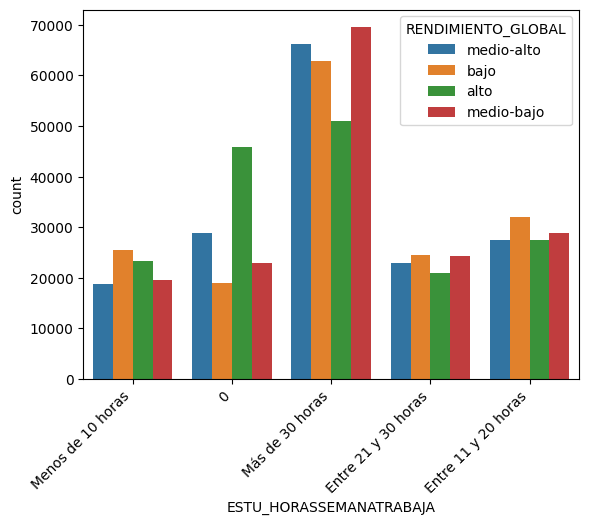

In [ ]:
my_plot_trab= sns.countplot(df_cleanprocess, x="ESTU_HORASSEMANATRABAJA", hue="RENDIMIENTO_GLOBAL")
my_plot_trab.set_xticklabels(my_plot_trab.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

In [ ]:
df_cleanprocess["ESTU_HORASSEMANATRABAJA"].isna().sum()

30857

In [ ]:
df_cleanprocess["ESTU_HORASSEMANATRABAJA"].fillna(df_cleanprocess["ESTU_HORASSEMANATRABAJA"].mode()[0], inplace=True)
df_cleanprocess["ESTU_HORASSEMANATRABAJA"].isna().sum()

0

In [ ]:
dicchrTrab= dict()
for i in range(len(x_hrTrab)):
  dicchrTrab[i]=x_hrTrab[i]
df_cleanprocess['ESTU_HORASSEMANATRABAJA'].replace(dicchrTrab.values(), dicchrTrab.keys(), inplace=True)
df_cleanprocess[['ESTU_HORASSEMANATRABAJA']]

,ESTU_HORASSEMANATRABAJA
ID,
904256,1
645256,0
308367,4
470353,0
989032,3
...,...
25096,2
754213,4
504185,1


#### Columna estrato

<Axes: xlabel='FAMI_ESTRATOVIVIENDA'>

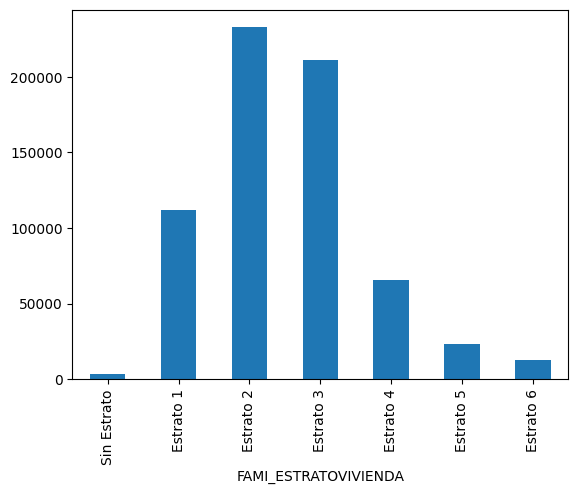

In [ ]:
x_estrat=["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"]
df_cleanprocess['FAMI_ESTRATOVIVIENDA'].value_counts().reindex(x_estrat).plot(kind="bar")

Variable categórica de estrato que infiere un orden (posible evitar one hot encoding)

<ipython-input-17-9d78f5198ada>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_estrato.set_xticklabels(my_plot_estrato.get_xticklabels(), rotation=45,


[Text(0, 0, 'Estrato 3'),
 Text(1, 0, 'Estrato 4'),
 Text(2, 0, 'Estrato 5'),
 Text(3, 0, 'Estrato 2'),
 Text(4, 0, 'Estrato 1'),
 Text(5, 0, 'Estrato 6'),
 Text(6, 0, 'Sin Estrato')]

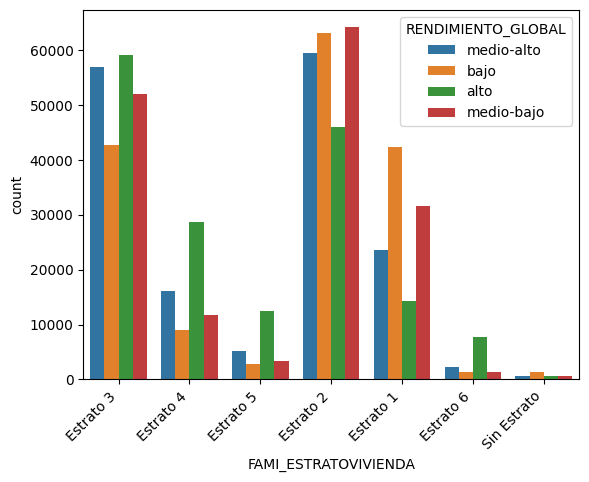

In [ ]:
my_plot_estrato= sns.countplot(df_cleanprocess, x="FAMI_ESTRATOVIVIENDA", hue="RENDIMIENTO_GLOBAL")
my_plot_estrato.set_xticklabels(my_plot_estrato.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

In [ ]:
df_cleanprocess["FAMI_ESTRATOVIVIENDA"].value_counts()

FAMI_ESTRATOVIVIENDA
Estrato 2      232671
Estrato 3      210685
Estrato 1      111991
Estrato 4       65514
Estrato 5       23608
Estrato 6       12605
Sin Estrato      3289
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_ESTRATOVIVIENDA"].isna().sum()

32137

In [ ]:
# Reemplazar por frecuencia puesto que parece haber una clase de sitreibucion en los datos
frequencies = df_cleanprocess['FAMI_ESTRATOVIVIENDA'].value_counts(normalize=True)
na_indices = df_cleanprocess['FAMI_ESTRATOVIVIENDA'][df_cleanprocess['FAMI_ESTRATOVIVIENDA'].isna()].index
filled_values = np.random.choice(frequencies.index, size=len(na_indices), p=frequencies.values)
df_cleanprocess['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values

#Reemplazar por valor más común
# df_cleanprocess["FAMI_ESTRATOVIVIENDA"].fillna(df_cleanprocess["FAMI_ESTRATOVIVIENDA"].mode()[0], inplace=True)

df_cleanprocess["FAMI_ESTRATOVIVIENDA"].isna().sum()

<ipython-input-311-54b0191ac6c9>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values


0

<Axes: xlabel='FAMI_ESTRATOVIVIENDA'>

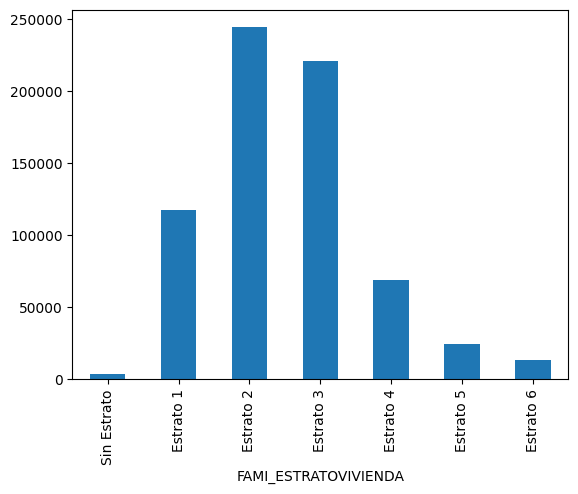

In [ ]:
df_cleanprocess['FAMI_ESTRATOVIVIENDA'].value_counts().reindex(x_estrat).plot(kind='bar')

In [ ]:
diccStrat= dict()
for i in range(len(x_estrat)):
  diccStrat[i]=x_estrat[i]
df_cleanprocess['FAMI_ESTRATOVIVIENDA'].replace(diccStrat.values(), diccStrat.keys(), inplace=True)
df_cleanprocess[['FAMI_ESTRATOVIVIENDA']]

,FAMI_ESTRATOVIVIENDA
ID,
904256,3
645256,3
308367,3
470353,4
989032,3
...,...
25096,2
754213,3
504185,3


#### Columna tiene internet

<Axes: xlabel='FAMI_TIENEINTERNET'>

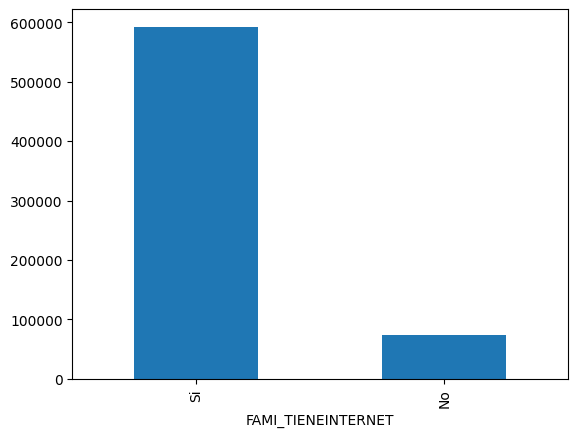

In [ ]:
df_cleanprocess['FAMI_TIENEINTERNET'].value_counts().plot(kind="bar")

Variable binaria que representa la presencia de internet en la casa (categoria).

<Axes: xlabel='FAMI_TIENEINTERNET', ylabel='count'>

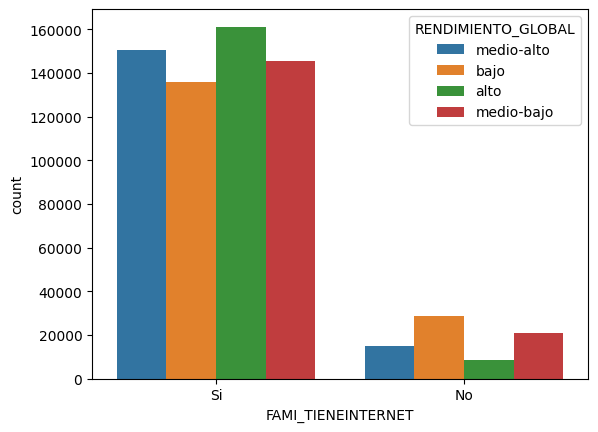

In [ ]:
sns.countplot(df_cleanprocess, x="FAMI_TIENEINTERNET", hue="RENDIMIENTO_GLOBAL")

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET"].value_counts()

FAMI_TIENEINTERNET
Si    592514
No     73357
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET"].isna().sum()

26629

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET"].fillna(df_cleanprocess["FAMI_TIENEINTERNET"].mode()[0], inplace=True)
df_cleanprocess["FAMI_TIENEINTERNET"].isna().sum()

0

In [ ]:
diccBinary={0:"No", 1:"Si"}
df_cleanprocess['FAMI_TIENEINTERNET'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['FAMI_TIENEINTERNET']]

,FAMI_TIENEINTERNET
ID,
904256,1
645256,0
308367,1
470353,1
989032,1
...,...
25096,1
754213,1
504185,1


#### Columna educacion padre

<Axes: xlabel='FAMI_EDUCACIONPADRE'>

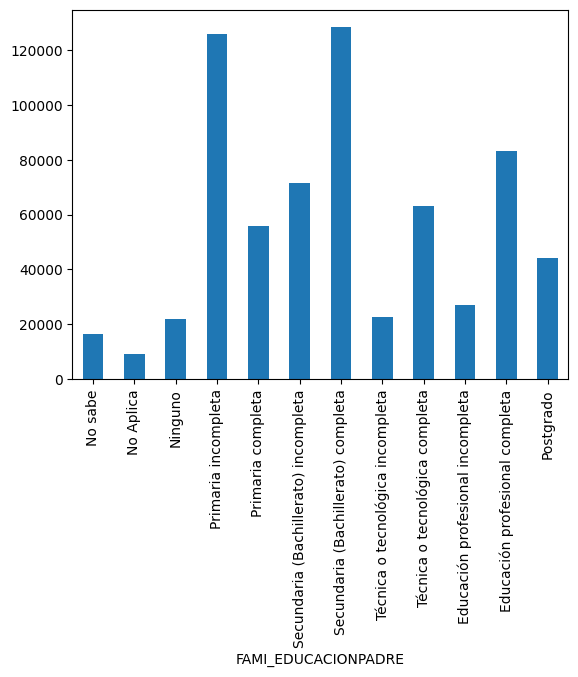

In [ ]:
x_educ=["No sabe", "No Aplica", "Ninguno", "Primaria incompleta", "Primaria completa", "Secundaria (Bachillerato) incompleta", "Secundaria (Bachillerato) completa",
   "Técnica o tecnológica incompleta", "Técnica o tecnológica completa", "Educación profesional incompleta", "Educación profesional completa", "Postgrado"]
df_cleanprocess['FAMI_EDUCACIONPADRE'].value_counts().reindex(x_educ).plot(kind="bar")

Variable categórica de educación de padre que infiere un orden (posible evitar one hot encoding)

<ipython-input-19-e087e19df370>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_edPad.set_xticklabels(my_plot_edPad.get_xticklabels(), rotation=45,


[Text(0, 0, 'Técnica o tecnológica incompleta'),
 Text(1, 0, 'Técnica o tecnológica completa'),
 Text(2, 0, 'Secundaria (Bachillerato) completa'),
 Text(3, 0, 'No sabe'),
 Text(4, 0, 'Primaria completa'),
 Text(5, 0, 'Educación profesional completa'),
 Text(6, 0, 'Educación profesional incompleta'),
 Text(7, 0, 'Primaria incompleta'),
 Text(8, 0, 'Postgrado'),
 Text(9, 0, 'Secundaria (Bachillerato) incompleta'),
 Text(10, 0, 'Ninguno'),
 Text(11, 0, 'No Aplica')]

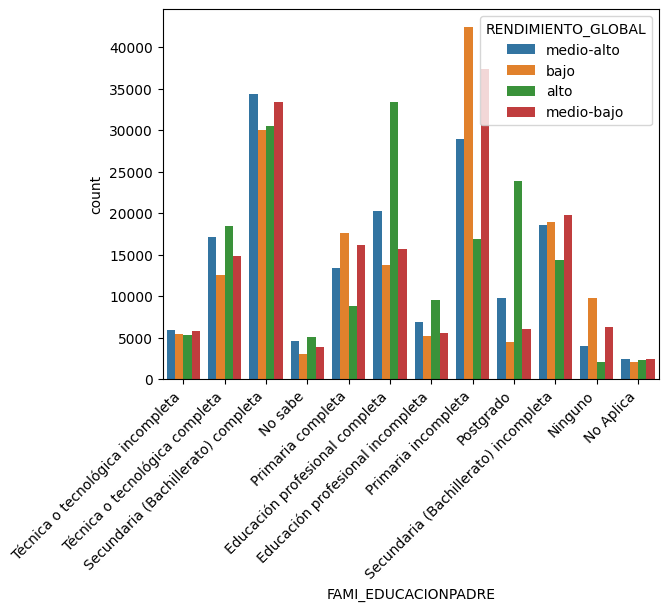

In [ ]:
my_plot_edPad= sns.countplot(df_cleanprocess, x="FAMI_EDUCACIONPADRE", hue="RENDIMIENTO_GLOBAL")
my_plot_edPad.set_xticklabels(my_plot_edPad.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

In [ ]:
df_cleanprocess["FAMI_EDUCACIONPADRE"].value_counts()

FAMI_EDUCACIONPADRE
Secundaria (Bachillerato) completa      128289
Primaria incompleta                     125675
Educación profesional completa           83117
Secundaria (Bachillerato) incompleta     71654
Técnica o tecnológica completa           62995
Primaria completa                        55958
Postgrado                                44169
Educación profesional incompleta         27084
Técnica o tecnológica incompleta         22552
Ninguno                                  22008
No sabe                                  16592
No Aplica                                 9229
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_EDUCACIONPADRE"].isna().sum()

23178

In [ ]:
df_cleanprocess["FAMI_EDUCACIONPADRE"].fillna(df_cleanprocess["FAMI_EDUCACIONPADRE"].mode()[0], inplace=True)
df_cleanprocess["FAMI_EDUCACIONPADRE"].isna().sum()

0

In [ ]:
diccEduc= dict()
for i in range(len(x_educ)):
  diccEduc[i]=x_educ[i]
df_cleanprocess['FAMI_EDUCACIONPADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)
df_cleanprocess[['FAMI_EDUCACIONPADRE']]

,FAMI_EDUCACIONPADRE
ID,
904256,7
645256,8
308367,6
470353,0
989032,4
...,...
25096,6
754213,3
504185,6


#### Columna tiene lavadora

<Axes: xlabel='FAMI_TIENELAVADORA'>

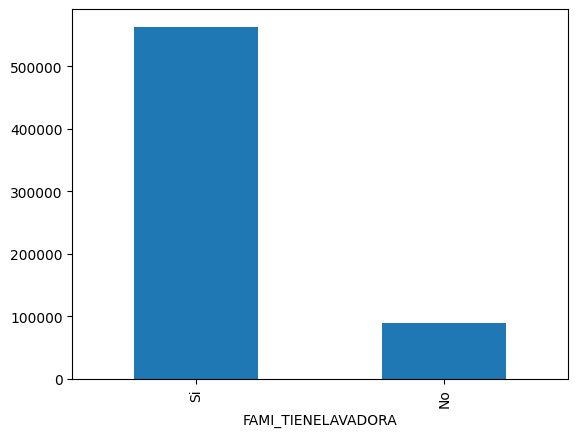

In [ ]:
df_cleanprocess['FAMI_TIENELAVADORA'].value_counts().plot(kind="bar")

<Axes: xlabel='FAMI_TIENELAVADORA', ylabel='count'>

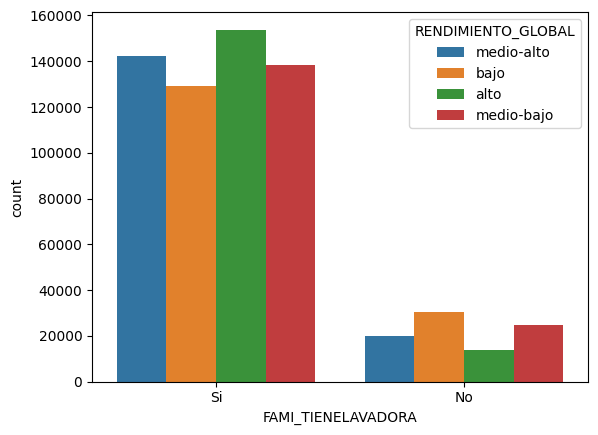

In [ ]:
sns.countplot(df_cleanprocess, x="FAMI_TIENELAVADORA", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa lavadora en la casa (categoria).

In [ ]:
df_cleanprocess["FAMI_TIENELAVADORA"].value_counts()

FAMI_TIENELAVADORA
Si    563390
No     89337
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_TIENELAVADORA"].isna().sum()

39773

In [ ]:
df_cleanprocess["FAMI_TIENELAVADORA"].fillna(df_cleanprocess["FAMI_TIENELAVADORA"].mode()[0], inplace=True)
df_cleanprocess["FAMI_TIENELAVADORA"].isna().sum()

0

In [ ]:
df_cleanprocess['FAMI_TIENELAVADORA'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['FAMI_TIENELAVADORA']]

,FAMI_TIENELAVADORA
ID,
904256,1
645256,1
308367,1
470353,1
989032,1
...,...
25096,1
754213,1
504185,1


#### Columna tiene automovil

<Axes: xlabel='FAMI_TIENEAUTOMOVIL'>

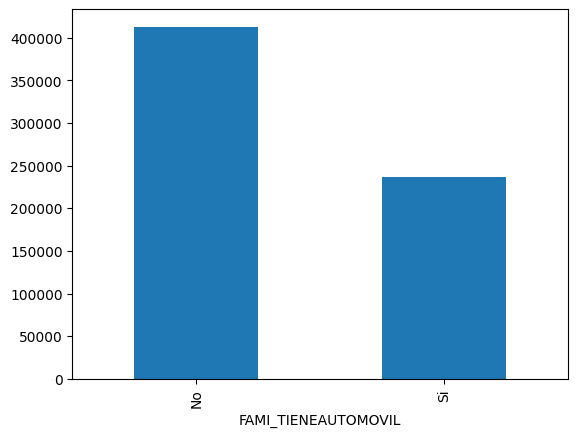

In [ ]:
df_cleanprocess['FAMI_TIENEAUTOMOVIL'].value_counts().plot(kind="bar")

<Axes: xlabel='FAMI_TIENEAUTOMOVIL', ylabel='count'>

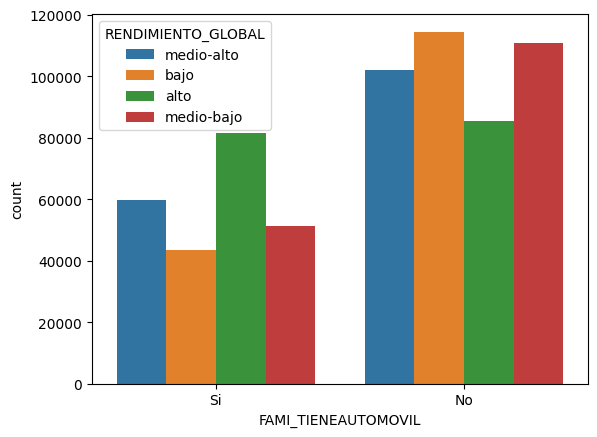

In [ ]:
sns.countplot(df_cleanprocess, x="FAMI_TIENEAUTOMOVIL", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa la presencia de auto en la familia (categoria).

In [ ]:
df_cleanprocess["FAMI_TIENEAUTOMOVIL"].value_counts()

FAMI_TIENEAUTOMOVIL
No    412606
Si    236271
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_TIENEAUTOMOVIL"].isna().sum()

43623

In [ ]:
df_cleanprocess["FAMI_TIENEAUTOMOVIL"].fillna(df_cleanprocess["FAMI_TIENEAUTOMOVIL"].mode()[0], inplace=True)
df_cleanprocess["FAMI_TIENEAUTOMOVIL"].isna().sum()

0

In [ ]:
df_cleanprocess['FAMI_TIENEAUTOMOVIL'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['FAMI_TIENEAUTOMOVIL']]

,FAMI_TIENEAUTOMOVIL
ID,
904256,1
645256,0
308367,0
470353,0
989032,1
...,...
25096,0
754213,0
504185,0


#### Columna pago matricula

<Axes: xlabel='ESTU_PAGOMATRICULAPROPIO'>

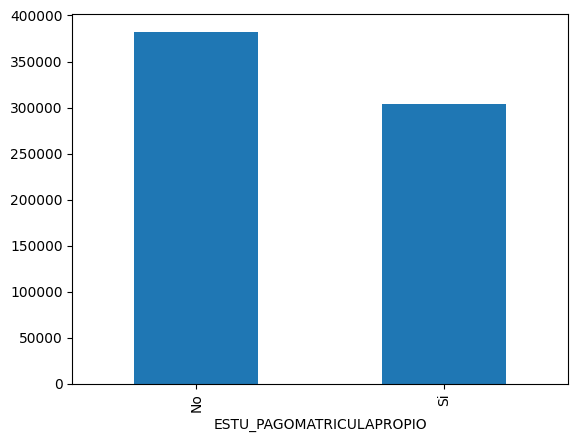

In [ ]:
df_cleanprocess['ESTU_PAGOMATRICULAPROPIO'].value_counts().plot(kind="bar")

<Axes: xlabel='ESTU_PAGOMATRICULAPROPIO', ylabel='count'>

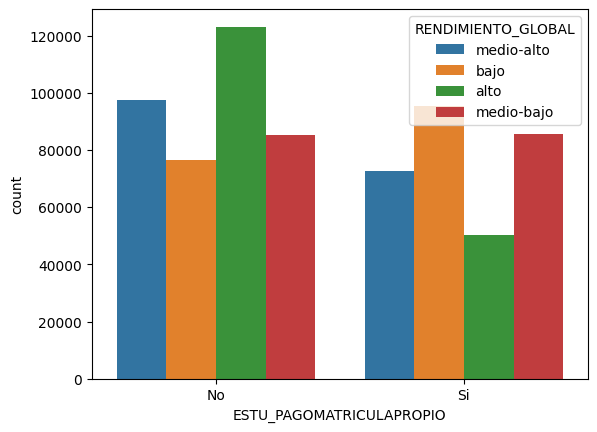

In [ ]:
sns.countplot(df_cleanprocess, x="ESTU_PAGOMATRICULAPROPIO", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa el pago de matricula por parte del propio afectado en el registro (categoria).

In [ ]:
df_cleanprocess["ESTU_PAGOMATRICULAPROPIO"].value_counts()

ESTU_PAGOMATRICULAPROPIO
No    382201
Si    303801
Name: count, dtype: int64

In [ ]:
df_cleanprocess["ESTU_PAGOMATRICULAPROPIO"].isna().sum()

6498

In [ ]:
df_cleanprocess["ESTU_PAGOMATRICULAPROPIO"].fillna(df_cleanprocess["ESTU_PAGOMATRICULAPROPIO"].mode()[0], inplace=True)
df_cleanprocess["ESTU_PAGOMATRICULAPROPIO"].isna().sum()

0

In [ ]:
df_cleanprocess['ESTU_PAGOMATRICULAPROPIO'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['ESTU_PAGOMATRICULAPROPIO']]

,ESTU_PAGOMATRICULAPROPIO
ID,
904256,0
645256,0
308367,0
470353,0
989032,0
...,...
25096,1
754213,0
504185,1


#### Columna tiene computador

<Axes: xlabel='FAMI_TIENECOMPUTADOR'>

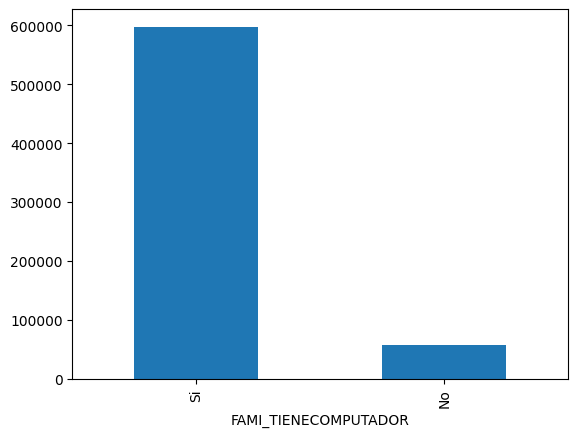

In [ ]:
df_cleanprocess['FAMI_TIENECOMPUTADOR'].value_counts().plot(kind="bar")

<Axes: xlabel='FAMI_TIENECOMPUTADOR', ylabel='count'>

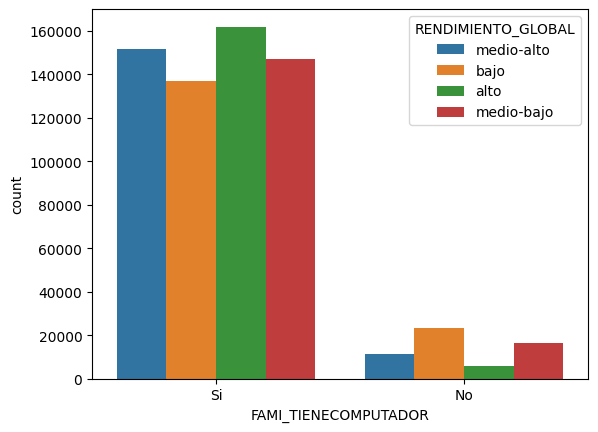

In [ ]:
sns.countplot(df_cleanprocess, x="FAMI_TIENECOMPUTADOR", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa la presencia de computador en la casa (categoria).

In [ ]:
df_cleanprocess["FAMI_TIENECOMPUTADOR"].value_counts()

FAMI_TIENECOMPUTADOR
Si    597670
No     56727
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_TIENECOMPUTADOR"].isna().sum()

38103

In [ ]:
df_cleanprocess["FAMI_TIENECOMPUTADOR"].fillna(df_cleanprocess["FAMI_TIENECOMPUTADOR"].mode()[0], inplace=True)
df_cleanprocess["FAMI_TIENECOMPUTADOR"].isna().sum()

0

In [ ]:
df_cleanprocess['FAMI_TIENECOMPUTADOR'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['FAMI_TIENECOMPUTADOR']]

,FAMI_TIENECOMPUTADOR
ID,
904256,1
645256,1
308367,0
470353,1
989032,1
...,...
25096,1
754213,1
504185,1


#### Columna tiene internet 2

<Axes: xlabel='FAMI_TIENEINTERNET.1'>

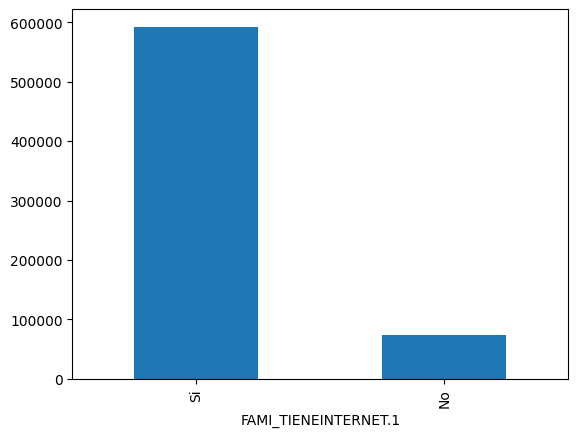

In [ ]:
df_cleanprocess['FAMI_TIENEINTERNET.1'].value_counts().plot(kind="bar")

<Axes: xlabel='FAMI_TIENEINTERNET.1', ylabel='count'>

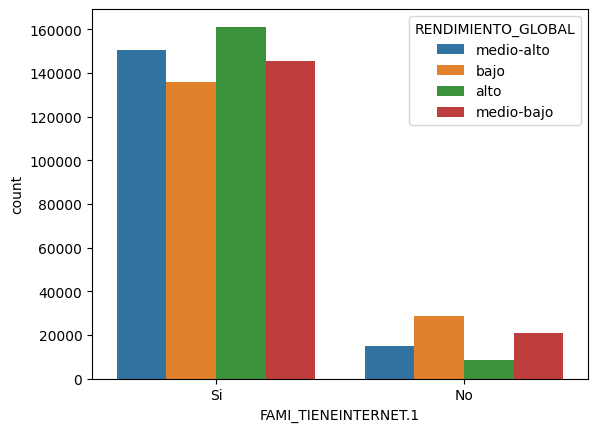

In [ ]:
sns.countplot(df_cleanprocess, x="FAMI_TIENEINTERNET.1", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa la presencia de internet en la casa (categoria).

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET.1"].value_counts()

FAMI_TIENEINTERNET.1
Si    592514
No     73357
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET.1"].isna().sum()

26629

In [ ]:
df_cleanprocess["FAMI_TIENEINTERNET.1"].fillna(df_cleanprocess["FAMI_TIENEINTERNET.1"].mode()[0], inplace=True)
df_cleanprocess["FAMI_TIENEINTERNET.1"].isna().sum()

0

In [ ]:
df_cleanprocess['FAMI_TIENEINTERNET.1'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)
df_cleanprocess[['FAMI_TIENEINTERNET.1']]

,FAMI_TIENEINTERNET.1
ID,
904256,1
645256,0
308367,1
470353,1
989032,1
...,...
25096,1
754213,1
504185,1


#### Columna educación madre

<Axes: xlabel='FAMI_EDUCACIONMADRE'>

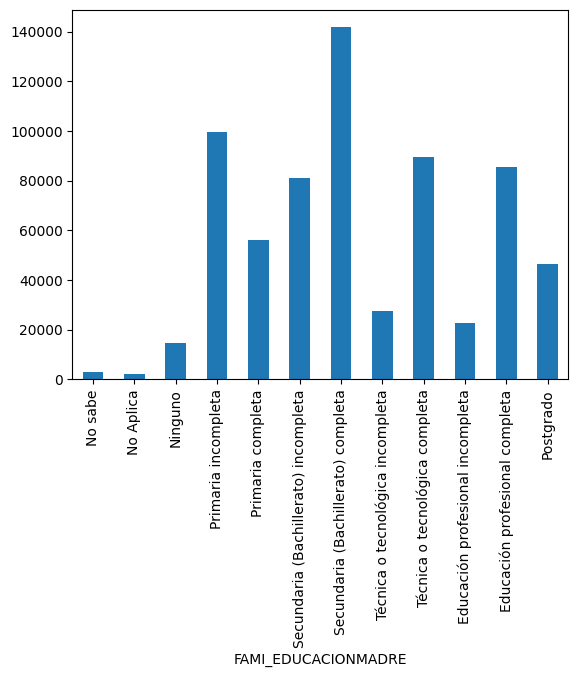

In [ ]:
df_cleanprocess['FAMI_EDUCACIONMADRE'].value_counts().reindex(x_educ).plot(kind="bar")

<ipython-input-26-13036feae1c6>:2: UserWarning: FixedFormatter should only be used together with FixedLocator
  my_plot_edMad.set_xticklabels(my_plot_edMad.get_xticklabels(), rotation=45,


[Text(0, 0, 'Postgrado'),
 Text(1, 0, 'Técnica o tecnológica incompleta'),
 Text(2, 0, 'Secundaria (Bachillerato) completa'),
 Text(3, 0, 'Primaria completa'),
 Text(4, 0, 'Técnica o tecnológica completa'),
 Text(5, 0, 'Secundaria (Bachillerato) incompleta'),
 Text(6, 0, 'Educación profesional incompleta'),
 Text(7, 0, 'Educación profesional completa'),
 Text(8, 0, 'Primaria incompleta'),
 Text(9, 0, 'Ninguno'),
 Text(10, 0, 'No Aplica'),
 Text(11, 0, 'No sabe')]

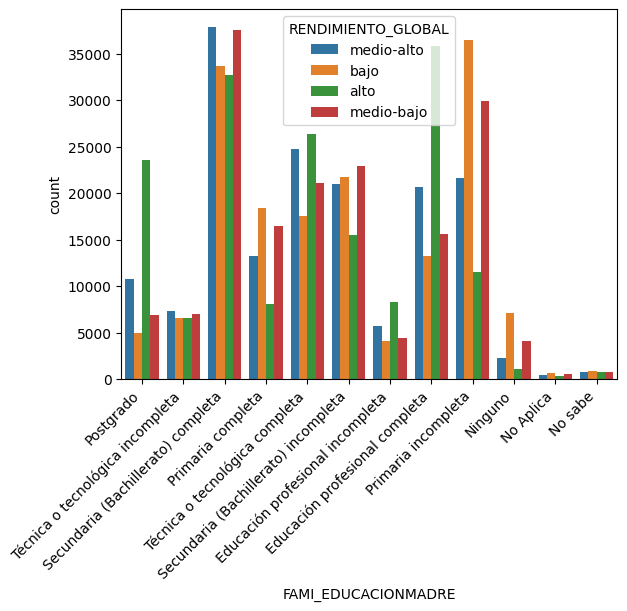

In [ ]:
my_plot_edMad= sns.countplot(df_cleanprocess, x="FAMI_EDUCACIONMADRE", hue="RENDIMIENTO_GLOBAL")
my_plot_edMad.set_xticklabels(my_plot_edMad.get_xticklabels(), rotation=45,
                        horizontalalignment='right')

Variable categórica de educación de la madre que infiere un orden (posible evitar one hot encoding)

In [ ]:
df_cleanprocess["FAMI_EDUCACIONMADRE"].value_counts()

FAMI_EDUCACIONMADRE
Secundaria (Bachillerato) completa      141744
Primaria incompleta                      99420
Técnica o tecnológica completa           89542
Educación profesional completa           85326
Secundaria (Bachillerato) incompleta     81012
Primaria completa                        56125
Postgrado                                46246
Técnica o tecnológica incompleta         27533
Educación profesional incompleta         22470
Ninguno                                  14483
No sabe                                   3017
No Aplica                                 1918
Name: count, dtype: int64

In [ ]:
df_cleanprocess["FAMI_EDUCACIONMADRE"].isna().sum()

23664

In [ ]:
df_cleanprocess["FAMI_EDUCACIONMADRE"].fillna(df_cleanprocess["FAMI_EDUCACIONMADRE"].mode()[0], inplace=True)
df_cleanprocess["FAMI_EDUCACIONMADRE"].isna().sum()

0

In [ ]:
df_cleanprocess['FAMI_EDUCACIONMADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)
df_cleanprocess[['FAMI_EDUCACIONMADRE']]

,FAMI_EDUCACIONMADRE
ID,
904256,11
645256,7
308367,6
470353,6
989032,4
...,...
25096,5
754213,5
504185,5


#### Columna estuvo privado de la libertad

<Axes: xlabel='ESTU_PRIVADO_LIBERTAD'>

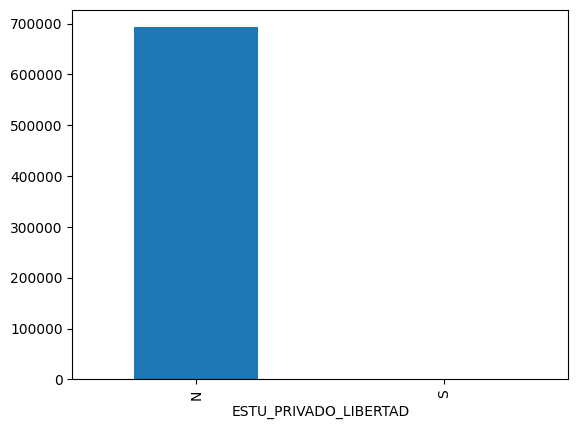

In [ ]:
df_cleanprocess['ESTU_PRIVADO_LIBERTAD'].value_counts().plot(kind="bar")

<Axes: xlabel='ESTU_PRIVADO_LIBERTAD', ylabel='count'>

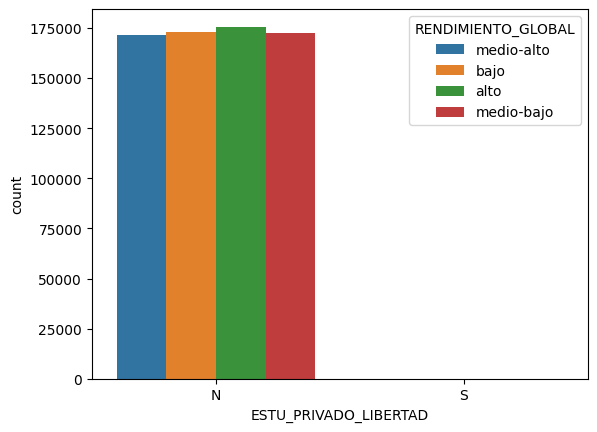

In [ ]:
sns.countplot(df_cleanprocess, x="ESTU_PRIVADO_LIBERTAD", hue="RENDIMIENTO_GLOBAL")

<Axes: xlabel='ESTU_PRIVADO_LIBERTAD', ylabel='count'>

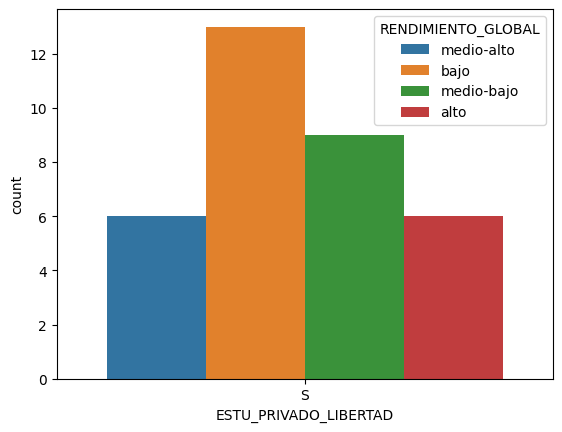

In [ ]:
sns.countplot(df_cleanprocess[df_cleanprocess["ESTU_PRIVADO_LIBERTAD"]=="S"], x="ESTU_PRIVADO_LIBERTAD", hue="RENDIMIENTO_GLOBAL")

Variable binaria que representa si la persona estuvo privada de la libertad en algún momento de su vida (categoria).

<Axes: xlabel='ESTU_PRIVADO_LIBERTAD', ylabel='RENDIMIENTO_GLOBAL'>

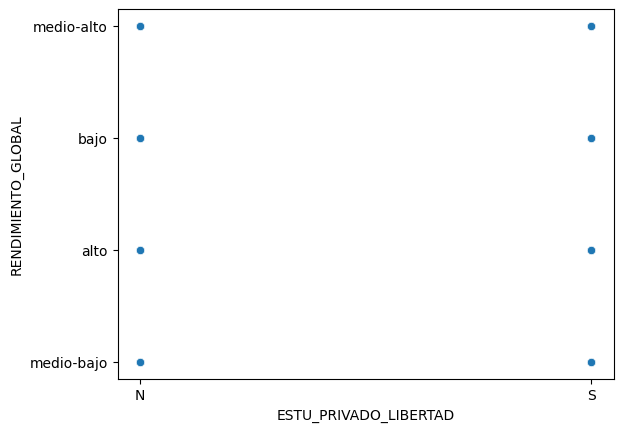

In [ ]:
sns.scatterplot(x="ESTU_PRIVADO_LIBERTAD", y="RENDIMIENTO_GLOBAL", data=df_cleanprocess)

In [ ]:
df_cleanprocess["ESTU_PRIVADO_LIBERTAD"].value_counts()

ESTU_PRIVADO_LIBERTAD
N    692466
S        34
Name: count, dtype: int64

In [ ]:
df_cleanprocess["ESTU_PRIVADO_LIBERTAD"].isna().sum()

0

In [ ]:
diccBinary2 ={0:"N", 1:"S"}
df_cleanprocess['ESTU_PRIVADO_LIBERTAD'].replace(diccBinary2.values(), diccBinary2.keys(), inplace=True)
df_cleanprocess[['ESTU_PRIVADO_LIBERTAD']]

,ESTU_PRIVADO_LIBERTAD
ID,
904256,0
645256,0
308367,0
470353,0
989032,0
...,...
25096,0
754213,0
504185,0


#### Columna rendimiento global

<Axes: xlabel='RENDIMIENTO_GLOBAL'>

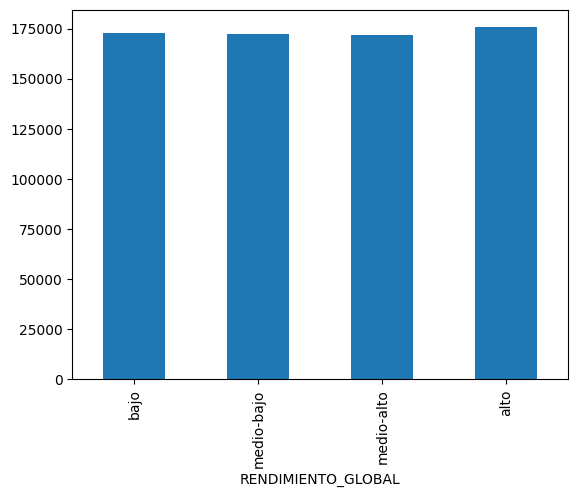

In [ ]:
diccRend ={0:"bajo", 1:"medio-bajo", 2:"medio-alto", 3:"alto"}
df_cleanprocess['RENDIMIENTO_GLOBAL'].value_counts().reindex(diccRend.values()).plot(kind="bar")

Variable categórica que representa el desempeño global del estudiante en la prueba. Hay una distribucipn de los estudiantes sobre esta variable objetivo unif

In [ ]:
df_cleanprocess["RENDIMIENTO_GLOBAL"].value_counts()

RENDIMIENTO_GLOBAL
alto          175619
bajo          172987
medio-bajo    172275
medio-alto    171619
Name: count, dtype: int64

In [ ]:
df_cleanprocess["RENDIMIENTO_GLOBAL"].isna().sum()

0

In [ ]:
df_cleanprocess['RENDIMIENTO_GLOBAL'].replace(diccRend.values(), diccRend.keys(), inplace=True)
df_cleanprocess[['RENDIMIENTO_GLOBAL']]

,RENDIMIENTO_GLOBAL
ID,
904256,2
645256,0
308367,0
470353,3
989032,1
...,...
25096,2
754213,0
504185,1


#### Función limpieza datos

Basandonos en el analisis y limpieza de datos por columna se encontraron 2 formas viables para hacer el tratamiento de los mismos. Primero usando one hot encoding únicamente para la columna de departamento y las demás columnas con números según su orden, así como el reemplazo de los valores faltantes por la moda de la columna.
Por otro lado, se tiene una variante con las columnas departamento y porgrama académico con one hot encoding, pero se tiene la dificultad de falta de poder computacional para probarlo (se probó en el computador, no google colab).

In [ ]:
def data_clean1(dataframe, dfOriginal,  train=False):

  '''
  Function to data cleaning whitout using one hot encoding and deleting only second column related with internet.
  It is only used one hot encoding in column "ESTU_PRGM_DEPARTAMENTO2", since column "ESTU_PRGM_ACADEMICO" has many possible values, and it almost impossible to processing.

  dataframe: Data wich be cleaning
  dfOriginal: Basic sdataframe which be used to cleaning all the dataframes
  train: Boolean depending of the presence of target dolumn in the dataframe

  '''

  Df = dataframe.copy()

  diccPeriods={}
  index=0
  for period in np.sort(Df['PERIODO'].unique()):
    diccPeriods[index]=period
    index = index+1
  Df['PERIODO'].replace(diccPeriods.values(), diccPeriods.keys(), inplace=True)

  values = dfOriginal['ESTU_PRGM_ACADEMICO'].unique()
  dicc= dict()
  for i in range(len(values)):
    dicc[i]=values[i]
  if not train:
    values2 = dataframe['ESTU_PRGM_ACADEMICO'].unique()
    for j in range(len(values2)):
      if (values2[j] not in values):
        dicc[len(values)+j]=values2[j]

  Df['ESTU_PRGM_ACADEMICO'] = Df['ESTU_PRGM_ACADEMICO'].replace(dicc.values(), dicc.keys())

  # valuesDept = dfOriginal['ESTU_PRGM_DEPARTAMENTO'].unique()
  # diccDept= dict()
  # for i in range(len(valuesDept)):
  #   diccDept[i]=valuesDept[i]

  # if not train:
  #   valuesDept2 = dataframe['ESTU_PRGM_DEPARTAMENTO'].unique()
  #   for j in range(len(valuesDept2)):
  #     if (valuesDept2[j] not in valuesDept):
  #       diccDept[len(values)+j]=valuesDept2[j]
  # Df['ESTU_PRGM_DEPARTAMENTO'] = Df['ESTU_PRGM_DEPARTAMENTO'].replace(diccDept.values(), diccDept.keys())

  dfOneHotEncoding2 = pd.get_dummies(Df[['ESTU_PRGM_DEPARTAMENTO']], dtype=int)
  Df=pd.concat([Df,dfOneHotEncoding2], axis=1)
  Df.drop(columns=['ESTU_PRGM_DEPARTAMENTO'], inplace=True)

  x_valMatr=["No pagó matrícula", "Menos de 500 mil", "Entre 500 mil y menos de 1 millón", "Entre 1 millón y menos de 2.5 millones", "Entre 2.5 millones y menos de 4 millones",
   "Entre 4 millones y menos de 5.5 millones", "Entre 5.5 millones y menos de 7 millones", "Más de 7 millones"]
  Df["ESTU_VALORMATRICULAUNIVERSIDAD"].fillna(Df["ESTU_VALORMATRICULAUNIVERSIDAD"].mode()[0], inplace=True)
  diccMatr= dict()
  for i in range(len(x_valMatr)):
    diccMatr[i]=x_valMatr[i]
  Df['ESTU_VALORMATRICULAUNIVERSIDAD'].replace(diccMatr.values(), diccMatr.keys(), inplace=True)

  x_hrTrab=["0", "Menos de 10 horas", "Entre 11 y 20 horas", "Entre 21 y 30 horas", "Más de 30 horas"]
  Df["ESTU_HORASSEMANATRABAJA"].fillna(Df["ESTU_HORASSEMANATRABAJA"].mode()[0], inplace=True)
  dicchrTrab= dict()
  for i in range(len(x_hrTrab)):
    dicchrTrab[i]=x_hrTrab[i]
  Df['ESTU_HORASSEMANATRABAJA'].replace(dicchrTrab.values(), dicchrTrab.keys(), inplace=True)

  frequencies = Df['FAMI_ESTRATOVIVIENDA'].value_counts(normalize=True)
  na_indices = Df['FAMI_ESTRATOVIVIENDA'][Df['FAMI_ESTRATOVIVIENDA'].isna()].index
  filled_values = np.random.choice(frequencies.index, size=len(na_indices), p=frequencies.values)
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values
  x_estrat=["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"]
  diccStrat= dict()
  for i in range(len(x_estrat)):
    diccStrat[i]=x_estrat[i]
  Df['FAMI_ESTRATOVIVIENDA'].replace(diccStrat.values(), diccStrat.keys(), inplace=True)

  Df["FAMI_TIENEINTERNET"].fillna(Df["FAMI_TIENEINTERNET"].mode()[0], inplace=True)
  diccBinary={0:"No", 1:"Si"}
  Df['FAMI_TIENEINTERNET'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  x_educ=["No sabe", "No Aplica", "Ninguno", "Primaria incompleta", "Primaria completa", "Secundaria (Bachillerato) incompleta", "Secundaria (Bachillerato) completa",
   "Técnica o tecnológica incompleta", "Técnica o tecnológica completa", "Educación profesional incompleta", "Educación profesional completa", "Postgrado"]
  Df["FAMI_EDUCACIONPADRE"].fillna(Df["FAMI_EDUCACIONPADRE"].mode()[0], inplace=True)
  diccEduc= dict()
  for i in range(len(x_educ)):
    diccEduc[i]=x_educ[i]
  Df['FAMI_EDUCACIONPADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)

  Df["FAMI_TIENELAVADORA"].fillna(Df["FAMI_TIENELAVADORA"].mode()[0], inplace=True)
  Df['FAMI_TIENELAVADORA'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["FAMI_TIENEAUTOMOVIL"].fillna(Df["FAMI_TIENEAUTOMOVIL"].mode()[0], inplace=True)
  Df['FAMI_TIENEAUTOMOVIL'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["ESTU_PAGOMATRICULAPROPIO"].fillna(Df["ESTU_PAGOMATRICULAPROPIO"].mode()[0], inplace=True)
  Df['ESTU_PAGOMATRICULAPROPIO'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["FAMI_TIENECOMPUTADOR"].fillna(Df["FAMI_TIENECOMPUTADOR"].mode()[0], inplace=True)
  Df['FAMI_TIENECOMPUTADOR'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df.drop(columns=["FAMI_TIENEINTERNET.1"], inplace = True)

  Df["FAMI_EDUCACIONMADRE"].fillna(Df["FAMI_EDUCACIONMADRE"].mode()[0], inplace=True)
  Df['FAMI_EDUCACIONMADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)

  diccBinary2 ={0:"N", 1:"S"}
  Df["ESTU_PRIVADO_LIBERTAD"].fillna(Df["ESTU_PRIVADO_LIBERTAD"].mode()[0], inplace=True)
  Df['ESTU_PRIVADO_LIBERTAD'].replace(diccBinary2.values(), diccBinary2.keys(), inplace=True)

  Df["FAMI_TIENECOMPUTADOR"].fillna(Df["FAMI_TIENECOMPUTADOR"].mode()[0], inplace=True)
  Df['FAMI_TIENECOMPUTADOR'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  if train:
    diccRend ={0:"bajo", 1:"medio-bajo", 2:"medio-alto", 3:"alto"}
    Df['RENDIMIENTO_GLOBAL'].replace(diccRend.values(), diccRend.keys(), inplace=True)
  return Df

In [ ]:
def data_clean2(dataframe, dfOriginal, train = False):

  '''
  Function to data cleaning using one hot encoding and deleting only second column related with internet.

  dataframe: Data wich be cleaning
  dfOriginal: Basic sdataframe which be used to cleaning all the dataframes
  train: Boolean depending of the presence of target dolumn in the dataframe

  '''

  Df = dataframe.copy()

  diccPeriods={}
  index=0
  for period in np.sort(Df['PERIODO'].unique()):
    diccPeriods[index]=period
    index = index+1
  Df['PERIODO'].replace(diccPeriods.values(), diccPeriods.keys(), inplace=True)

  dfOneHotEncoding = pd.get_dummies(Df[['ESTU_PRGM_ACADEMICO']], dtype=int)
  Df=pd.concat([Df,dfOneHotEncoding], axis=1)
  Df.drop(columns=['ESTU_PRGM_ACADEMICO'], inplace=True)

  if not train:
    dfOneHotEncodingOriginal = pd.get_dummies(dfOriginal[['ESTU_PRGM_ACADEMICO']], dtype=int)
    for col in dfOneHotEncodingOriginal.columns:
      if col not in dfOneHotEncoding.columns:
          Df[col] = 0.0
    # for col in dfOneHotEncodingOriginal.columns:
    #   if col not in dfOneHotEncoding.columns:
    #       Df[col] = 0.0
    # for col in dfOneHotEncoding.columns:
    #   if col not in dfOneHotEncodingOriginal.columns:
    #       Df.drop(columns=[col], inplace=True)

  else:
    dfSub = pd.read_csv("test.csv")
    dfOneHotEncodingNew = pd.get_dummies(dfSub[['ESTU_PRGM_ACADEMICO']], dtype=int)
    for col in dfOneHotEncodingNew.columns:
      if col not in dfOneHotEncoding.columns:
          Df[col] = 0.0

  dfOneHotEncoding2 = pd.get_dummies(Df[['ESTU_PRGM_DEPARTAMENTO']], dtype=int)
  Df=pd.concat([Df,dfOneHotEncoding2], axis=1)
  Df.drop(columns=['ESTU_PRGM_DEPARTAMENTO'], inplace=True)

  x_valMatr=["No pagó matrícula", "Menos de 500 mil", "Entre 500 mil y menos de 1 millón", "Entre 1 millón y menos de 2.5 millones", "Entre 2.5 millones y menos de 4 millones",
   "Entre 4 millones y menos de 5.5 millones", "Entre 5.5 millones y menos de 7 millones", "Más de 7 millones"]
  Df["ESTU_VALORMATRICULAUNIVERSIDAD"].fillna(Df["ESTU_VALORMATRICULAUNIVERSIDAD"].mode()[0], inplace=True)
  diccMatr= dict()
  for i in range(len(x_valMatr)):
    diccMatr[i]=x_valMatr[i]
  Df['ESTU_VALORMATRICULAUNIVERSIDAD'].replace(diccMatr.values(), diccMatr.keys(), inplace=True)

  x_hrTrab=["0", "Menos de 10 horas", "Entre 11 y 20 horas", "Entre 21 y 30 horas", "Más de 30 horas"]
  Df["ESTU_HORASSEMANATRABAJA"].fillna(Df["ESTU_HORASSEMANATRABAJA"].mode()[0], inplace=True)
  dicchrTrab= dict()
  for i in range(len(x_hrTrab)):
    dicchrTrab[i]=x_hrTrab[i]
  Df['ESTU_HORASSEMANATRABAJA'].replace(dicchrTrab.values(), dicchrTrab.keys(), inplace=True)

  frequencies = Df['FAMI_ESTRATOVIVIENDA'].value_counts(normalize=True)
  na_indices = Df['FAMI_ESTRATOVIVIENDA'][Df['FAMI_ESTRATOVIVIENDA'].isna()].index
  filled_values = np.random.choice(frequencies.index, size=len(na_indices), p=frequencies.values)
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values
  x_estrat=["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"]
  diccStrat= dict()
  for i in range(len(x_estrat)):
    diccStrat[i]=x_estrat[i]
  Df['FAMI_ESTRATOVIVIENDA'].replace(diccStrat.values(), diccStrat.keys(), inplace=True)

  Df["FAMI_TIENEINTERNET"].fillna(Df["FAMI_TIENEINTERNET"].mode()[0], inplace=True)
  diccBinary={0:"No", 1:"Si"}
  Df['FAMI_TIENEINTERNET'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  x_educ=["No sabe", "No Aplica", "Ninguno", "Primaria incompleta", "Primaria completa", "Secundaria (Bachillerato) incompleta", "Secundaria (Bachillerato) completa",
   "Técnica o tecnológica incompleta", "Técnica o tecnológica completa", "Educación profesional incompleta", "Educación profesional completa", "Postgrado"]
  Df["FAMI_EDUCACIONPADRE"].fillna(Df["FAMI_EDUCACIONPADRE"].mode()[0], inplace=True)
  diccEduc= dict()
  for i in range(len(x_educ)):
    diccEduc[i]=x_educ[i]
  Df['FAMI_EDUCACIONPADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)

  Df["FAMI_TIENELAVADORA"].fillna(Df["FAMI_TIENELAVADORA"].mode()[0], inplace=True)
  Df['FAMI_TIENELAVADORA'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["FAMI_TIENEAUTOMOVIL"].fillna(Df["FAMI_TIENEAUTOMOVIL"].mode()[0], inplace=True)
  Df['FAMI_TIENEAUTOMOVIL'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["ESTU_PAGOMATRICULAPROPIO"].fillna(Df["ESTU_PAGOMATRICULAPROPIO"].mode()[0], inplace=True)
  Df['ESTU_PAGOMATRICULAPROPIO'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df["FAMI_TIENECOMPUTADOR"].fillna(Df["FAMI_TIENECOMPUTADOR"].mode()[0], inplace=True)
  Df['FAMI_TIENECOMPUTADOR'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  Df.drop(columns=["FAMI_TIENEINTERNET.1"], inplace = True)

  Df["FAMI_EDUCACIONMADRE"].fillna(Df["FAMI_EDUCACIONMADRE"].mode()[0], inplace=True)
  Df['FAMI_EDUCACIONMADRE'].replace(diccEduc.values(), diccEduc.keys(), inplace=True)

  diccBinary2 ={0:"N", 1:"S"}
  Df["ESTU_PRIVADO_LIBERTAD"].fillna(Df["ESTU_PRIVADO_LIBERTAD"].mode()[0], inplace=True)
  Df['ESTU_PRIVADO_LIBERTAD'].replace(diccBinary2.values(), diccBinary2.keys(), inplace=True)

  Df["FAMI_TIENECOMPUTADOR"].fillna(Df["FAMI_TIENECOMPUTADOR"].mode()[0], inplace=True)
  Df['FAMI_TIENECOMPUTADOR'].replace(diccBinary.values(), diccBinary.keys(), inplace=True)

  if train:
    diccRend ={0:"bajo", 1:"medio-bajo", 2:"medio-alto", 3:"alto"}
    Df['RENDIMIENTO_GLOBAL'].replace(diccRend.values(), diccRend.keys(), inplace=True)

  return Df


In [ ]:
df_clean1 = data_clean1(df, df, train=True)
df_clean1.head()

<ipython-input-27-b6a7e09a5263>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values


,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,7,0,6,1,3,1,7,1,1,0,...,0,0,0,0,0,0,0,0,0,0
645256,7,1,4,0,3,0,8,1,0,0,...,0,0,0,0,0,0,0,0,0,0
308367,6,2,4,4,3,1,6,1,0,0,...,0,0,0,0,0,0,0,0,0,0
470353,3,3,5,0,4,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
989032,7,4,4,3,3,1,4,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_clean2 = data_clean2(df, df, train=True)
df_clean2.head()

C:\Users\Sebastian Sarmiento\AppData\Local\Temp\ipykernel_13000\3829403571.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Df['PERIODO'].replace(diccPeriods.values(), diccPeriods.keys(), inplace=True)
C:\Users\Sebastian Sarmiento\AppData\Local\Temp\ipykernel_13000\3829403571.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whi

,PERIODO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,ESTU_PAGOMATRICULAPROPIO,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,7,6,1,3,1,7,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
645256,7,4,0,3,0,8,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308367,6,4,4,3,1,6,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
470353,3,5,0,4,1,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
989032,7,4,3,3,1,4,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Exploración de datos

In [ ]:
df_cleanprocess.head()

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_PRGM_DEPARTAMENTO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,ESTU_PAGOMATRICULAPROPIO,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET.1,FAMI_EDUCACIONMADRE,RENDIMIENTO_GLOBAL
ID,,,,,,,,,,,,,,,,
904256,0.966667,0,0,6,1,3,1,7,1,1,0,0,1,1,11,2
645256,0.966667,1,1,4,0,3,0,8,1,0,0,0,1,0,7,0
308367,0.666667,2,0,4,4,3,1,6,1,0,0,0,0,1,6,0
470353,0.400000,3,2,5,0,4,1,0,1,0,0,0,1,1,6,3
989032,0.966667,4,3,4,3,3,1,4,1,1,0,0,1,1,4,1


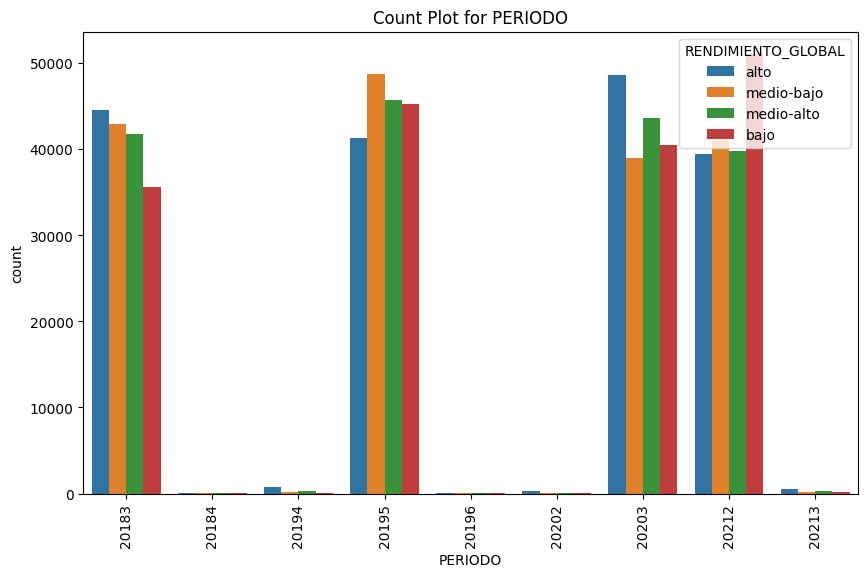

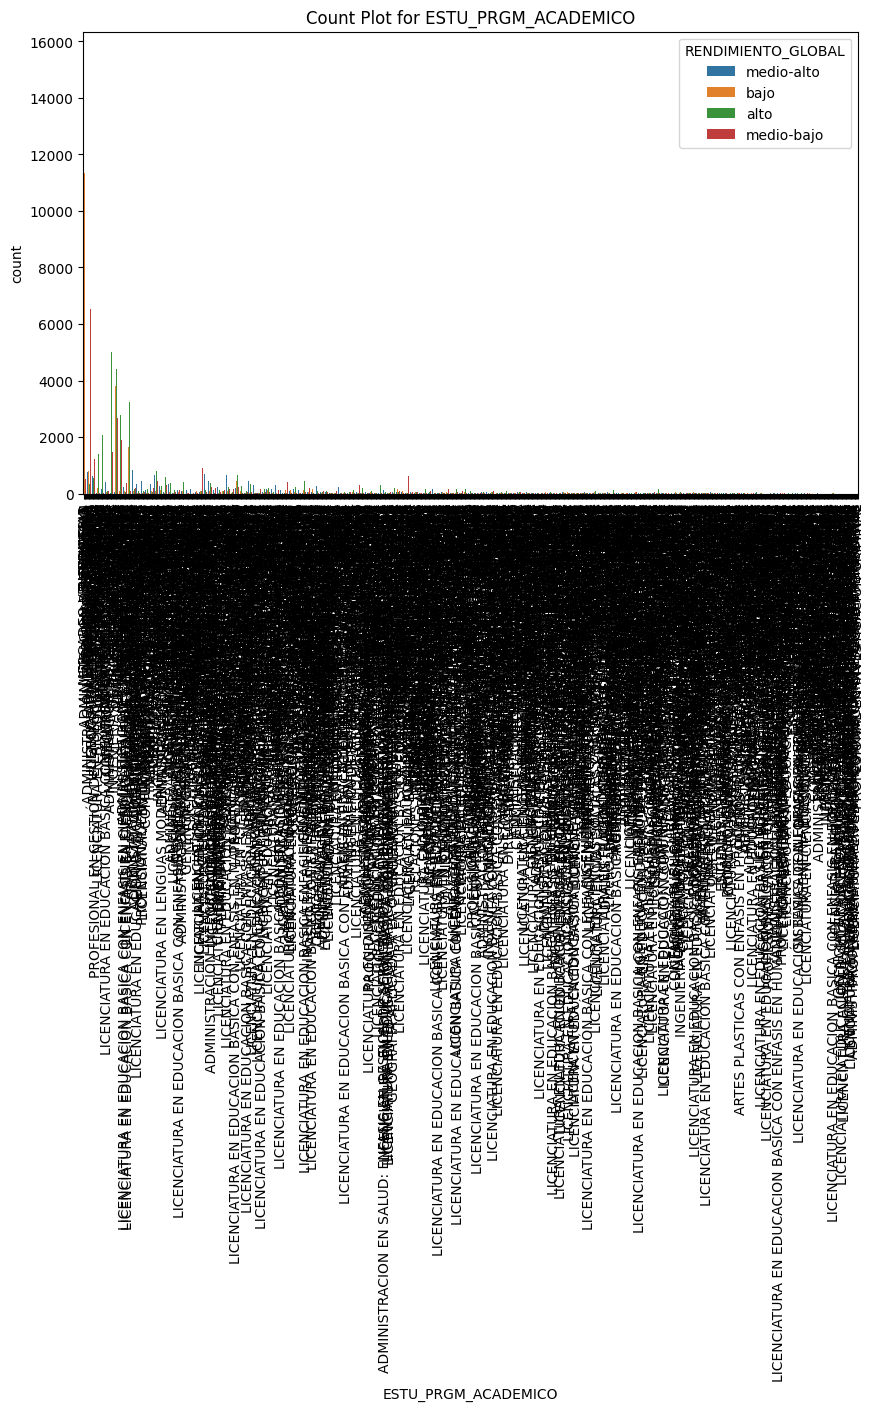

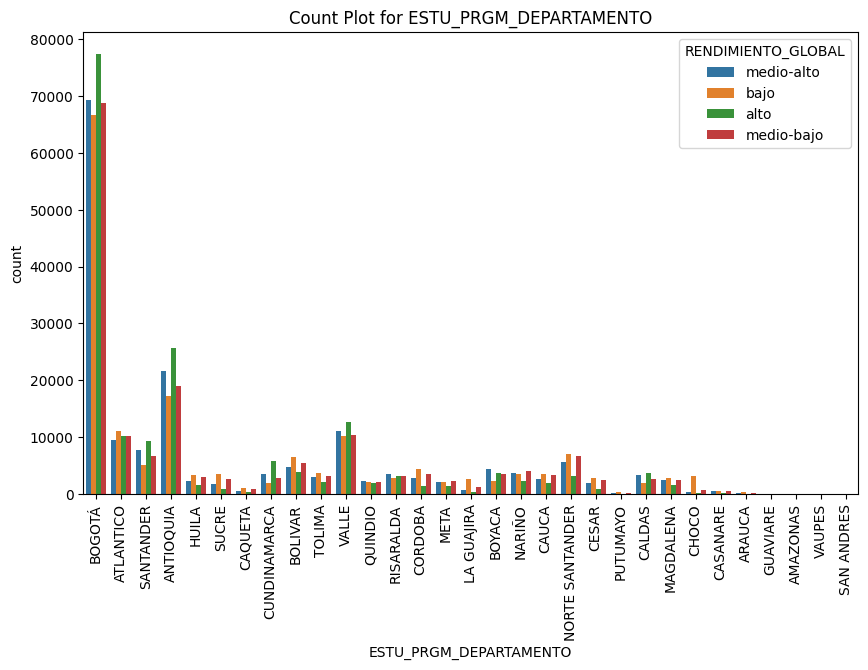

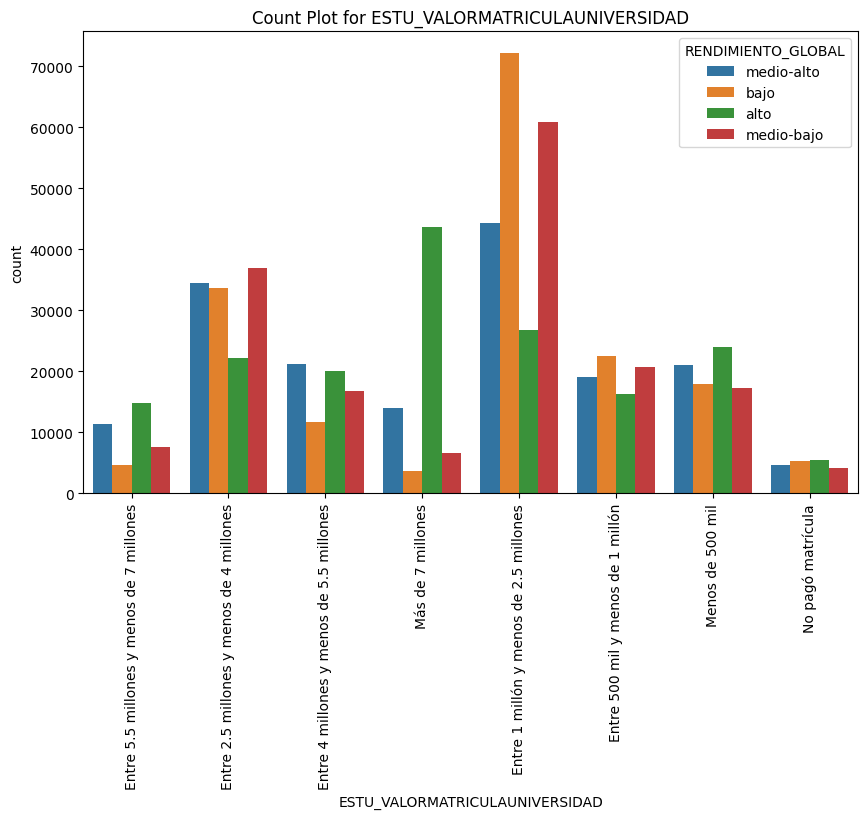

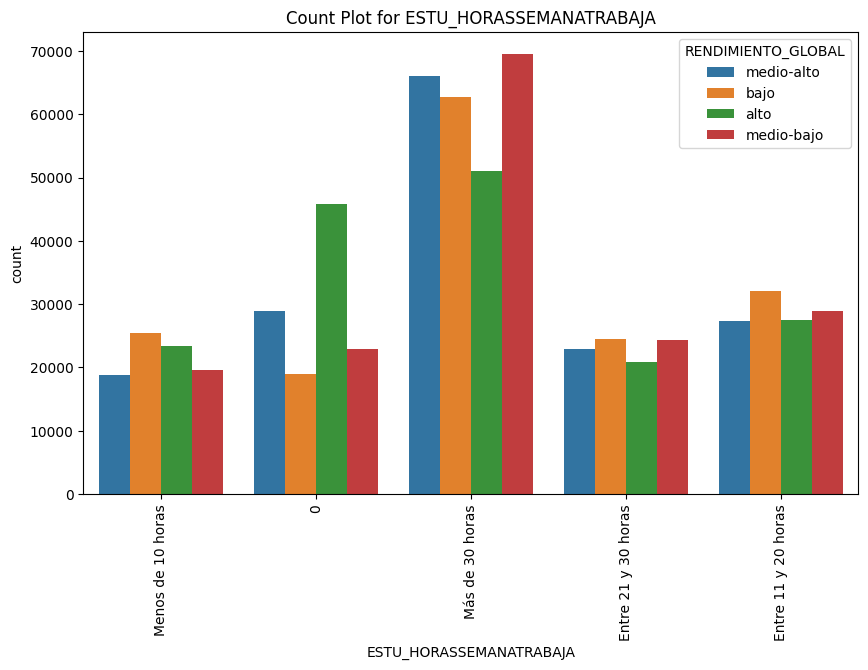

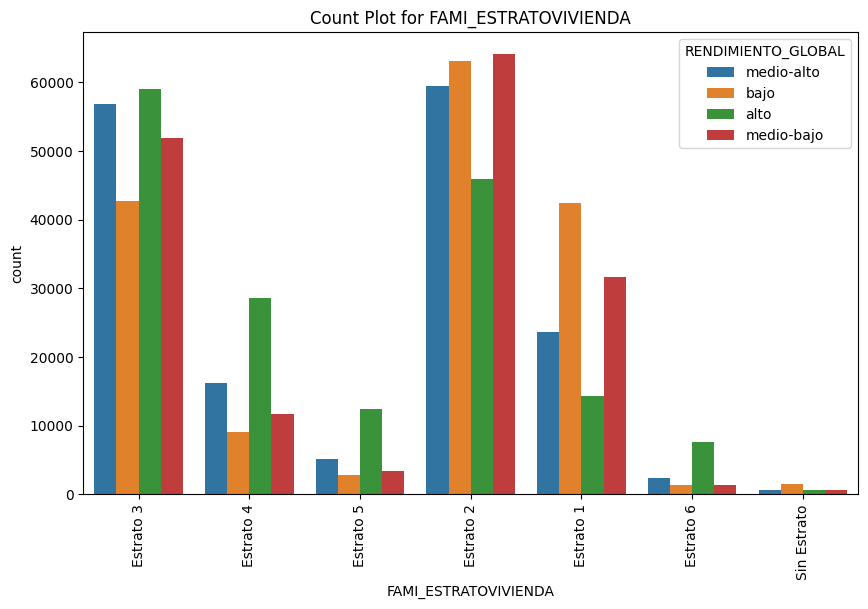

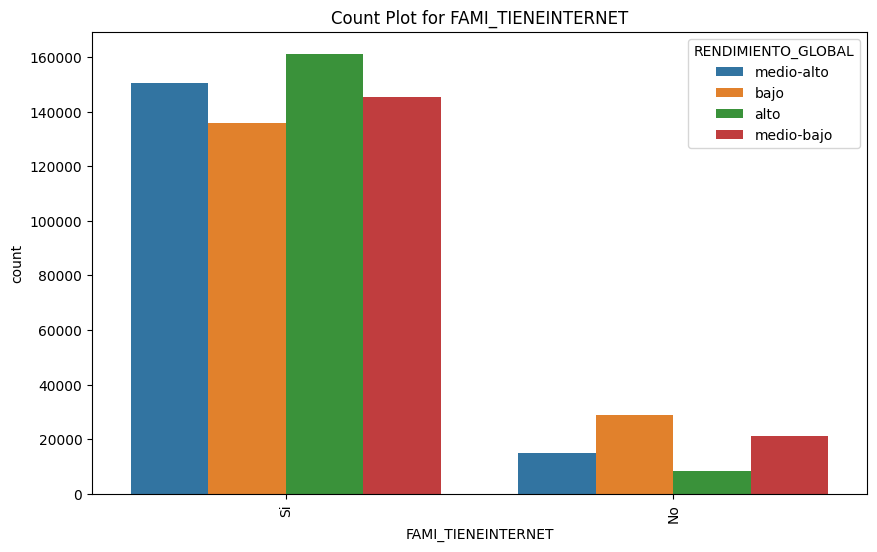

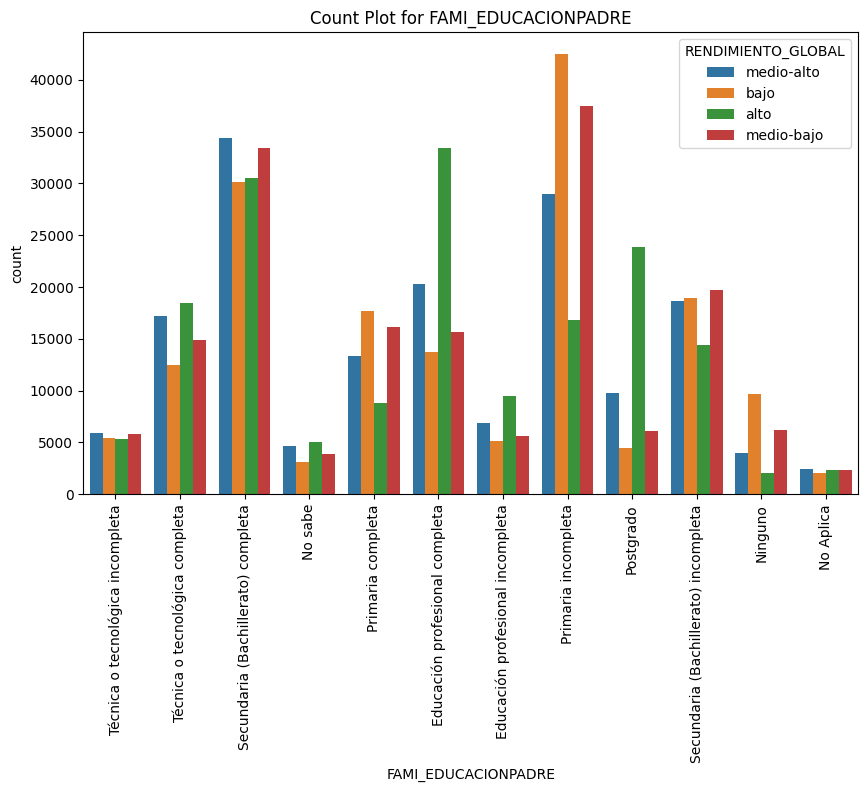

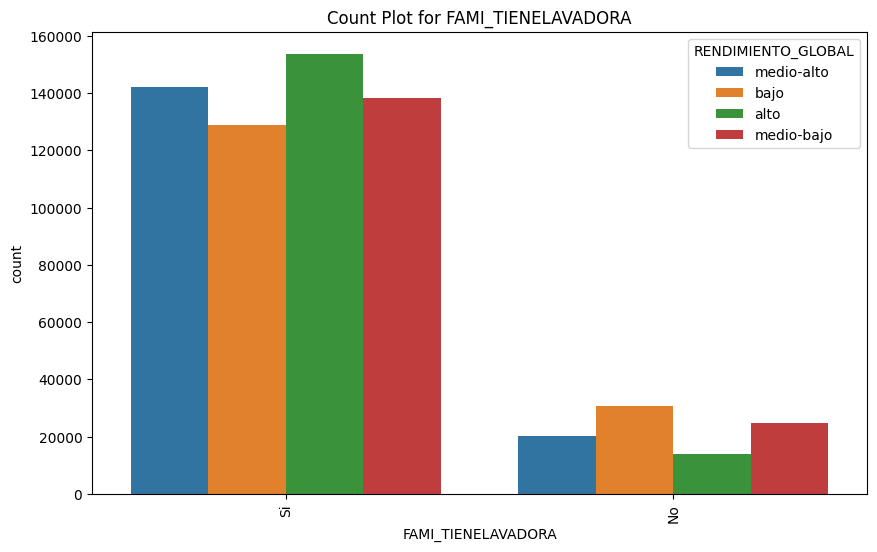

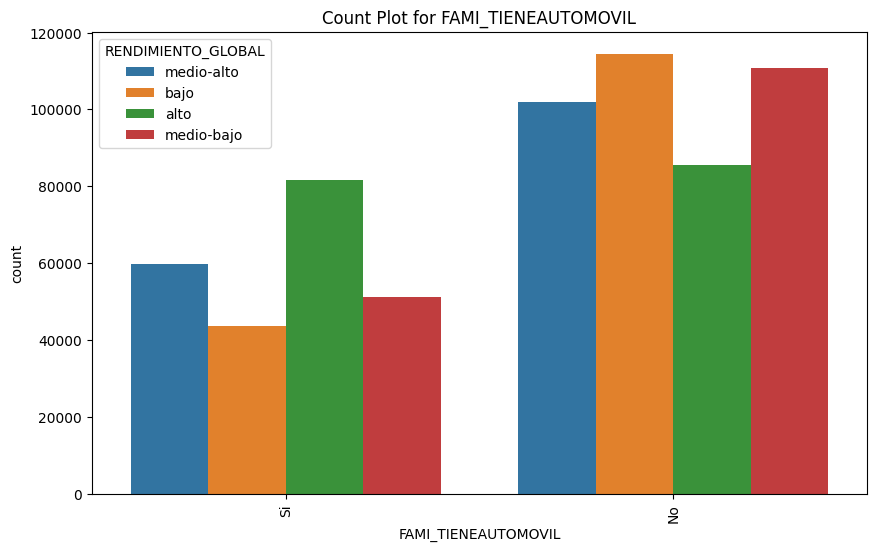

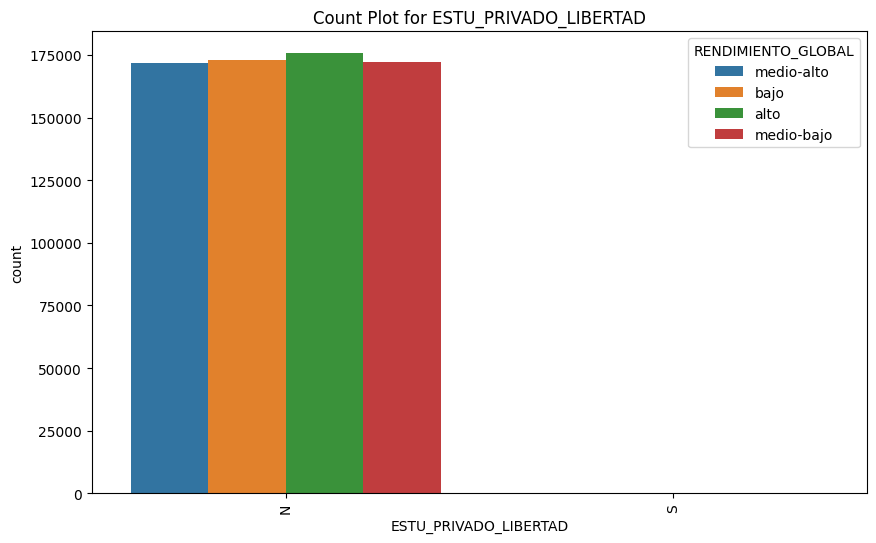

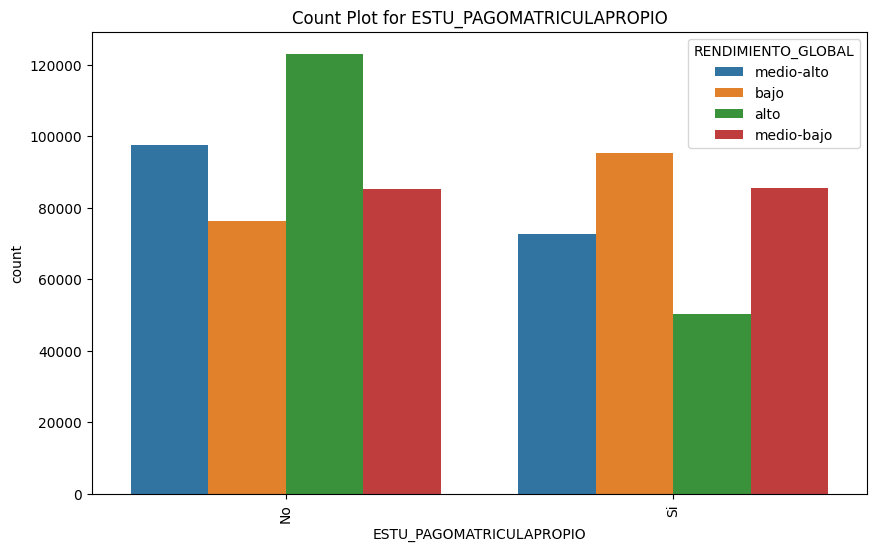

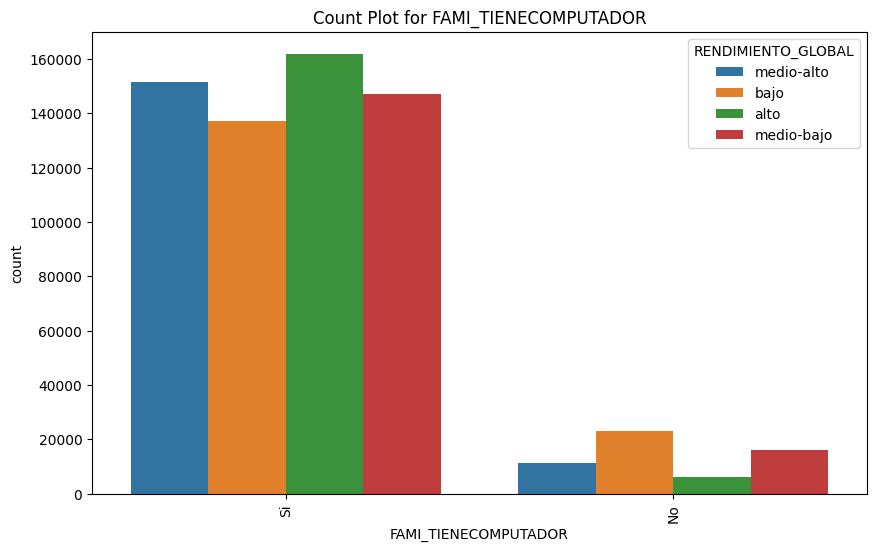

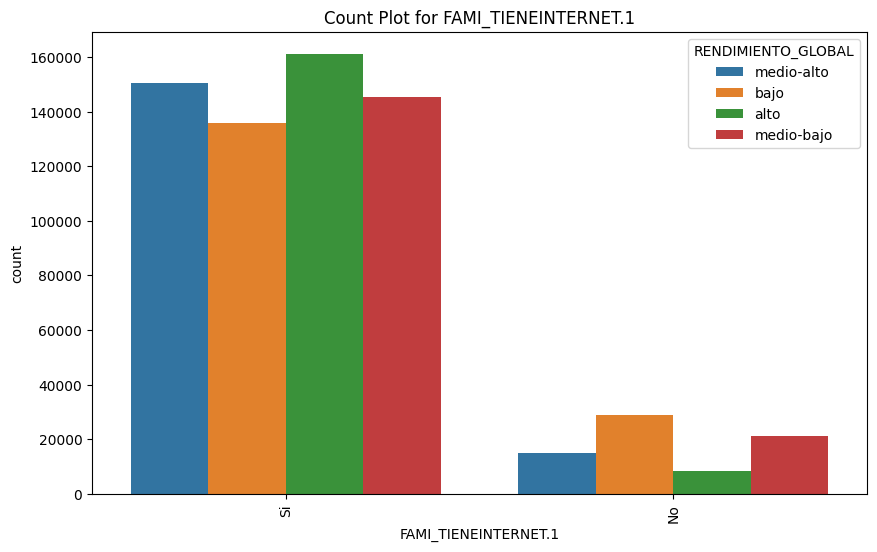

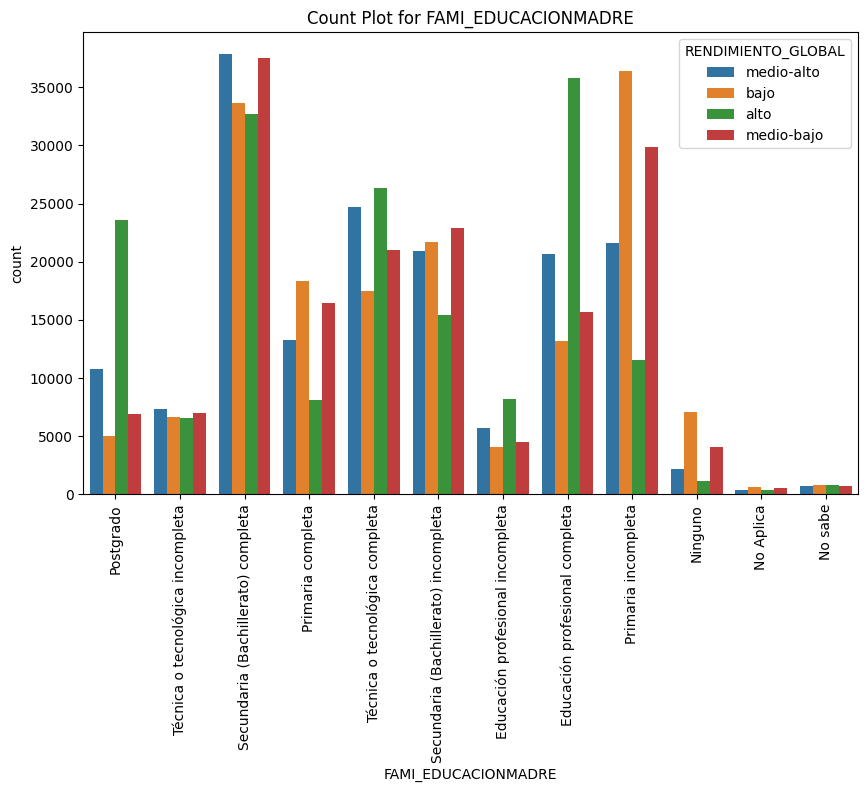

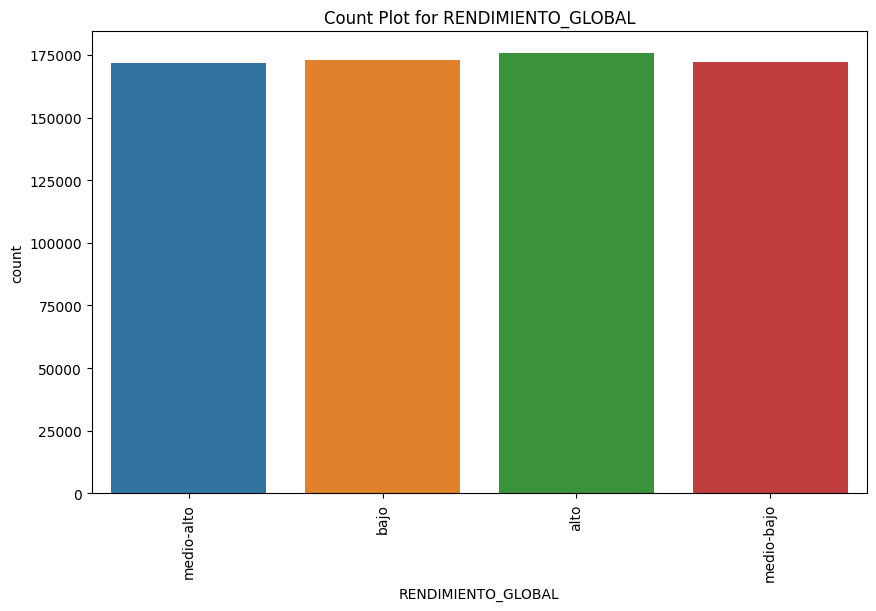

In [ ]:
for col in df_cleanprocess.columns:
    plt.figure(figsize=(10, 6))  # Create a new figure with a specified size
    sns.countplot(data=df_cleanprocess, x=col, hue='RENDIMIENTO_GLOBAL')  # Plot the count plot
    plt.title(f'Count Plot for {col}')  # Add a title for each plot
    plt.xticks(rotation=90)  # Rotate x-axis labels if needed
    plt.show()

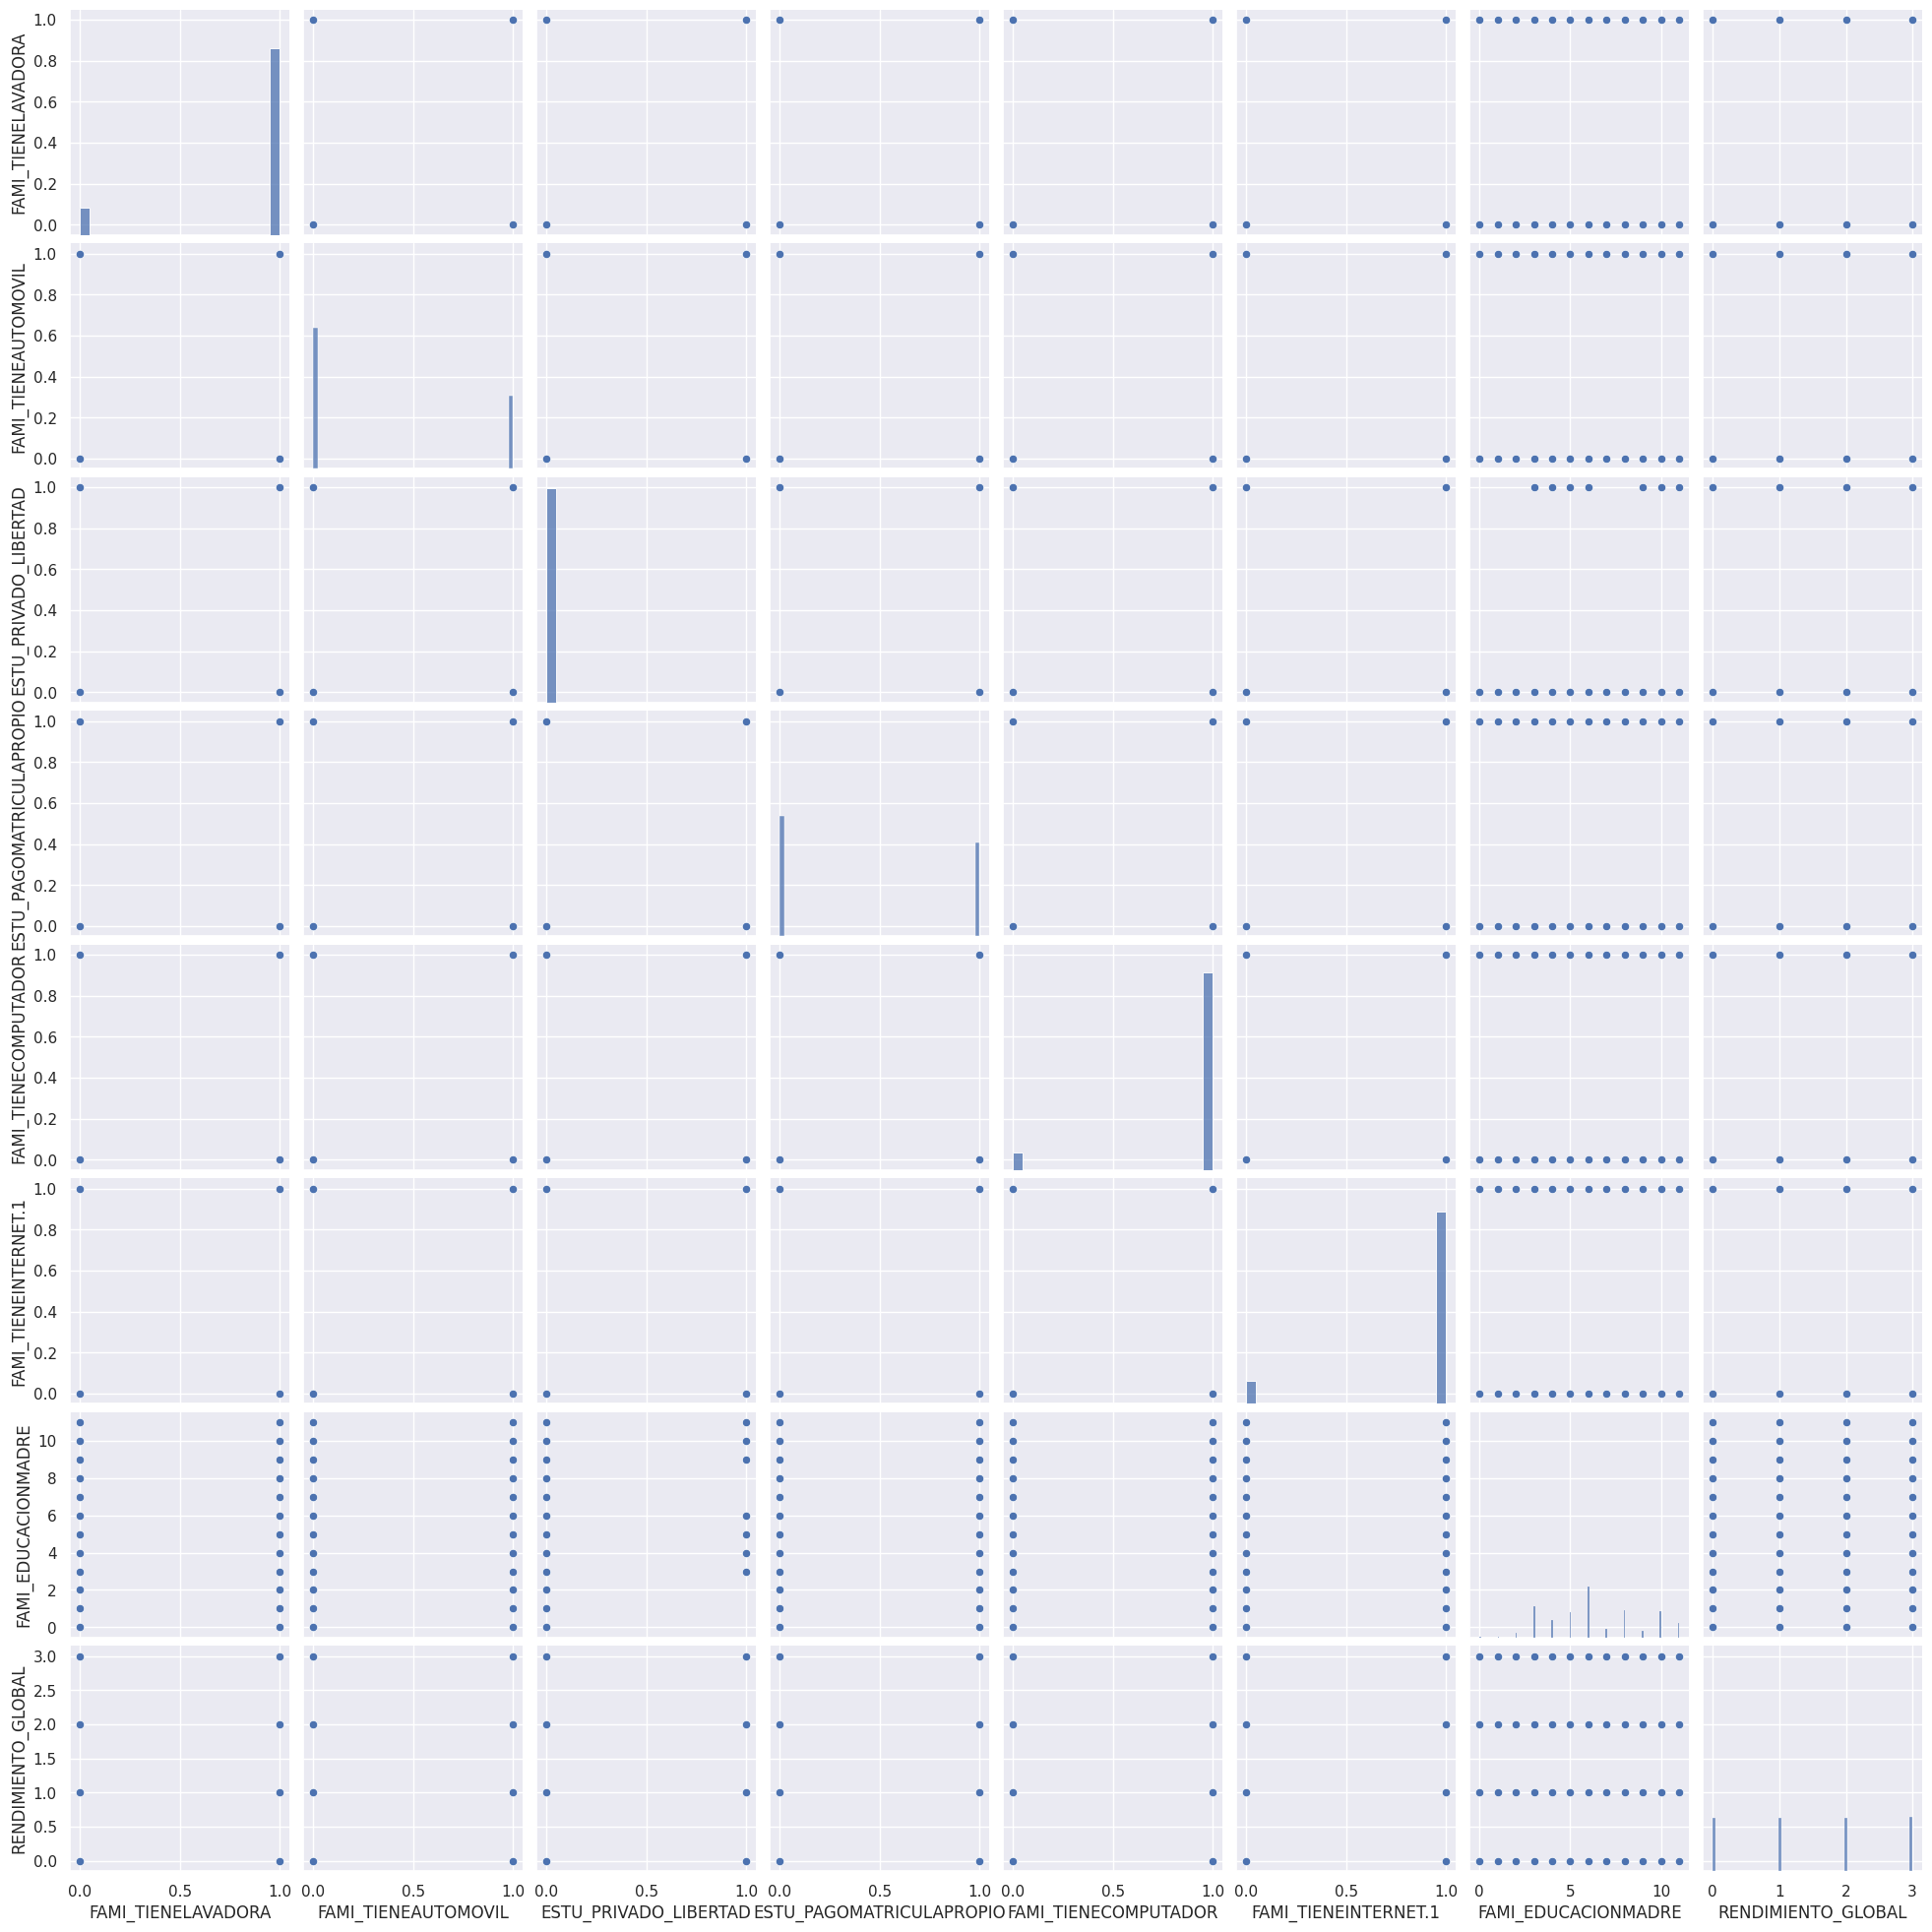

In [ ]:
cols = df_cleanprocess.columns[int(len(df_cleanprocess.columns)/2):]
#cols = np.unique(list(np.random.permutation(d._get_numeric_data().columns)[:5])+['SalePrice'])
sns.set()
sns.pairplot(df_cleanprocess[cols])

['PERIODO' 'ESTU_PRGM_ACADEMICO' 'ESTU_PRGM_DEPARTAMENTO'
 'ESTU_VALORMATRICULAUNIVERSIDAD' 'ESTU_HORASSEMANATRABAJA'
 'FAMI_ESTRATOVIVIENDA' 'FAMI_TIENEINTERNET' 'FAMI_EDUCACIONPADRE'
 'RENDIMIENTO_GLOBAL']


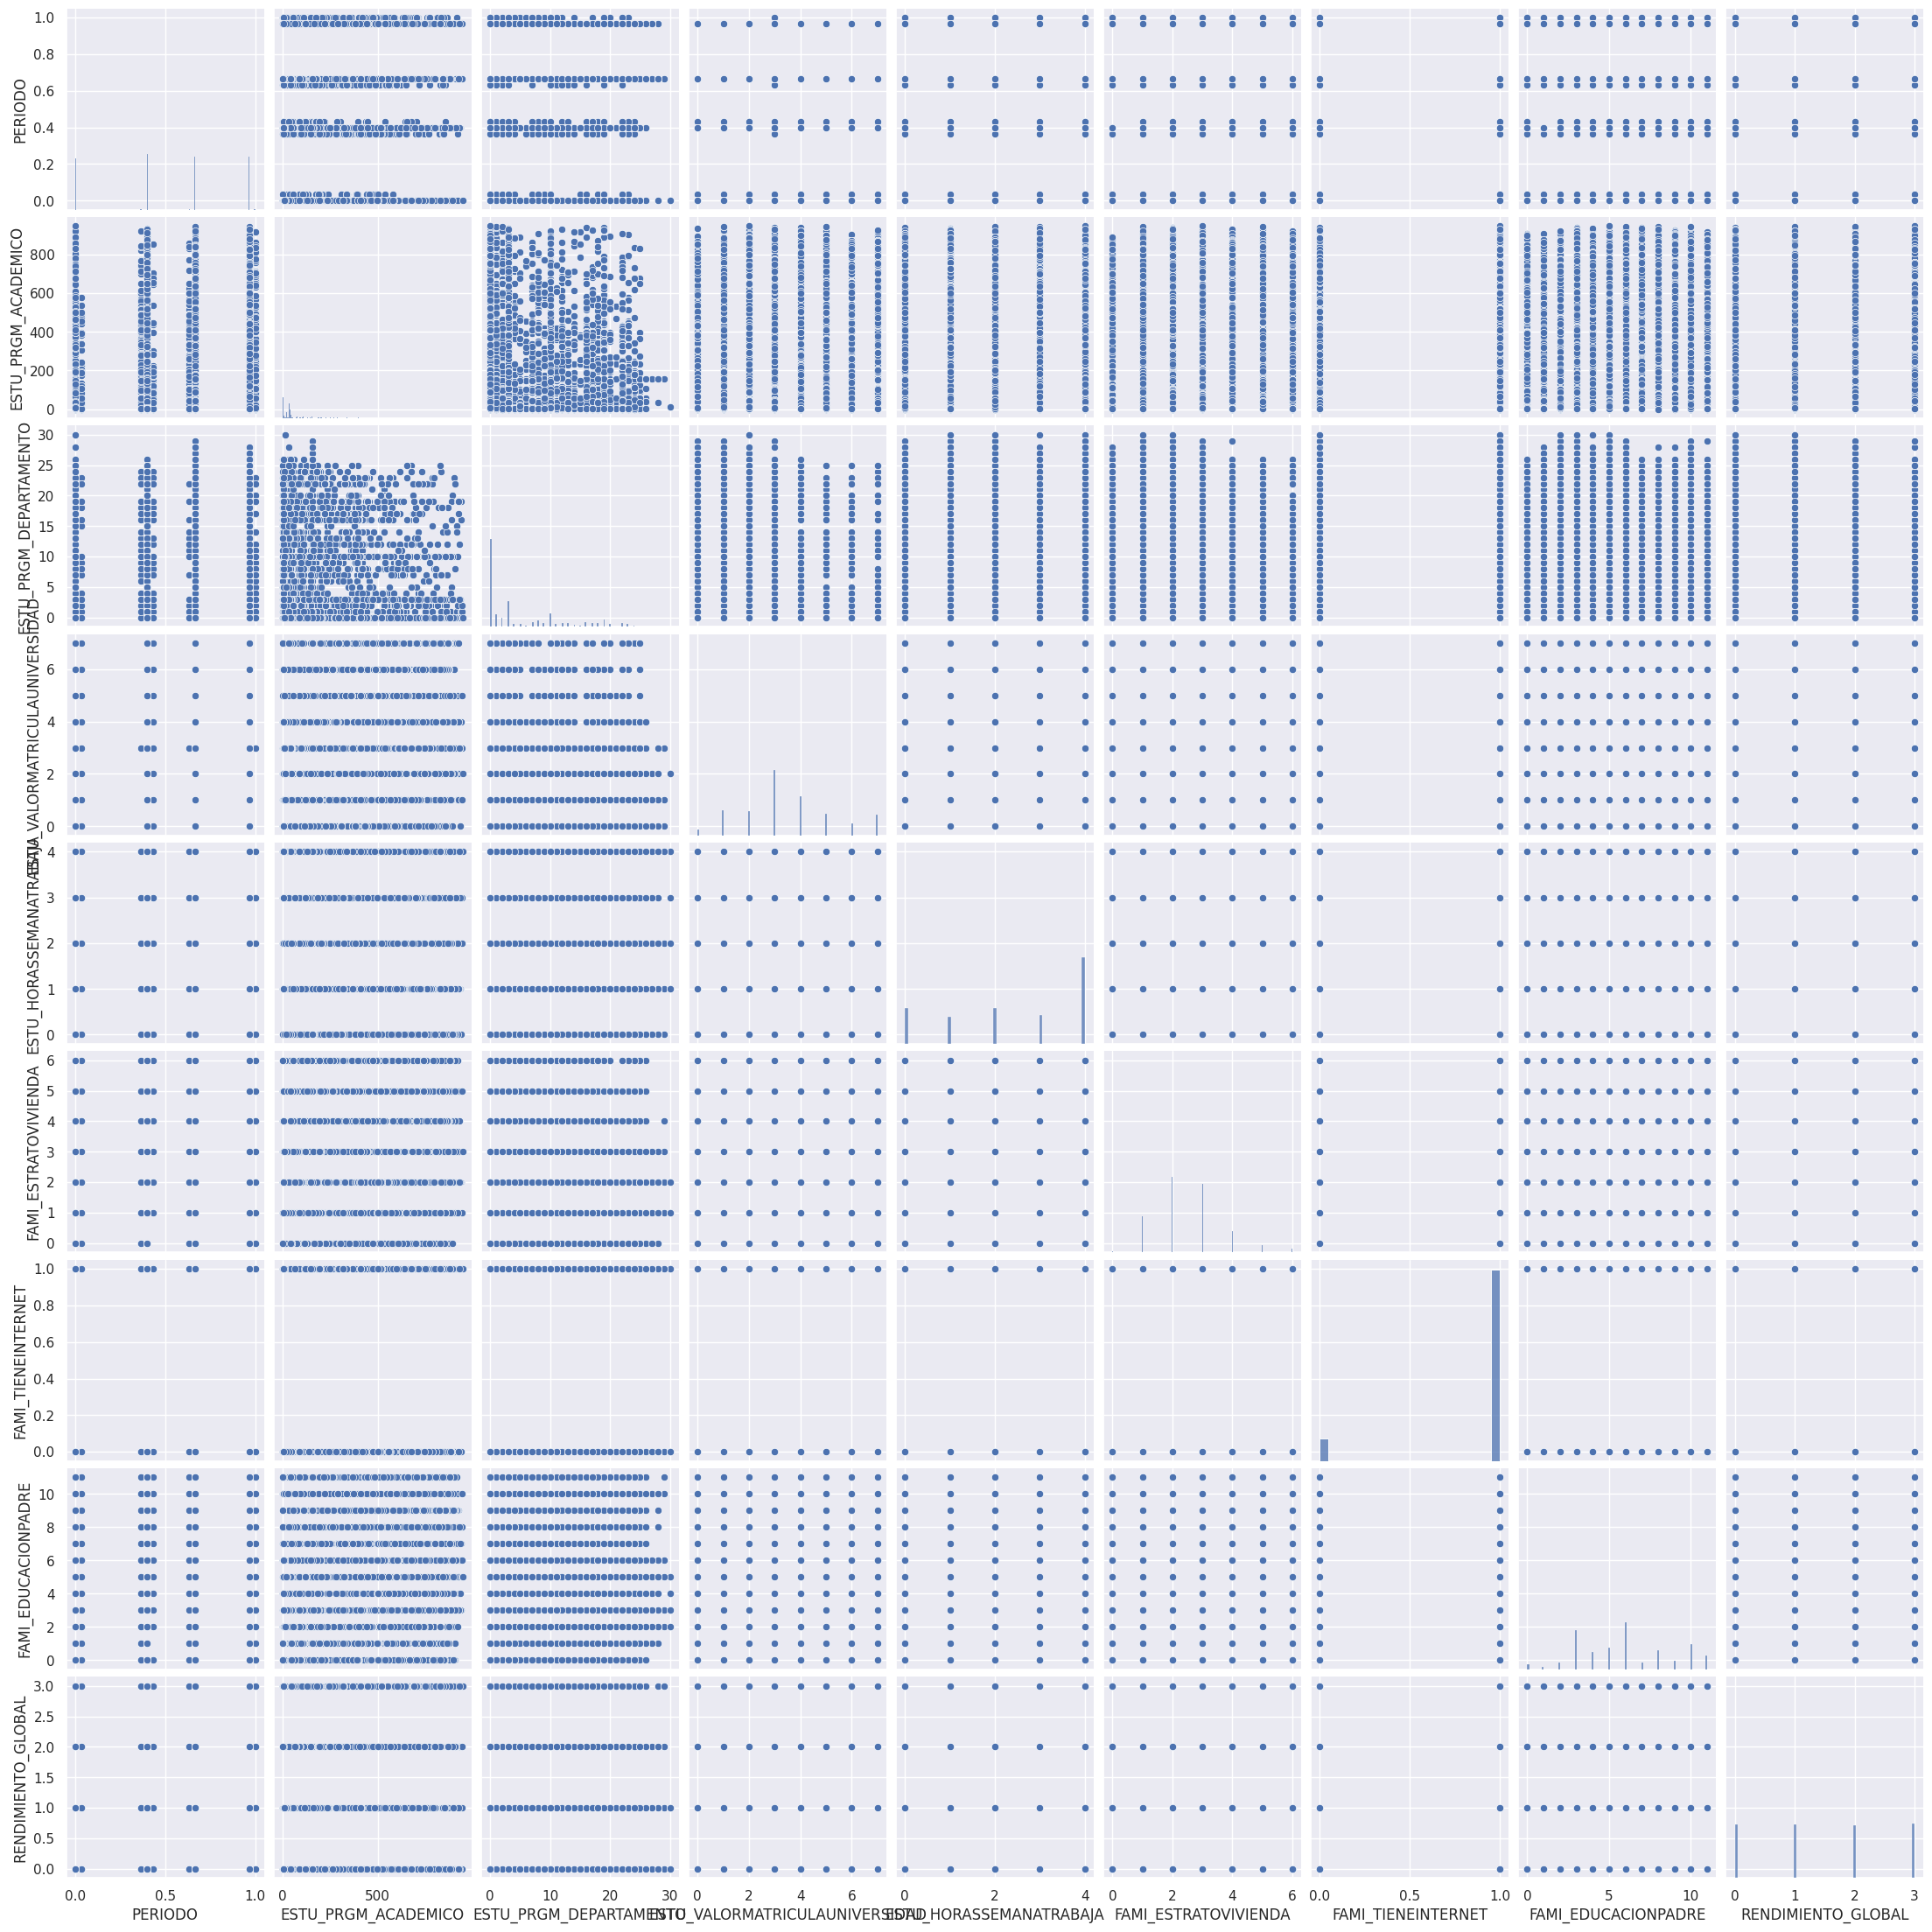

In [ ]:
cols = np.concatenate((df_cleanprocess.columns[:int(len(df_cleanprocess.columns)/2)],np.array(["RENDIMIENTO_GLOBAL"])))
print(cols)
#cols = np.unique(list(np.random.permutation(d._get_numeric_data().columns)[:5])+['SalePrice'])
sns.set()
sns.pairplot(df_cleanprocess[cols])

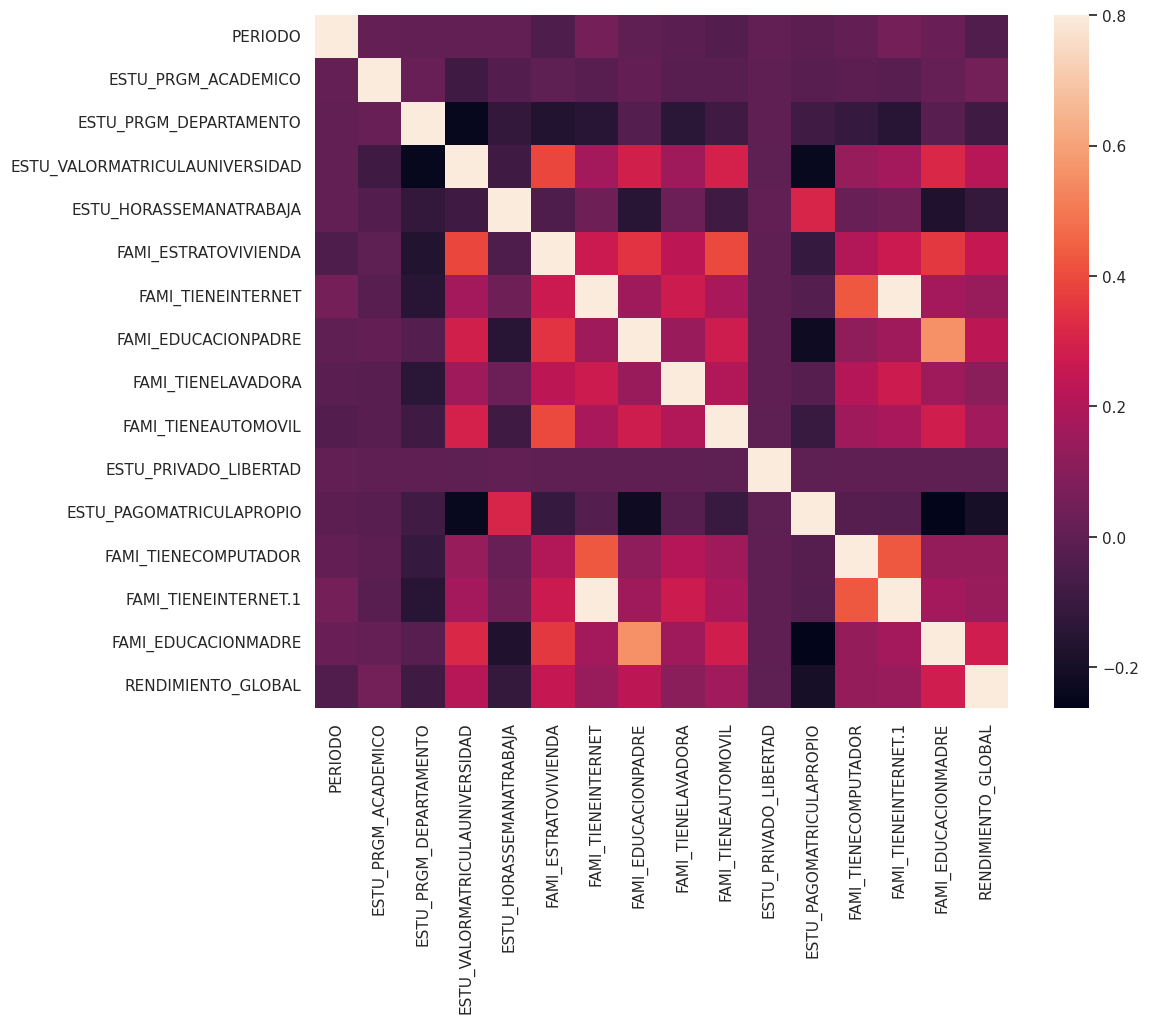

In [ ]:
corrmat = df_cleanprocess.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

**Matriz de correlación con todas las columnas**

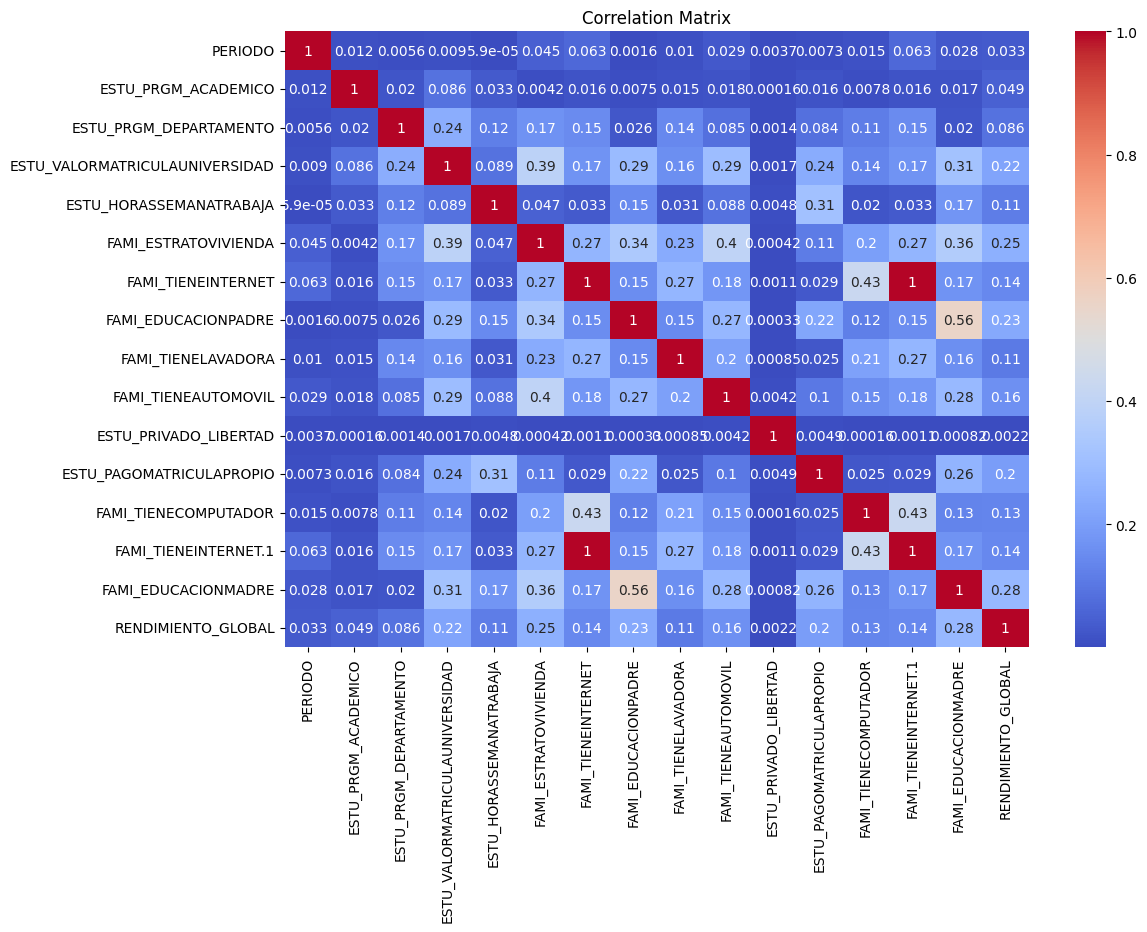

Highly correlated columns: []


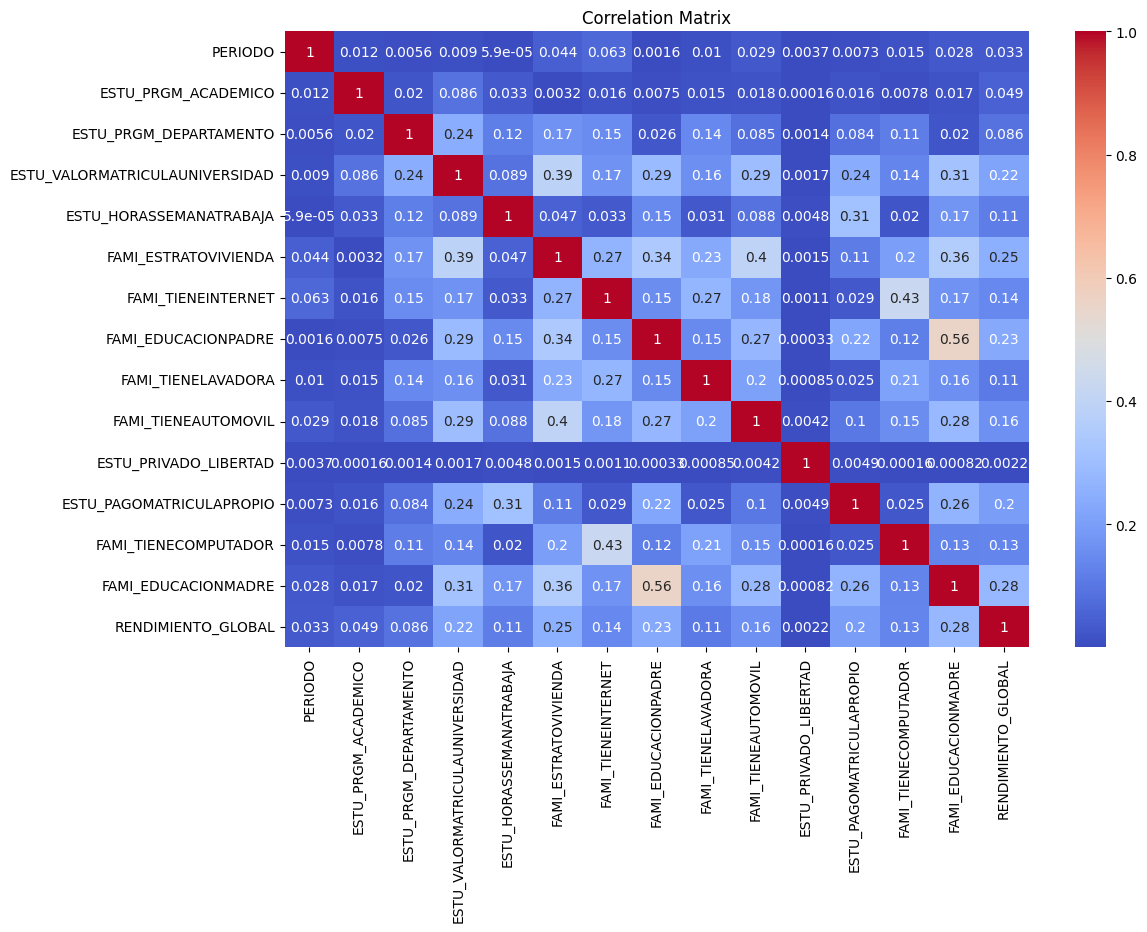

In [ ]:
corr_matrix = df_clean1[:12].corr().abs()

# Identify columns with correlation higher than a threshold (e.g., 0.9)
high_corr_var = np.where(corr_matrix > 0.9)
high_corr_var = [(corr_matrix.index[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

print("Highly correlated columns:", high_corr_var)

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Con los gráficos respecto a las otras columnas y a la variable objetivo, no se obervan relaciónes evidentes, más sin embargo, la matriz de correlación generada nos ayuda a tener idea de columnas que pueden no tener mucha influencia en la clasificación como la columna de internet repetida así como el estado de libertad que fueron eliminadas en pruebas realizadas para llegar a las mejores predicciones.

### Modelo

Se hace una división de datos en dataset de entrenamiento, validación (Desempeño en cambio de hiperparametros) y test (desempeño final), con una distribucipon de 60&, 20% y 20% respectivamente,

#### **Conjunto de datos limpieza 1**

Datos vacios rellenados de acuerdo a la moda de las variables y las categorias que no son binarias cambian por números a partir del 0 dependiendo de su orden preexistentes.

In [ ]:
df_clean1 = data_clean1(df, df, train=True)
df_clean1.head()

<ipython-input-111-b6a7e09a5263>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values


,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,7,0,6,1,3,1,7,1,1,0,...,0,0,0,0,0,0,0,0,0,0
645256,7,1,4,0,3,0,8,1,0,0,...,0,0,0,0,0,0,0,0,0,0
308367,6,2,4,4,3,1,6,1,0,0,...,0,0,0,0,0,0,0,0,0,0
470353,3,3,5,0,4,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
989032,7,4,4,3,3,1,4,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X, y =df_clean1.drop(columns=["RENDIMIENTO_GLOBAL"]), df_clean1["RENDIMIENTO_GLOBAL"]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)

In [ ]:
X_train.shape, X_val.shape, X_test.shape, X.shape

((415500, 44), (138500, 44), (138500, 44), (692500, 44))

#### **Conjunto de datos limpieza 2**

Datos vacios rellenados de acuerdo a la moda de las variables y las categorias no binarias que tienen un orden evidente cambian por números que concuerden con ese orde, y para aquellas que no (Programa Académico y Departamento) se les aplica one hot encoding.

In [ ]:
df_clean2 = data_clean2(df, df, train=True)
df_clean2.head()

C:\Users\Sebastian Sarmiento\AppData\Local\Temp\ipykernel_13000\3829403571.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Df['PERIODO'].replace(diccPeriods.values(), diccPeriods.keys(), inplace=True)
C:\Users\Sebastian Sarmiento\AppData\Local\Temp\ipykernel_13000\3829403571.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on whi

,PERIODO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,ESTU_PAGOMATRICULAPROPIO,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,7,6,1,3,1,7,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
645256,7,4,0,3,0,8,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308367,6,4,4,3,1,6,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
470353,3,5,0,4,1,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
989032,7,4,3,3,1,4,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_clean2, y_clean2 =df_clean2.drop(columns=["RENDIMIENTO_GLOBAL"]), df_clean2["RENDIMIENTO_GLOBAL"]
X_train_clean2, X_temp_clean2, y_train_clean2, y_temp_clean2 = train_test_split(X_clean2, y_clean2, test_size=0.4, stratify=y_clean2)
X_val_clean2, X_test_clean2, y_val_clean2, y_test_clean2 = train_test_split(X_temp_clean2, y_temp_clean2, test_size=0.5, stratify=y_temp_clean2)

#### Random Forest

A Random Forest is an ensemble learning method that combines multiple decision trees to improve the accuracy and robustness of predictions. It is used for both classification and regression tasks.

**How Does a Random Forest Work?**

1. **Bootstrap Sampling**: Random subsets of the training data are created with replacement.
2. **Decision Trees**: For each subset, a decision tree is trained. Each tree makes a prediction.
3. **Random Feature Selection**: At each split in a tree, a random subset of features is considered for finding the best split.
4. **Aggregation**: The final prediction is made by averaging the predictions of all trees (regression) or taking the majority vote (classification).

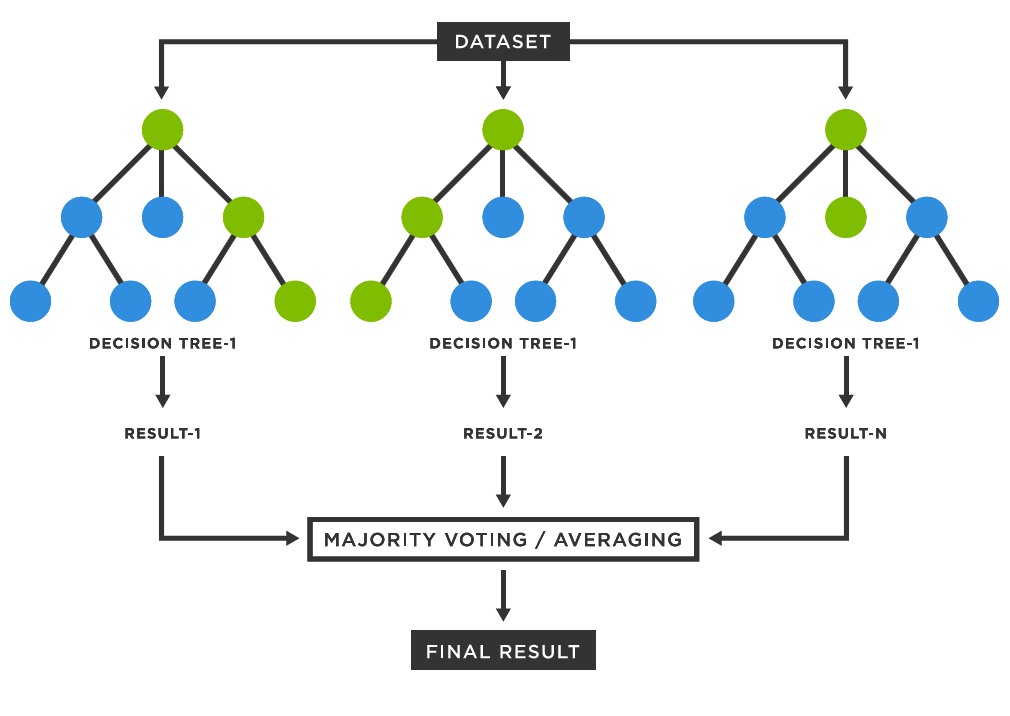

Advantages

- **Improved Accuracy**: By aggregating multiple trees, it reduces overfitting and improves accuracy.
- **Robustness**: Less sensitive to noise and outliers compared to individual decision trees.
- **Versatility**: Can handle both classification and regression tasks effectively.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(max_depth=10, n_estimators=100)

In [ ]:
RF_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [ ]:
preds = RF_model.predict(X_val)
score = accuracy_score(y_val, preds)
score

0.3950541516245487

<p align="justify"> Aunque no se tiene un desempeño muy alto con hiperparametros predefinidos o seleccionados arbitrareamente, se considera una excelente opcion para el problema, teniendo en cuenta que hace uso de árboles de desiciín, los cuales son buena opcion para el manejo de variables categoricas. Así mismo, el uso de varios árboles de desición permite reducir riesgos de *overfitting*.

<p align="justify"> De la misma forma, los modelos Random Forest permiten manejar gran cantidad de variables categoricas con mínimo procesaiento comparado con demás algoritmos.

#### Neural network

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim=X_train_clean2.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,804 (260.95 KB)

 Trainable params: 66,804 (260.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## Sin scaler
model.fit(X_train_clean2, y_train_clean2, validation_data=(X_val_clean2, y_val_clean2), epochs=15)

Epoch 1/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.4041 - loss: 1.2441 - val_accuracy: 0.4236 - val_loss: 1.2142
Epoch 2/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.4315 - loss: 1.2036 - val_accuracy: 0.4252 - val_loss: 1.2126
Epoch 3/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.4357 - loss: 1.1959 - val_accuracy: 0.4314 - val_loss: 1.2014
Epoch 4/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.4400 - loss: 1.1918 - val_accuracy: 0.4319 - val_loss: 1.2023
Epoch 5/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.4429 - loss: 1.1863 - val_accuracy: 0.4336 - val_loss: 1.1990
Epoch 6/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.4422 - loss: 1.1866 - val_accuracy: 0.4350 - val_loss: 1.1942
Epoch 7/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.4423 - loss: 1.1844 - val_accuracy: 0.4346 - val_loss: 1.1953
Epoch 8/15
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 

<p align="justify"> Las redes neuronales son especialmente buenas para manejar datasets con gran catidad de variables (alta dimensionalidad), pues el modelo tiene la capacidad de aprender patrones y relaciones complejas entre los datos. Esto se ve claramente con un modelo básico generado y el uso de los datos (one hot encoding) que permite tener un desempeño de cerca del 43% con los datos de validación generados.

<p align="justify"> Por otro lado, las redes neuronales permiten una facilidad y flexibilidad en la creación y entrenamiento de modelos tanto simples como complejos, con lo cual se pueden probar distintas configuraciones sobre los datos y generar conclusiones a partir de los mismos.

#### XGBoost

**Boosting:**

Boosting is an ensemble modelling, technique that attempts to build a strong classifier from the number of weak classifiers. It is done by building a model by using weak models in series. Firstly, a model is built from the training data. Then the second model is built which tries to correct the errors present in the first model. This procedure is continued and models are added until either the complete training data set is predicted correctly or the maximum number of models are added.

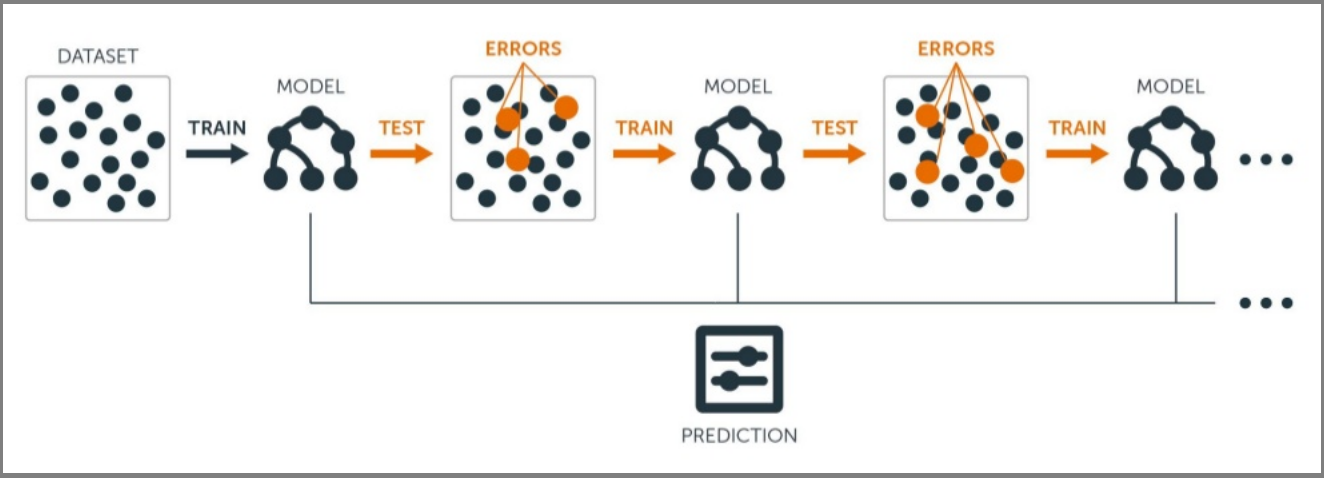

**XGBoost:**

XGBoost is a boosting algorithm that uses bagging, which trains multiple decision trees and then combines the results. It allows XGBoost to learn more quickly than other algorithms but also gives it an advantage in situations with many features to consider.

In boosting, the trees are built sequentially such that each subsequent tree aims to reduce the errors of the previous tree. Each tree learns from its predecessors and updates the residual errors. Hence, the tree that grows next in the sequence will learn from an updated version of the residuals.

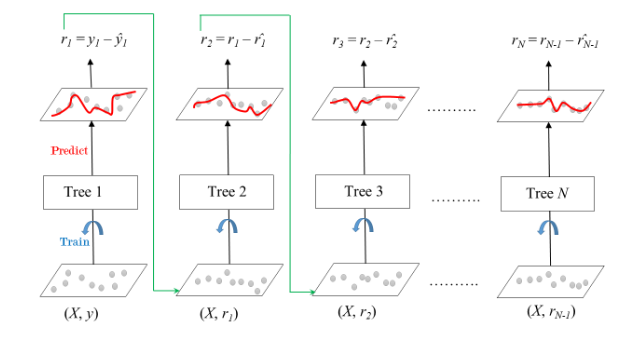

In [ ]:
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

dtrain

In [ ]:
params = {
    'max_depth': 6,
    'eta': 0.3,
    'objective': 'multi:softmax',
    'num_class': 4,
    'eval_metric': 'mlogloss'
}

num_round = 100
evallist = [(dval, 'eval'), (dtrain, 'train')]
bst = xgb.train(params, dtrain, num_round, evallist)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.34638	train-mlogloss:1.34627
[1]	eval-mlogloss:1.32168	train-mlogloss:1.32125
[2]	eval-mlogloss:1.30447	train-mlogloss:1.30377
[3]	eval-mlogloss:1.29262	train-mlogloss:1.29144
[4]	eval-mlogloss:1.28365	train-mlogloss:1.28216
[5]	eval-mlogloss:1.27686	train-mlogloss:1.27493
[6]	eval-mlogloss:1.27161	train-mlogloss:1.26939
[7]	eval-mlogloss:1.26701	train-mlogloss:1.26462
[8]	eval-mlogloss:1.26360	train-mlogloss:1.26085
[9]	eval-mlogloss:1.25966	train-mlogloss:1.25656
[10]	eval-mlogloss:1.25723	train-mlogloss:1.25384
[11]	eval-mlogloss:1.25499	train-mlogloss:1.25123
[12]	eval-mlogloss:1.25302	train-mlogloss:1.24899
[13]	eval-mlogloss:1.25109	train-mlogloss:1.24676
[14]	eval-mlogloss:1.24932	train-mlogloss:1.24468
[15]	eval-mlogloss:1.24807	train-mlogloss:1.24311
[16]	eval-mlogloss:1.24673	train-mlogloss:1.24144
[17]	eval-mlogloss:1.24548	train-mlogloss:1.23991
[18]	eval-mlogloss:1.24455	train-mlogloss:1.23871
[19]	eval-mlogloss:1.24361	train-mlogloss:1.23744
[20]	eval-

In [ ]:
score = accuracy_score(y_val, bst.predict(dval))
score

0.42941516245487366

<p align="justify"> Los modelos de XGBoost son conocidos por su desempeño en tareas de clasificacion con gran cantidad de datos tanto númericas como categóricas (especialmente con variables categoricas al usar árboles de desición de forma secuencial).

<p align="justify"> Así mismo, XGBoost es usado por su eficiencia y velocidad en la optimización (entrenamiento), así como por su robustes frente a problemas complejos, como el que se encontró.

### Exploración de hiperparámetros

#### Random Forest

**Parameters**

* **max_depth**: Maximum depth of the decision trees. Controls the complexity of the model. Deeper trees can capture more complex patterns but are more prone to overfitting.

* **n_estimators**: Number of decision trees in the forest, which would be used in parallel and their results will be combined.

In [ ]:
data_clean_RF_Clean2 = data_clean1(df, df, train=True)

<ipython-input-11-b6a7e09a5263>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values


In [ ]:
X_RF_Clean2, y_RF_Clean2 = data_clean_RF_Clean2.drop(columns=["RENDIMIENTO_GLOBAL"]), data_clean_RF_Clean2["RENDIMIENTO_GLOBAL"]
X_RF_Clean2.shape

(692500, 44)

In [ ]:
X_train_RF_Clean2, X_temp_RF_Clean2, y_train_RF_Clean2, y_temp_RF_Clean2 = train_test_split(X_RF_Clean2, y_RF_Clean2, test_size=0.4, stratify=y_RF_Clean2)
X_val_RF_Clean2, X_test_RF_Clean2, y_val_RF_Clean2, y_test_RF_Clean2 = train_test_split(X_temp_RF_Clean2, y_temp_RF_Clean2, test_size=0.5, stratify=y_temp_RF_Clean2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_Clean2=[]
for i in range(2, 20, 2):
  clf = RandomForestClassifier(max_depth=i, n_estimators=100)
  clf.fit(X_train_RF_Clean2, y_train_RF_Clean2)
  preds = clf.predict(X_val_RF_Clean2)
  score = accuracy_score(y_val_RF_Clean2, preds)
  RF_Clean2.append((clf,score))

In [ ]:
from sklearn import metrics
for i in range(len(RF_Clean2)):
  print("Max depth "+  str(i*2+2) +" - Accuracy train "+ str(accuracy_score(y_train_RF_Clean2, RF_Clean2[i][0].predict(X_train_RF_Clean2))) +" - Accuracy val "+ str(RF_Clean2[i][1]))
  print("Classification error : "+str(1-RF_Clean2[i][1]))
  confMatrix = metrics.confusion_matrix(y_val_RF_Clean2, RF_Clean2[i][0].predict(X_val_RF_Clean2))
  print(confMatrix)

Max depth 2 - Accuracy train 0.36383874849578823 - Accuracy val 0.3635162454873646
Classification error : 0.6364837545126354
[[24318  2598   996  6686]
 [21023  3206  1309  8917]
 [16752  3308  1518 12746]
 [ 9835  2591  1392 21305]]
Max depth 4 - Accuracy train 0.3720312876052948 - Accuracy val 0.3732129963898917
Classification error : 0.6267870036101083
[[22298  4655  2513  5132]
 [18281  5670  3124  7380]
 [13954  5551  3622 11197]
 [ 7680  4086  3257 20100]]
Max depth 6 - Accuracy train 0.3820385078219013 - Accuracy val 0.3828014440433213
Classification error : 0.6171985559566787
[[21096  4859  3440  5203]
 [16554  6074  4295  7532]
 [12315  5478  4896 11635]
 [ 6416  3518  4237 20952]]
Max depth 8 - Accuracy train 0.39266425992779785 - Accuracy val 0.3916606498194946
Classification error : 0.6083393501805054
[[20780  5281  3850  4687]
 [15984  6479  4946  7046]
 [11602  5622  5737 11363]
 [ 5705  3458  4711 21249]]
Max depth 10 - Accuracy train 0.40802406738868835 - Accuracy val 0

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_Clean2_est=[]
for i in range(1, 150, 5):
  clf = RandomForestClassifier(max_depth=14, n_estimators=i)
  clf.fit(X_train_RF_Clean2, y_train_RF_Clean2)
  preds = clf.predict(X_val_RF_Clean2)
  score = accuracy_score(y_val_RF_Clean2, preds)
  RF_Clean2_est.append((clf,score))

In [ ]:
from sklearn import metrics
for i in range(len(RF_Clean2_est)):
  print("Max depth "+  str(i*5+1) +" - Accuracy train "+ str(accuracy_score(y_train_RF_Clean2, RF_Clean2_est[i][0].predict(X_train_RF_Clean2))) +" - Accuracy val "+ str(RF_Clean2_est[i][1]))
  # print("Classification error : "+str(1-RF_Clean2[i][1]))
  # confMatrix = metrics.confusion_matrix(y_val_RF_Clean2, RF_Clean2[i][0].predict(X_val_RF_Clean2))
  # print(confMatrix)

Max depth 1 - Accuracy train 0.3941708784596871 - Accuracy val 0.37578339350180506
Max depth 6 - Accuracy train 0.43772563176895307 - Accuracy val 0.3925198555956679
Max depth 11 - Accuracy train 0.4549025270758123 - Accuracy val 0.4007075812274368
Max depth 16 - Accuracy train 0.4617858002406739 - Accuracy val 0.40175451263537904
Max depth 21 - Accuracy train 0.46230806257521057 - Accuracy val 0.4032418772563177
Max depth 26 - Accuracy train 0.4666666666666667 - Accuracy val 0.4046859205776173
Max depth 31 - Accuracy train 0.4669434416365824 - Accuracy val 0.4040649819494585
Max depth 36 - Accuracy train 0.4683008423586041 - Accuracy val 0.40506859205776174
Max depth 41 - Accuracy train 0.4716702767749699 - Accuracy val 0.40499638989169673
Max depth 46 - Accuracy train 0.4730348977135981 - Accuracy val 0.4055090252707581
Max depth 51 - Accuracy train 0.4716558363417569 - Accuracy val 0.405956678700361
Max depth 56 - Accuracy train 0.4709795427196149 - Accuracy val 0.40574007220216607


In [ ]:
X_train_complete_RF_Clean2 = np.concatenate((X_train_RF_Clean2, X_val_RF_Clean2), axis=0)
X_train_complete_RF_Clean2.shape

(554000, 44)

In [ ]:
y_train_complete_RF_Clean2 = np.concatenate((y_train_RF_Clean2, y_val_RF_Clean2), axis=0)
y_train_complete_RF_Clean2.shape

(554000,)

In [ ]:
best_DT = RandomForestClassifier(max_depth=14, n_estimators=100)
best_DT.fit(X_train_complete_RF_Clean2, y_train_complete_RF_Clean2)

RandomForestClassifier(max_depth=14)

In [ ]:
prediccion = best_DT.predict(X_test_RF_Clean2)
score = accuracy_score(y_test_RF_Clean2, prediccion)
score

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


0.4039350180505415

#### Neural network

In [ ]:
def create_model_Optimizer(input ,layers, neurons, act, learning_rate):

    newModel = Sequential()

    for i in range(layers+1):
        if i==0:
            newModel.add(Dense(units=neurons[i], input_shape=(input.shape[1],), activation=act[i]))
            newModel.add(Dropout(0.2))
        elif i==layers:
            newModel.add(Dense(units=4, activation='softmax'))
        else:
            newModel.add(Dense(units=neurons[i], activation=act[i]))
            newModel.add(Dropout(0.2))

    newModel.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=[
            'accuracy',
        ]
    )
    return newModel

##### **Learning rate**

In [ ]:
lrs=[1.0, 0.1, 0.01, 0.001, 0.0001]
models=[]
for lr in lrs:
    mod_x = create_model_Optimizer(X_train_clean2, 3, [64, 32, 16], ['relu' for i in range(3)], lr)
    train = mod_x.fit(X_train_clean2, y_train_clean2, validation_data=(X_val_clean2, y_val_clean2), epochs=10)
    score = mod_x.evaluate(X_val_clean2, y_val_clean2)
    models.append((train, score))

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.2487 - loss: 9.1704 - val_accuracy: 0.2488 - val_loss: 1.3964
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.2503 - loss: 1.4437 - val_accuracy: 0.2478 - val_loss: 1.4396
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.2493 - loss: 1.4459 - val_accuracy: 0.2488 - val_loss: 1.4156
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.2489 - loss: 1.4479 - val_accuracy: 0.2488 - val_loss: 1.4749
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 0.2505 - loss: 1.4432 - val_accuracy: 0.2536 - val_loss: 1.4282
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.2475 - loss: 1.4448 - val_accuracy: 0.2488 - val_loss: 1.6087
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.2504 - loss: 1.4453 - val_accuracy: 0.2536 - val_loss: 1.4539
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.2509 - loss: 1.4024 - val_accuracy: 0.2498 - val_loss: 1.3924
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.2505 - loss: 1.3935 - val_accuracy: 0.2488 - val_loss: 1.3899
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.2500 - loss: 1.3933 - val_accuracy: 0.2536 - val_loss: 1.3874
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.2490 - loss: 1.3936 - val_accuracy: 0.2498 - val_loss: 1.3930
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.2499 - loss: 1.3936 - val_accuracy: 0.2536 - val_loss: 1.3916
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.2515 - loss: 1.3936 - val_accuracy: 0.2488 - val_loss: 1.3926
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.2491 - loss: 1.3939 - val_accuracy: 0.2498 - val_loss: 1.3910
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.3771 - loss: 1.2848 - val_accuracy: 0.4014 - val_loss: 1.2501
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.3926 - loss: 1.2624 - val_accuracy: 0.4046 - val_loss: 1.2568
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.3947 - loss: 1.2589 - val_accuracy: 0.4060 - val_loss: 1.2356
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.3934 - loss: 1.2600 - val_accuracy: 0.4060 - val_loss: 1.2359
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.3937 - loss: 1.2597 - val_accuracy: 0.4083 - val_loss: 1.2284
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.3950 - loss: 1.2581 - val_accuracy: 0.3981 - val_loss: 1.2389
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.3945 - loss: 1.2597 - val_accuracy: 0.4068 - val_loss: 1.2519
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.3882 - loss: 1.2722 - val_accuracy: 0.4206 - val_loss: 1.2164
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.4172 - loss: 1.2279 - val_accuracy: 0.4248 - val_loss: 1.2130
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.4216 - loss: 1.2225 - val_accuracy: 0.4243 - val_loss: 1.2149
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.4226 - loss: 1.2196 - val_accuracy: 0.4251 - val_loss: 1.2138
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.4242 - loss: 1.2166 - val_accuracy: 0.4264 - val_loss: 1.2100
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.4264 - loss: 1.2154 - val_accuracy: 0.4272 - val_loss: 1.2080
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.4251 - loss: 1.2132 - val_accuracy: 0.4279 - val_loss: 1.2051
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.3394 - loss: 1.3303 - val_accuracy: 0.4105 - val_loss: 1.2351
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.4067 - loss: 1.2457 - val_accuracy: 0.4188 - val_loss: 1.2203
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.4161 - loss: 1.2303 - val_accuracy: 0.4216 - val_loss: 1.2137
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.4231 - loss: 1.2230 - val_accuracy: 0.4246 - val_loss: 1.2103
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.4252 - loss: 1.2175 - val_accuracy: 0.4276 - val_loss: 1.2088
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.4275 - loss: 1.2135 - val_accuracy: 0.4277 - val_loss: 1.2057
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.4293 - loss: 1.2125 - val_accuracy: 0.4291 - val_loss: 1.2067
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 

In [ ]:
for index in range(len(models)):
    print("Learning rate : "+str(lrs[index])+" Accuracy : "+str(models[index][1]))

Learning rate : 1.0 Accuracy : [1.397918939590454, 0.25360289216041565]
Learning rate : 0.1 Accuracy : [1.3899970054626465, 0.2478267103433609]
Learning rate : 0.01 Accuracy : [1.2509474754333496, 0.40979060530662537]
Learning rate : 0.001 Accuracy : [1.2095859050750732, 0.4295162558555603]
Learning rate : 0.0001 Accuracy : [1.2007099390029907, 0.43128520250320435]


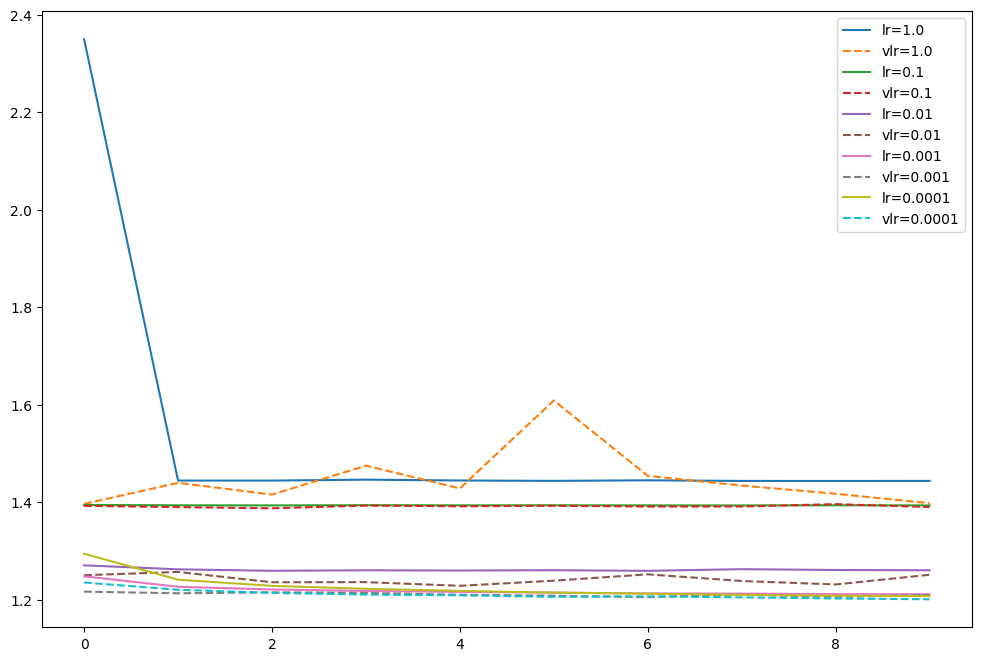

In [ ]:
plt.figure(figsize=(12, 8))
for index in range(len(models)):
    plt.plot(models[index][0].history['loss'], label=f'lr={lrs[index]}')
    plt.plot(models[index][0].history['val_loss'], linestyle='--', label=f'vlr={lrs[index]}')
plt.legend()
plt.show()

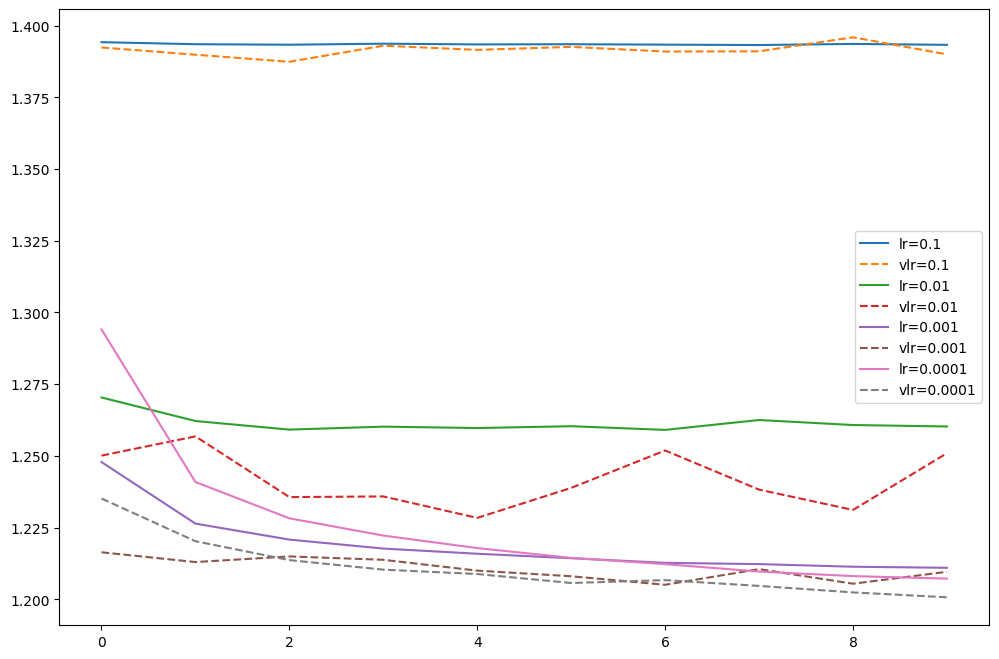

In [ ]:
plt.figure(figsize=(12, 8))
for index in range(1,len(models)):
    plt.plot(models[index][0].history['loss'], label=f'lr={lrs[index]}')
    plt.plot(models[index][0].history['val_loss'], linestyle='--', label=f'vlr={lrs[index]}')
plt.legend()
plt.show()

Se ve como claramente los mayores valores (1, 0.1) de *learning rate* no logran disminuir en mayor medida la función de perdida tanto en el dataset de entrenamiento y de validación. Ahora bien al disminuir un poco, se observa como la función de perdida disminuye pero al tener pasos tan grandes no llega a minimos sino que pasa entre puntos que aumentan o disminuyen la misma. Finalmente, valores como 0.001 y 0.0001 sugieren un buen paso a la minimización, pero se considera mejor el valor más pequeño partiendo de que el entrenamiento y validación disminuyen (disminución constante) de la misma manera, sin tener picos.

##### **Configuracion capas, número neuronas y función de activación**

In [ ]:
layers=range(1,4)
acts=['relu', 'tanh', 'sigmoid']
neurons = [96, 64,  32, 16]
models=[]
for layer in layers:
    for neuron_index in range(layer-1, len(neurons)):
        for act in acts:
            mod_x = create_model_Optimizer(X_train_clean2, layer, neurons[neuron_index-layer+1:neuron_index+1], [act for i in range(layer)], 0.0001)
            train = mod_x.fit(X_train_clean2, y_train_clean2, validation_data=(X_val_clean2, y_val_clean2), epochs=10)
            score = mod_x.evaluate(X_val_clean2, y_val_clean2)
            models.append((mod_x, train, score))

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.3574 - loss: 1.3113 - val_accuracy: 0.4138 - val_loss: 1.2366
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.4157 - loss: 1.2323 - val_accuracy: 0.4230 - val_loss: 1.2208
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.4243 - loss: 1.2189 - val_accuracy: 0.4254 - val_loss: 1.2150
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.4272 - loss: 1.2132 - val_accuracy: 0.4284 - val_loss: 1.2104
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.4322 - loss: 1.2077 - val_accuracy: 0.4283 - val_loss: 1.2092
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.4314 - loss: 1.2058 - val_accuracy: 0.4318 - val_loss: 1.2056
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.4348 - loss: 1.2018 - val_accuracy: 0.4316 - val_loss: 1.2048
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.3602 - loss: 1.3082 - val_accuracy: 0.4068 - val_loss: 1.2442
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - accuracy: 0.4064 - loss: 1.2442 - val_accuracy: 0.4102 - val_loss: 1.2360
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step - accuracy: 0.4113 - loss: 1.2360 - val_accuracy: 0.4113 - val_loss: 1.2328
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.4144 - loss: 1.2316 - val_accuracy: 0.4151 - val_loss: 1.2297
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.4161 - loss: 1.2305 - val_accuracy: 0.4157 - val_loss: 1.2277
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.4178 - loss: 1.2282 - val_accuracy: 0.4162 - val_loss: 1.2271
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.4182 - loss: 1.2273 - val_accuracy: 0.4168 - val_loss: 1.2278
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.3310 - loss: 1.3370 - val_accuracy: 0.4105 - val_loss: 1.2379
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - accuracy: 0.4066 - loss: 1.2461 - val_accuracy: 0.4188 - val_loss: 1.2188
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.4176 - loss: 1.2305 - val_accuracy: 0.4233 - val_loss: 1.2129
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 52s 4ms/step - accuracy: 0.4222 - loss: 1.2211 - val_accuracy: 0.4246 - val_loss: 1.2122
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 0.4258 - loss: 1.2178 - val_accuracy: 0.4286 - val_loss: 1.2064
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.4283 - loss: 1.2132 - val_accuracy: 0.4297 - val_loss: 1.2039
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 49s 4ms/step - accuracy: 0.4274 - loss: 1.2115 - val_accuracy: 0.4299 - val_loss: 1.2034
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - accuracy: 0.3478 - loss: 1.3297 - val_accuracy: 0.4072 - val_loss: 1.2444
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.4009 - loss: 1.2556 - val_accuracy: 0.4086 - val_loss: 1.2401
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.4054 - loss: 1.2473 - val_accuracy: 0.4090 - val_loss: 1.2392
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.4068 - loss: 1.2449 - val_accuracy: 0.4085 - val_loss: 1.2390
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.4093 - loss: 1.2429 - val_accuracy: 0.4100 - val_loss: 1.2382
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.4101 - loss: 1.2419 - val_accuracy: 0.4099 - val_loss: 1.2384
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.4098 - loss: 1.2417 - val_accuracy: 0.4101 - val_loss: 1.2377
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.2945 - loss: 1.3823 - val_accuracy: 0.3771 - val_loss: 1.2873
Epoch 2/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.3691 - loss: 1.2963 - val_accuracy: 0.3904 - val_loss: 1.2658
Epoch 3/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.3856 - loss: 1.2766 - val_accuracy: 0.3970 - val_loss: 1.2562
Epoch 4/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.3906 - loss: 1.2673 - val_accuracy: 0.4000 - val_loss: 1.2500
Epoch 5/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step - accuracy: 0.3938 - loss: 1.2623 - val_accuracy: 0.4031 - val_loss: 1.2457
Epoch 6/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.3976 - loss: 1.2558 - val_accuracy: 0.4043 - val_loss: 1.2424
Epoch 7/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 0.3997 - loss: 1.2536 - val_accuracy: 0.4072 - val_loss: 1.2383
Epoch 8/10
12985/12985 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 

In [ ]:
index=0
for layer in layers:
    for neuron_index in range(layer-1, len(neurons)):
        for act in acts:
            print('----------------------------------------------------------------' )
            print("Confioguration " + str(index) +" :")
            print("\t Number of layers: "+str(layer+1) )
            print("\t Neuron units: ")
            for i, x in enumerate(neurons[neuron_index-layer+1:neuron_index+1]):
                print("\t\t Layer "+ str(i+1)+" : "+str(x))
            print("\t\t Layer "+ str(layer+1)+" : 4")
            print("\t Activation function midLayers: "+act )
            print("\t Accuracy: "+ str(models[index][2]))
            index= index+1

----------------------------------------------------------------
Confioguration 0 :
	 Number of layers: 2
	 Neuron units: 
		 Layer 1 : 96
		 Layer 2 : 4
	 Activation function midLayers: relu
	 Accuracy: [1.2008376121520996, 0.4346137046813965]
----------------------------------------------------------------
Confioguration 1 :
	 Number of layers: 2
	 Neuron units: 
		 Layer 1 : 96
		 Layer 2 : 4
	 Activation function midLayers: tanh
	 Accuracy: [1.2268246412277222, 0.4190758168697357]
----------------------------------------------------------------
Confioguration 2 :
	 Number of layers: 2
	 Neuron units: 
		 Layer 1 : 96
		 Layer 2 : 4
	 Activation function midLayers: sigmoid
	 Accuracy: [1.2256207466125488, 0.4177400767803192]
----------------------------------------------------------------
Confioguration 3 :
	 Number of layers: 2
	 Neuron units: 
		 Layer 1 : 64
		 Layer 2 : 4
	 Activation function midLayers: relu
	 Accuracy: [1.2034622430801392, 0.4324909746646881]
-----------------

##### **Modelo con hiperparámetros**

In [ ]:
best_model_nn = create_model_Optimizer(X_train_clean2, 2, [96,64], ["relu" for i in range(2)], 0.0001)
best_model_nn.summary()

c:\Users\Sebastian Sarmiento\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 96)             │        95,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,700 (397.27 KB)

 Trainable params: 101,700 (397.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_complete = np.concatenate((X_train_clean2, X_val_clean2), axis=0)
X_train_complete.shape

(554000, 1001)

In [ ]:
y_train_complete = np.concatenate((y_train_clean2, y_val_clean2), axis=0)
y_train_complete.shape

(554000,)

In [ ]:
best_model_nn.fit(X_train_complete, y_train_complete, epochs=20)

Epoch 1/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - accuracy: 0.3636 - loss: 1.3019
Epoch 2/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.4188 - loss: 1.2247
Epoch 3/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 60s 3ms/step - accuracy: 0.4271 - loss: 1.2132
Epoch 4/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 57s 3ms/step - accuracy: 0.4318 - loss: 1.2066
Epoch 5/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - accuracy: 0.4323 - loss: 1.2038
Epoch 6/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - accuracy: 0.4343 - loss: 1.2008
Epoch 7/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 58s 3ms/step - accuracy: 0.4351 - loss: 1.1998
Epoch 8/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.4374 - loss: 1.1960
Epoch 9/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 47s 3ms/step - accuracy: 0.4380 - loss: 1.1963
Epoch 10/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.4399 - loss: 1.1931
Epoch 11/20
17313/17313 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - accuracy: 0.4403 - loss: 1.19

In [ ]:
best_model_nn.predict(X_test_clean2)

4329/4329 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


array([[0.07725438, 0.14547247, 0.29034275, 0.48693046],
       [0.21289262, 0.21665314, 0.27805746, 0.29239678],
       [0.21264036, 0.24492541, 0.29968655, 0.24274766],
       ...,
       [0.33874568, 0.3030304 , 0.25654638, 0.10167754],
       [0.2873106 , 0.35116035, 0.2478546 , 0.1136745 ],
       [0.19881226, 0.22584398, 0.30027097, 0.27507275]], dtype=float32)

In [ ]:
score = best_model_nn.evaluate(X_test_clean2, y_test_clean2)
score

4329/4329 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.4401 - loss: 1.1894


[1.1890463829040527, 0.43948736786842346]

#### XGBoost

**Parameters**

* **max_depth**: Maximum depth of the decision trees. Controls the complexity of the model. Deeper trees can capture more complex patterns but are more prone to overfitting.

* **eta**: Learning rate (also called shrinkage). Scales the contribution of each tree. Lower values make the model more robust to overfitting but require more boosting rounds.

* **objective**: Specifies the learning task. `'multi:softmax'` for multi-class classification with softmax activation.

* **num_class**: Number of classes in the target variable.

* **eval_metric**: Evaluation metric. `'mlogloss'` (multiclass log loss) measures the performance of the model.

* **num_round**: Number of boosting rounds, or iterations, that the model will go through. Each boosting round adds a new tree to the model in an attempt to correct the errors made by the previous trees.

In [ ]:
df_clean3 = data_clean1(df, df, train=True)

<ipython-input-3-b6a7e09a5263>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values


In [ ]:
df_clean3.head()

,PERIODO,ESTU_PRGM_ACADEMICO,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_EDUCACIONPADRE,FAMI_TIENELAVADORA,FAMI_TIENEAUTOMOVIL,ESTU_PRIVADO_LIBERTAD,...,ESTU_PRGM_DEPARTAMENTO_NORTE SANTANDER,ESTU_PRGM_DEPARTAMENTO_PUTUMAYO,ESTU_PRGM_DEPARTAMENTO_QUINDIO,ESTU_PRGM_DEPARTAMENTO_RISARALDA,ESTU_PRGM_DEPARTAMENTO_SAN ANDRES,ESTU_PRGM_DEPARTAMENTO_SANTANDER,ESTU_PRGM_DEPARTAMENTO_SUCRE,ESTU_PRGM_DEPARTAMENTO_TOLIMA,ESTU_PRGM_DEPARTAMENTO_VALLE,ESTU_PRGM_DEPARTAMENTO_VAUPES
ID,,,,,,,,,,,,,,,,,,,,,
904256,7,0,6,1,3,1,7,1,1,0,...,0,0,0,0,0,0,0,0,0,0
645256,7,1,4,0,3,0,8,1,0,0,...,0,0,0,0,0,0,0,0,0,0
308367,6,2,4,4,3,1,6,1,0,0,...,0,0,0,0,0,0,0,0,0,0
470353,3,3,5,0,4,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
989032,7,4,4,3,3,1,4,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X3, y3 =df_clean3.drop(columns=["RENDIMIENTO_GLOBAL"]), df_clean3["RENDIMIENTO_GLOBAL"]
X_train3, X_temp3, y_train3, y_temp3 = train_test_split(X3, y3, test_size=0.4, stratify=y3)
X_val3, X_test3, y_val3, y_test3 = train_test_split(X_temp3, y_temp3, test_size=0.5, stratify=y_temp3)

In [ ]:
import xgboost as xgb
dtrain3 = xgb.DMatrix(X_train3, label=y_train3)
dval3 = xgb.DMatrix(X_val3, label=y_val3)

dtrain3

##### **Learning rate**

In [ ]:
lrs3 = [1, 0.5, 0.4, 0.3, 0.2, 0.1, 0.001, 0.0001]
models_lr3= []
for lr3 in lrs3:
  params3 = {
      'max_depth': 6,
      'eta': lr3,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss'
  }

  num_round3 = 100
  evallist3 = [(dval3, 'eval'), (dtrain3, 'train')]
  evals_result3 = {}
  bst3 = xgb.train(params3, dtrain3, num_round3, evallist3, evals_result=evals_result3)
  score3 = accuracy_score(y_val3, bst3.predict(dval3))
  models_lr3.append((bst3, score3, evals_result3))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.28828	train-mlogloss:1.28757
[1]	eval-mlogloss:1.26634	train-mlogloss:1.26439
[2]	eval-mlogloss:1.25690	train-mlogloss:1.25329
[3]	eval-mlogloss:1.25068	train-mlogloss:1.24602
[4]	eval-mlogloss:1.24637	train-mlogloss:1.24077
[5]	eval-mlogloss:1.24258	train-mlogloss:1.23591
[6]	eval-mlogloss:1.23654	train-mlogloss:1.22908
[7]	eval-mlogloss:1.23468	train-mlogloss:1.22609
[8]	eval-mlogloss:1.23380	train-mlogloss:1.22405
[9]	eval-mlogloss:1.23179	train-mlogloss:1.22080
[10]	eval-mlogloss:1.23064	train-mlogloss:1.21875
[11]	eval-mlogloss:1.22788	train-mlogloss:1.21507
[12]	eval-mlogloss:1.22683	train-mlogloss:1.21299
[13]	eval-mlogloss:1.22374	train-mlogloss:1.20895
[14]	eval-mlogloss:1.22254	train-mlogloss:1.20672
[15]	eval-mlogloss:1.22043	train-mlogloss:1.20370
[16]	eval-mlogloss:1.22021	train-mlogloss:1.20232
[17]	eval-mlogloss:1.21814	train-mlogloss:1.19960
[18]	eval-mlogloss:1.21647	train-mlogloss:1.19712
[19]	eval-mlogloss:1.21571	train-mlogloss:1.19563
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.32370	train-mlogloss:1.32329
[1]	eval-mlogloss:1.29503	train-mlogloss:1.29413
[2]	eval-mlogloss:1.27920	train-mlogloss:1.27770
[3]	eval-mlogloss:1.26903	train-mlogloss:1.26689
[4]	eval-mlogloss:1.26220	train-mlogloss:1.25946
[5]	eval-mlogloss:1.25729	train-mlogloss:1.25394
[6]	eval-mlogloss:1.25288	train-mlogloss:1.24879
[7]	eval-mlogloss:1.24962	train-mlogloss:1.24488
[8]	eval-mlogloss:1.24720	train-mlogloss:1.24177
[9]	eval-mlogloss:1.24502	train-mlogloss:1.23894
[10]	eval-mlogloss:1.24258	train-mlogloss:1.23610
[11]	eval-mlogloss:1.24022	train-mlogloss:1.23323
[12]	eval-mlogloss:1.23910	train-mlogloss:1.23171
[13]	eval-mlogloss:1.23762	train-mlogloss:1.22976
[14]	eval-mlogloss:1.23618	train-mlogloss:1.22780
[15]	eval-mlogloss:1.23434	train-mlogloss:1.22546
[16]	eval-mlogloss:1.23362	train-mlogloss:1.22424
[17]	eval-mlogloss:1.23252	train-mlogloss:1.22260
[18]	eval-mlogloss:1.23114	train-mlogloss:1.22079
[19]	eval-mlogloss:1.23023	train-mlogloss:1.21938
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


...

[0]	eval-mlogloss:1.37168	train-mlogloss:1.37159
[1]	eval-mlogloss:1.35920	train-mlogloss:1.35903
[2]	eval-mlogloss:1.34843	train-mlogloss:1.34816
[3]	eval-mlogloss:1.33904	train-mlogloss:1.33864
[4]	eval-mlogloss:1.33080	train-mlogloss:1.33028
[5]	eval-mlogloss:1.32348	train-mlogloss:1.32284
[6]	eval-mlogloss:1.31693	train-mlogloss:1.31616
[7]	eval-mlogloss:1.31117	train-mlogloss:1.31029
[8]	eval-mlogloss:1.30591	train-mlogloss:1.30492
[9]	eval-mlogloss:1.30109	train-mlogloss:1.30004
[10]	eval-mlogloss:1.29682	train-mlogloss:1.29569
[11]	eval-mlogloss:1.29288	train-mlogloss:1.29168
[12]	eval-mlogloss:1.28933	train-mlogloss:1.28802
[13]	eval-mlogloss:1.28615	train-mlogloss:1.28472
[14]	eval-mlogloss:1.28325	train-mlogloss:1.28171
[15]	eval-mlogloss:1.28047	train-mlogloss:1.27884
[16]	eval-mlogloss:1.27797	train-mlogloss:1.27618
[17]	eval-mlogloss:1.27560	train-mlogloss:1.27372
[18]	eval-mlogloss:1.27356	train-mlogloss:1.27157
[19]	eval-mlogloss:1.27170	train-mlogloss:1.26957
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.38614	train-mlogloss:1.38614
[1]	eval-mlogloss:1.38599	train-mlogloss:1.38599
[2]	eval-mlogloss:1.38584	train-mlogloss:1.38584
[3]	eval-mlogloss:1.38569	train-mlogloss:1.38569
[4]	eval-mlogloss:1.38554	train-mlogloss:1.38554
[5]	eval-mlogloss:1.38539	train-mlogloss:1.38539
[6]	eval-mlogloss:1.38524	train-mlogloss:1.38524
[7]	eval-mlogloss:1.38509	train-mlogloss:1.38509
[8]	eval-mlogloss:1.38494	train-mlogloss:1.38493
[9]	eval-mlogloss:1.38479	train-mlogloss:1.38479
[10]	eval-mlogloss:1.38465	train-mlogloss:1.38464
[11]	eval-mlogloss:1.38450	train-mlogloss:1.38449
[12]	eval-mlogloss:1.38435	train-mlogloss:1.38434
[13]	eval-mlogloss:1.38420	train-mlogloss:1.38419
[14]	eval-mlogloss:1.38405	train-mlogloss:1.38404
[15]	eval-mlogloss:1.38390	train-mlogloss:1.38389
[16]	eval-mlogloss:1.38376	train-mlogloss:1.38374
[17]	eval-mlogloss:1.38361	train-mlogloss:1.38359
[18]	eval-mlogloss:1.38346	train-mlogloss:1.38345
[19]	eval-mlogloss:1.38332	train-mlogloss:1.38330
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.38628	train-mlogloss:1.38628
[1]	eval-mlogloss:1.38626	train-mlogloss:1.38626
[2]	eval-mlogloss:1.38625	train-mlogloss:1.38625
[3]	eval-mlogloss:1.38623	train-mlogloss:1.38623
[4]	eval-mlogloss:1.38622	train-mlogloss:1.38622
[5]	eval-mlogloss:1.38620	train-mlogloss:1.38620
[6]	eval-mlogloss:1.38619	train-mlogloss:1.38619
[7]	eval-mlogloss:1.38617	train-mlogloss:1.38617
[8]	eval-mlogloss:1.38616	train-mlogloss:1.38616
[9]	eval-mlogloss:1.38614	train-mlogloss:1.38614
[10]	eval-mlogloss:1.38613	train-mlogloss:1.38613
[11]	eval-mlogloss:1.38611	train-mlogloss:1.38611
[12]	eval-mlogloss:1.38610	train-mlogloss:1.38610
[13]	eval-mlogloss:1.38608	train-mlogloss:1.38608
[14]	eval-mlogloss:1.38607	train-mlogloss:1.38607
[15]	eval-mlogloss:1.38605	train-mlogloss:1.38605
[16]	eval-mlogloss:1.38604	train-mlogloss:1.38604
[17]	eval-mlogloss:1.38602	train-mlogloss:1.38602
[18]	eval-mlogloss:1.38601	train-mlogloss:1.38601
[19]	eval-mlogloss:1.38599	train-mlogloss:1.38599
[20]	eval-

In [ ]:
for index3 in range(len(models_lr3)):
    print("Learning rate : "+str(lrs3[index3])+" Accuracy : "+str(models_lr3[index3][1]))

Learning rate : 1 Accuracy : 0.42947292418772565
Learning rate : 0.5 Accuracy : 0.43339350180505415
Learning rate : 0.4 Accuracy : 0.4334873646209386
Learning rate : 0.3 Accuracy : 0.43189169675090255
Learning rate : 0.2 Accuracy : 0.42814440433212997
Learning rate : 0.1 Accuracy : 0.4195162454873646
Learning rate : 0.001 Accuracy : 0.3870180505415162
Learning rate : 0.0001 Accuracy : 0.38745126353790615


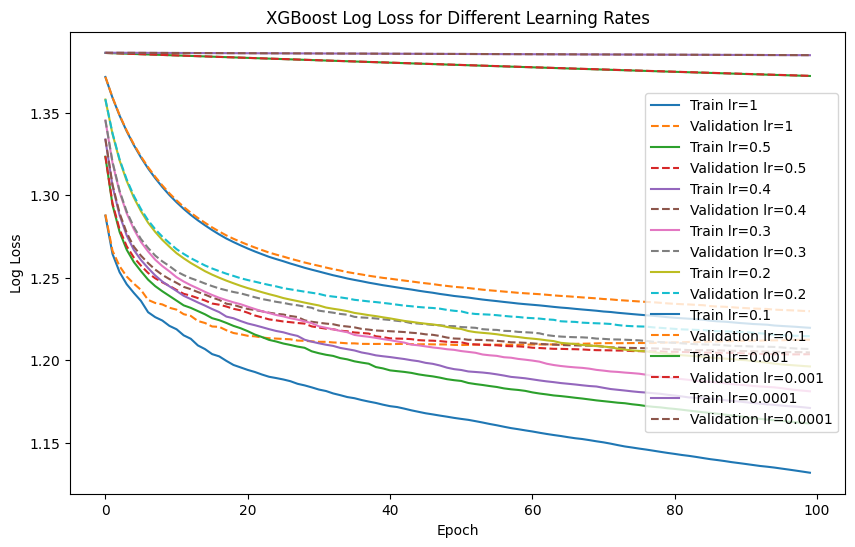

In [ ]:
plt.figure(figsize=(10, 6))

for index3 in range(len(models_lr3)):
    epochs3 = len(models_lr3[index3][2]['train']['mlogloss'])
    x_axis3 = range(0, epochs3)
    plt.plot(x_axis3, models_lr3[index3][2]['train']['mlogloss'], label=f'Train lr={lrs3[index3]}')
    plt.plot(x_axis3, models_lr3[index3][2]['eval']['mlogloss'],linestyle='--', label=f'Validation lr={lrs3[index3]}')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss for Different Learning Rates')
plt.show()

Se observa como altosvalores de tasa de aprendizaje (1, 0.4 y 0.5) tienen una rápida minimización en los datos de entrenamiento pero con los datos validados se entra en un limite en el cual no se observa disminución aparente despues de un punto. Por otro lado, con valores muy bajos (0.001 y 0.0001), es muy lenta la disminución lo cual no permite tener un avance evidente. Finalmente con los valores intermedios se nota una disminución tanto en el entrenamiento y validación, pero se nota una disminución más evidente y constante con un valor de 0.2.

##### **Max depth**

In [ ]:
dephts3 = range(2, 20, 2)
models_dp3= []
for depht3 in dephts3:
  params3 = {
      'max_depth': depht3,
      'eta': 0.2,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'subsample': 0.5
  }

  num_round3 = 100
  evallist3 = [(dval3, 'eval'), (dtrain3, 'train')]
  evals_result3 = {}
  bst3 = xgb.train(params3, dtrain3, num_round3, evallist3, evals_result=evals_result3)
  score3 = accuracy_score(y_val3, bst3.predict(dval3))
  models_dp3.append((bst3, score3, evals_result3))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36942	train-mlogloss:1.36924
[1]	eval-mlogloss:1.35658	train-mlogloss:1.35620
[2]	eval-mlogloss:1.34683	train-mlogloss:1.34632
[3]	eval-mlogloss:1.33915	train-mlogloss:1.33849
[4]	eval-mlogloss:1.33262	train-mlogloss:1.33189
[5]	eval-mlogloss:1.32707	train-mlogloss:1.32639
[6]	eval-mlogloss:1.32237	train-mlogloss:1.32158
[7]	eval-mlogloss:1.31831	train-mlogloss:1.31747
[8]	eval-mlogloss:1.31443	train-mlogloss:1.31354
[9]	eval-mlogloss:1.31133	train-mlogloss:1.31046
[10]	eval-mlogloss:1.30838	train-mlogloss:1.30739
[11]	eval-mlogloss:1.30583	train-mlogloss:1.30482
[12]	eval-mlogloss:1.30335	train-mlogloss:1.30233
[13]	eval-mlogloss:1.30125	train-mlogloss:1.30021
[14]	eval-mlogloss:1.29913	train-mlogloss:1.29810
[15]	eval-mlogloss:1.29721	train-mlogloss:1.29616
[16]	eval-mlogloss:1.29541	train-mlogloss:1.29438
[17]	eval-mlogloss:1.29395	train-mlogloss:1.29292
[18]	eval-mlogloss:1.29254	train-mlogloss:1.29143
[19]	eval-mlogloss:1.29113	train-mlogloss:1.29003
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36350	train-mlogloss:1.36315
[1]	eval-mlogloss:1.34650	train-mlogloss:1.34586
[2]	eval-mlogloss:1.33357	train-mlogloss:1.33267
[3]	eval-mlogloss:1.32313	train-mlogloss:1.32205
[4]	eval-mlogloss:1.31477	train-mlogloss:1.31350
[5]	eval-mlogloss:1.30805	train-mlogloss:1.30658
[6]	eval-mlogloss:1.30235	train-mlogloss:1.30075
[7]	eval-mlogloss:1.29729	train-mlogloss:1.29560
[8]	eval-mlogloss:1.29318	train-mlogloss:1.29139
[9]	eval-mlogloss:1.28966	train-mlogloss:1.28774
[10]	eval-mlogloss:1.28644	train-mlogloss:1.28446
[11]	eval-mlogloss:1.28377	train-mlogloss:1.28161
[12]	eval-mlogloss:1.28144	train-mlogloss:1.27919
[13]	eval-mlogloss:1.27920	train-mlogloss:1.27689
[14]	eval-mlogloss:1.27692	train-mlogloss:1.27454
[15]	eval-mlogloss:1.27497	train-mlogloss:1.27239
[16]	eval-mlogloss:1.27320	train-mlogloss:1.27056
[17]	eval-mlogloss:1.27151	train-mlogloss:1.26878
[18]	eval-mlogloss:1.27017	train-mlogloss:1.26734
[19]	eval-mlogloss:1.26872	train-mlogloss:1.26578
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


...

[0]	eval-mlogloss:1.35143	train-mlogloss:1.34056
[1]	eval-mlogloss:1.32582	train-mlogloss:1.30496
[2]	eval-mlogloss:1.30660	train-mlogloss:1.27638
[3]	eval-mlogloss:1.29162	train-mlogloss:1.25276
[4]	eval-mlogloss:1.28007	train-mlogloss:1.23317
[5]	eval-mlogloss:1.27097	train-mlogloss:1.21606
[6]	eval-mlogloss:1.26383	train-mlogloss:1.20140
[7]	eval-mlogloss:1.25796	train-mlogloss:1.18845
[8]	eval-mlogloss:1.25325	train-mlogloss:1.17646
[9]	eval-mlogloss:1.24926	train-mlogloss:1.16598
[10]	eval-mlogloss:1.24593	train-mlogloss:1.15668
[11]	eval-mlogloss:1.24318	train-mlogloss:1.14789
[12]	eval-mlogloss:1.24108	train-mlogloss:1.13995
[13]	eval-mlogloss:1.23888	train-mlogloss:1.13241
[14]	eval-mlogloss:1.23743	train-mlogloss:1.12540
[15]	eval-mlogloss:1.23614	train-mlogloss:1.11923
[16]	eval-mlogloss:1.23499	train-mlogloss:1.11336
[17]	eval-mlogloss:1.23393	train-mlogloss:1.10737
[18]	eval-mlogloss:1.23282	train-mlogloss:1.10210
[19]	eval-mlogloss:1.23217	train-mlogloss:1.09741
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.35120	train-mlogloss:1.33351
[1]	eval-mlogloss:1.32539	train-mlogloss:1.29180
[2]	eval-mlogloss:1.30621	train-mlogloss:1.25733
[3]	eval-mlogloss:1.29146	train-mlogloss:1.22851
[4]	eval-mlogloss:1.28002	train-mlogloss:1.20428
[5]	eval-mlogloss:1.27102	train-mlogloss:1.18305
[6]	eval-mlogloss:1.26387	train-mlogloss:1.16456
[7]	eval-mlogloss:1.25825	train-mlogloss:1.14820
[8]	eval-mlogloss:1.25384	train-mlogloss:1.13248
[9]	eval-mlogloss:1.25054	train-mlogloss:1.11866
[10]	eval-mlogloss:1.24765	train-mlogloss:1.10612
[11]	eval-mlogloss:1.24539	train-mlogloss:1.09498
[12]	eval-mlogloss:1.24380	train-mlogloss:1.08480
[13]	eval-mlogloss:1.24219	train-mlogloss:1.07579
[14]	eval-mlogloss:1.24117	train-mlogloss:1.06605
[15]	eval-mlogloss:1.24033	train-mlogloss:1.05755
[16]	eval-mlogloss:1.23935	train-mlogloss:1.04960
[17]	eval-mlogloss:1.23852	train-mlogloss:1.04196
[18]	eval-mlogloss:1.23783	train-mlogloss:1.03515
[19]	eval-mlogloss:1.23700	train-mlogloss:1.02829
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.35113	train-mlogloss:1.32598
[1]	eval-mlogloss:1.32551	train-mlogloss:1.27739
[2]	eval-mlogloss:1.30644	train-mlogloss:1.23697
[3]	eval-mlogloss:1.29169	train-mlogloss:1.20284
[4]	eval-mlogloss:1.28063	train-mlogloss:1.17379
[5]	eval-mlogloss:1.27204	train-mlogloss:1.14774
[6]	eval-mlogloss:1.26524	train-mlogloss:1.12533
[7]	eval-mlogloss:1.26000	train-mlogloss:1.10464
[8]	eval-mlogloss:1.25614	train-mlogloss:1.08473
[9]	eval-mlogloss:1.25326	train-mlogloss:1.06735
[10]	eval-mlogloss:1.25112	train-mlogloss:1.05144
[11]	eval-mlogloss:1.24940	train-mlogloss:1.03747
[12]	eval-mlogloss:1.24814	train-mlogloss:1.02488
[13]	eval-mlogloss:1.24689	train-mlogloss:1.01281
[14]	eval-mlogloss:1.24620	train-mlogloss:1.00038
[15]	eval-mlogloss:1.24563	train-mlogloss:0.98928
[16]	eval-mlogloss:1.24525	train-mlogloss:0.97988
[17]	eval-mlogloss:1.24489	train-mlogloss:0.97025
[18]	eval-mlogloss:1.24466	train-mlogloss:0.96212
[19]	eval-mlogloss:1.24477	train-mlogloss:0.95357
[20]	eval-

In [ ]:
for index3 in range(len(models_dp3)):
    print("Max depht : "+str(dephts3[index3])+" Accuracy : "+str(models_dp3[index3][1]))

Max depht : 2 Accuracy : 0.4029963898916967
Max depht : 4 Accuracy : 0.416014440433213
Max depht : 6 Accuracy : 0.4256028880866426
Max depht : 8 Accuracy : 0.42737184115523463
Max depht : 10 Accuracy : 0.4256534296028881
Max depht : 12 Accuracy : 0.42064981949458485
Max depht : 14 Accuracy : 0.413898916967509
Max depht : 16 Accuracy : 0.4062960288808664
Max depht : 18 Accuracy : 0.3983176895306859


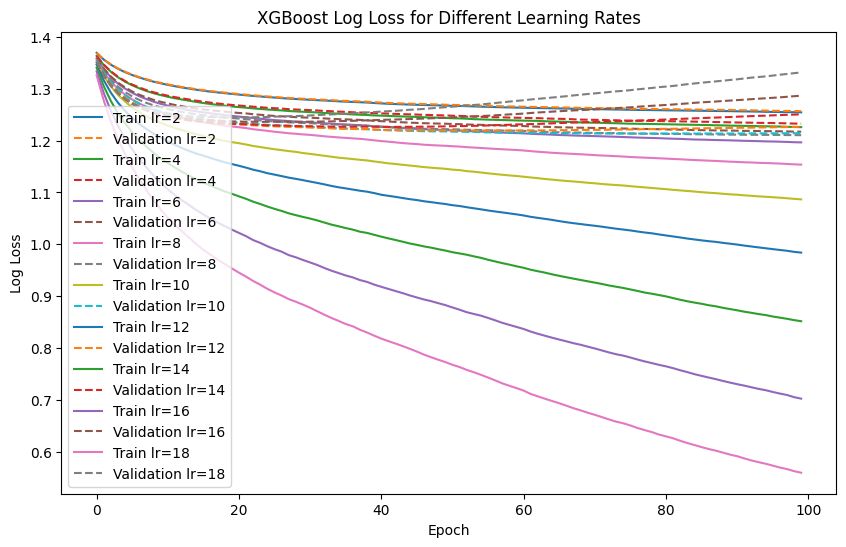

In [ ]:
plt.figure(figsize=(10, 6))

for index3 in range(len(models_dp3)):
    epochs3 = len(models_dp3[index3][2]['train']['mlogloss'])
    x_axis3 = range(0, epochs3)
    plt.plot(x_axis3, models_dp3[index3][2]['train']['mlogloss'], label=f'Train lr={dephts3[index3]}')
    plt.plot(x_axis3, models_dp3[index3][2]['eval']['mlogloss'],linestyle='--', label=f'Validation lr={dephts3[index3]}')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss for Different Learning Rates')
plt.show()

El gráfico de entrenamiento y minimización de la función de perdida nos muestra como entre mayor profundidad de los árboles de decisión, existen mayores indicios de overfitting, pues se tiene mejor rendimiento con los valores de entrenamiento pero la generalización con los valores de validación se mantienen igual. Así pues, teniendo un balance entre estos indicios de overfitting y el rendimiento, se hace elección de una profundidad de 5.

##### **min_child_weight**

In [ ]:
min3 = [0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
models_min3= []
for min in min3:
  params3 = {
      'max_depth': 5,
      'eta': 0.2,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'min_child_weight':min
  }

  num_round3 = 720
  evallist3 = [(dval3, 'eval'), (dtrain3, 'train')]
  evals_result3 = {}
  bst3 = xgb.train(params3, dtrain3, num_round3, evallist3, evals_result=evals_result3)
  score3 = accuracy_score(y_val3, bst3.predict(dval3))
  models_min3.append((bst3, score3, evals_result3))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27317	train-mlogloss:1.27104
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26886	train-mlogloss:1.26647
[15]	eval-mlogloss:1.26693	train-mlogloss:1.26446
[16]	eval-mlogloss:1.26509	train-mlogloss:1.26253
[17]	eval-mlogloss:1.26356	train-mlogloss:1.26087
[18]	eval-mlogloss:1.26206	train-mlogloss:1.25923
[19]	eval-mlogloss:1.26066	train-mlogloss:1.25779
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27317	train-mlogloss:1.27104
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26886	train-mlogloss:1.26647
[15]	eval-mlogloss:1.26693	train-mlogloss:1.26446
[16]	eval-mlogloss:1.26509	train-mlogloss:1.26253
[17]	eval-mlogloss:1.26356	train-mlogloss:1.26087
[18]	eval-mlogloss:1.26206	train-mlogloss:1.25923
[19]	eval-mlogloss:1.26066	train-mlogloss:1.25779
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


...

[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27316	train-mlogloss:1.27104
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26885	train-mlogloss:1.26648
[15]	eval-mlogloss:1.26693	train-mlogloss:1.26446
[16]	eval-mlogloss:1.26509	train-mlogloss:1.26253
[17]	eval-mlogloss:1.26356	train-mlogloss:1.26088
[18]	eval-mlogloss:1.26205	train-mlogloss:1.25923
[19]	eval-mlogloss:1.26065	train-mlogloss:1.25779
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27316	train-mlogloss:1.27104
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26885	train-mlogloss:1.26648
[15]	eval-mlogloss:1.26693	train-mlogloss:1.26446
[16]	eval-mlogloss:1.26509	train-mlogloss:1.26253
[17]	eval-mlogloss:1.26356	train-mlogloss:1.26088
[18]	eval-mlogloss:1.26205	train-mlogloss:1.25923
[19]	eval-mlogloss:1.26065	train-mlogloss:1.25779
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27316	train-mlogloss:1.27104
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26886	train-mlogloss:1.26648
[15]	eval-mlogloss:1.26694	train-mlogloss:1.26447
[16]	eval-mlogloss:1.26518	train-mlogloss:1.26262
[17]	eval-mlogloss:1.26366	train-mlogloss:1.26100
[18]	eval-mlogloss:1.26206	train-mlogloss:1.25928
[19]	eval-mlogloss:1.26093	train-mlogloss:1.25805
[20]	eval-

In [ ]:
for index3 in range(len(models_min3)):
    print("Min_child_weight : "+str(min3[index3])+" Accuracy : "+str(models_min3[index3][1]))

Min_child_weight : 0.1 Accuracy : 0.4342527075812274
Min_child_weight : 0.2 Accuracy : 0.43431768953068595
Min_child_weight : 0.3 Accuracy : 0.4345342960288809
Min_child_weight : 0.5 Accuracy : 0.43457039711191336
Min_child_weight : 0.6 Accuracy : 0.4348808664259928
Min_child_weight : 0.7 Accuracy : 0.4347870036101083
Min_child_weight : 0.8 Accuracy : 0.4344259927797834
Min_child_weight : 0.9 Accuracy : 0.43501805054151627
Min_child_weight : 1 Accuracy : 0.4339638989169675


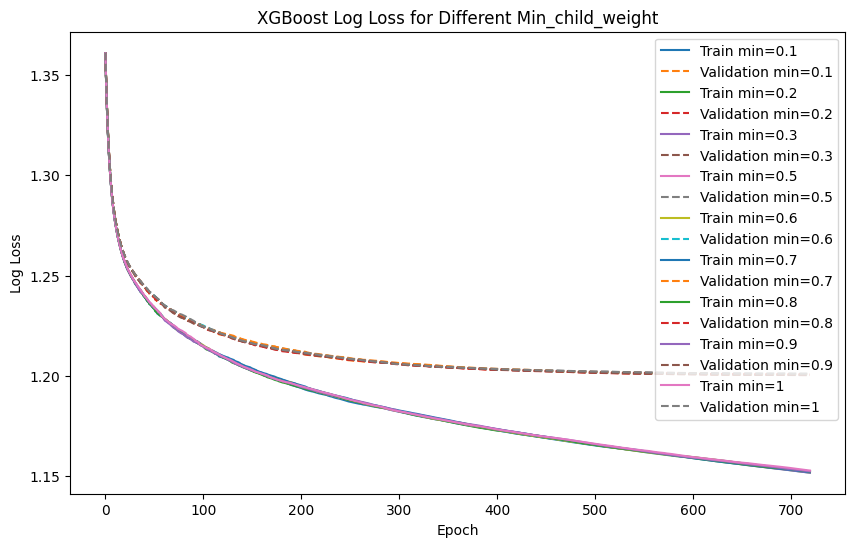

In [ ]:
plt.figure(figsize=(10, 6))

for index3 in range(len(models_min3)):
    epochs3 = len(models_min3[index3][2]['train']['mlogloss'])
    x_axis3 = range(0, epochs3)
    plt.plot(x_axis3, models_min3[index3][2]['train']['mlogloss'], label=f'Train min={min3[index3]}')
    plt.plot(x_axis3, models_min3[index3][2]['eval']['mlogloss'],linestyle='--', label=f'Validation min={min3[index3]}')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss for Different Min_child_weight')
plt.show()

In [ ]:
min3_2 = [1.2, 1.5, 2, 2.2, 2.5, 3, 3.2, 3.5]
for min in min3_2:
  params3 = {
      'max_depth': 5,
      'eta': 0.2,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'min_child_weight':min
  }

  num_round3 = 720
  evallist3 = [(dval3, 'eval'), (dtrain3, 'train')]
  evals_result3 = {}
  bst3 = xgb.train(params3, dtrain3, num_round3, evallist3, evals_result=evals_result3)
  score3 = accuracy_score(y_val3, bst3.predict(dval3))
  models_min3.append((bst3, score3, evals_result3))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28167	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27835	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27573	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27316	train-mlogloss:1.27105
[13]	eval-mlogloss:1.27085	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26886	train-mlogloss:1.26649
[15]	eval-mlogloss:1.26694	train-mlogloss:1.26447
[16]	eval-mlogloss:1.26518	train-mlogloss:1.26262
[17]	eval-mlogloss:1.26366	train-mlogloss:1.26100
[18]	eval-mlogloss:1.26206	train-mlogloss:1.25928
[19]	eval-mlogloss:1.26093	train-mlogloss:1.25805
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30116	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28166	train-mlogloss:1.27983
[10]	eval-mlogloss:1.27834	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27572	train-mlogloss:1.27365
[12]	eval-mlogloss:1.27316	train-mlogloss:1.27105
[13]	eval-mlogloss:1.27084	train-mlogloss:1.26859
[14]	eval-mlogloss:1.26886	train-mlogloss:1.26649
[15]	eval-mlogloss:1.26693	train-mlogloss:1.26447
[16]	eval-mlogloss:1.26517	train-mlogloss:1.26262
[17]	eval-mlogloss:1.26365	train-mlogloss:1.26100
[18]	eval-mlogloss:1.26205	train-mlogloss:1.25928
[19]	eval-mlogloss:1.26092	train-mlogloss:1.25805
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


...

[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30115	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28166	train-mlogloss:1.27984
[10]	eval-mlogloss:1.27834	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27572	train-mlogloss:1.27366
[12]	eval-mlogloss:1.27315	train-mlogloss:1.27105
[13]	eval-mlogloss:1.27086	train-mlogloss:1.26861
[14]	eval-mlogloss:1.26885	train-mlogloss:1.26649
[15]	eval-mlogloss:1.26696	train-mlogloss:1.26449
[16]	eval-mlogloss:1.26518	train-mlogloss:1.26262
[17]	eval-mlogloss:1.26365	train-mlogloss:1.26100
[18]	eval-mlogloss:1.26208	train-mlogloss:1.25936
[19]	eval-mlogloss:1.26106	train-mlogloss:1.25821
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30115	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29344
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28166	train-mlogloss:1.27984
[10]	eval-mlogloss:1.27834	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27572	train-mlogloss:1.27366
[12]	eval-mlogloss:1.27315	train-mlogloss:1.27105
[13]	eval-mlogloss:1.27086	train-mlogloss:1.26861
[14]	eval-mlogloss:1.26885	train-mlogloss:1.26649
[15]	eval-mlogloss:1.26696	train-mlogloss:1.26449
[16]	eval-mlogloss:1.26519	train-mlogloss:1.26263
[17]	eval-mlogloss:1.26366	train-mlogloss:1.26101
[18]	eval-mlogloss:1.26209	train-mlogloss:1.25936
[19]	eval-mlogloss:1.26107	train-mlogloss:1.25821
[20]	eval-

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.36115	train-mlogloss:1.36088
[1]	eval-mlogloss:1.34277	train-mlogloss:1.34215
[2]	eval-mlogloss:1.32864	train-mlogloss:1.32782
[3]	eval-mlogloss:1.31741	train-mlogloss:1.31633
[4]	eval-mlogloss:1.30835	train-mlogloss:1.30710
[5]	eval-mlogloss:1.30115	train-mlogloss:1.29973
[6]	eval-mlogloss:1.29507	train-mlogloss:1.29345
[7]	eval-mlogloss:1.28977	train-mlogloss:1.28808
[8]	eval-mlogloss:1.28548	train-mlogloss:1.28368
[9]	eval-mlogloss:1.28166	train-mlogloss:1.27984
[10]	eval-mlogloss:1.27834	train-mlogloss:1.27647
[11]	eval-mlogloss:1.27572	train-mlogloss:1.27366
[12]	eval-mlogloss:1.27315	train-mlogloss:1.27105
[13]	eval-mlogloss:1.27086	train-mlogloss:1.26861
[14]	eval-mlogloss:1.26885	train-mlogloss:1.26649
[15]	eval-mlogloss:1.26696	train-mlogloss:1.26449
[16]	eval-mlogloss:1.26518	train-mlogloss:1.26263
[17]	eval-mlogloss:1.26365	train-mlogloss:1.26101
[18]	eval-mlogloss:1.26207	train-mlogloss:1.25936
[19]	eval-mlogloss:1.26106	train-mlogloss:1.25821
[20]	eval-

In [ ]:
min_total = min3 + min3_2
for index3 in range(len(models_min3)):
    print("Min_child_weight : "+str(min_total[index3])+" Accuracy : "+str(models_min3[index3][1]))

Min_child_weight : 0.1 Accuracy : 0.4342527075812274
Min_child_weight : 0.2 Accuracy : 0.43431768953068595
Min_child_weight : 0.3 Accuracy : 0.4345342960288809
Min_child_weight : 0.5 Accuracy : 0.43457039711191336
Min_child_weight : 0.6 Accuracy : 0.4348808664259928
Min_child_weight : 0.7 Accuracy : 0.4347870036101083
Min_child_weight : 0.8 Accuracy : 0.4344259927797834
Min_child_weight : 0.9 Accuracy : 0.43501805054151627
Min_child_weight : 1 Accuracy : 0.4339638989169675
Min_child_weight : 1.2 Accuracy : 0.43412274368231046
Min_child_weight : 1.5 Accuracy : 0.4348808664259928
Min_child_weight : 2 Accuracy : 0.4344187725631769
Min_child_weight : 2.2 Accuracy : 0.4349602888086643
Min_child_weight : 2.5 Accuracy : 0.4354657039711191
Min_child_weight : 3 Accuracy : 0.4341083032490975
Min_child_weight : 3.2 Accuracy : 0.433942238267148
Min_child_weight : 3.5 Accuracy : 0.4348231046931408


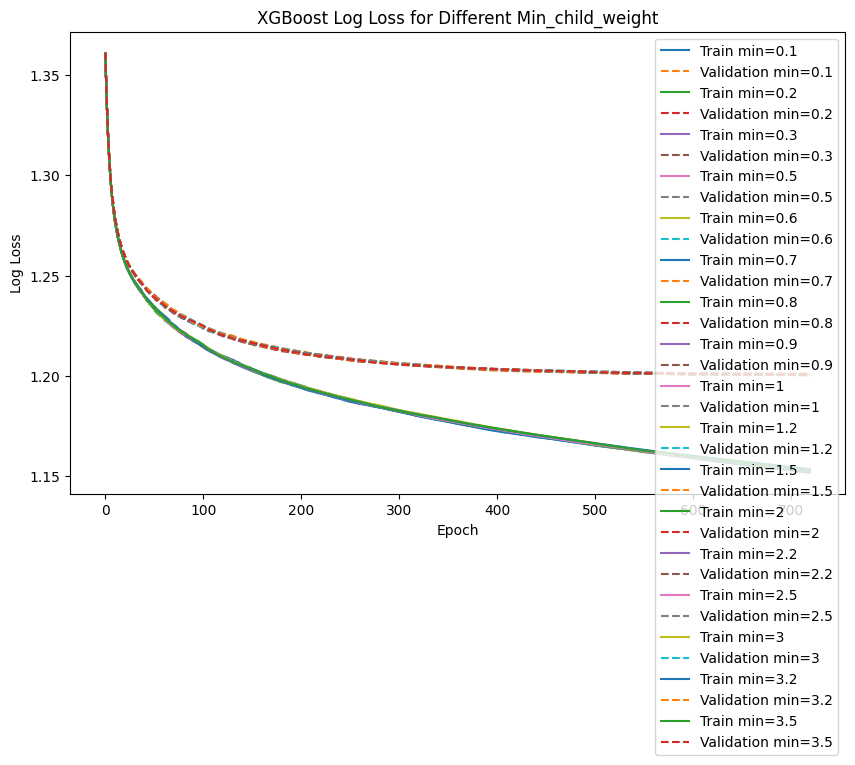

In [ ]:
plt.figure(figsize=(10, 6))

for index3 in range(len(models_min3)):
    epochs3 = len(models_min3[index3][2]['train']['mlogloss'])
    x_axis3 = range(0, epochs3)
    plt.plot(x_axis3, models_min3[index3][2]['train']['mlogloss'], label=f'Train min={min_total[index3]}')
    plt.plot(x_axis3, models_min3[index3][2]['eval']['mlogloss'],linestyle='--', label=f'Validation min={min_total[index3]}')

plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss for Different Min_child_weight')
plt.show()

Basandose en la curva de aprendizaje con los diferentes valores del parámtro, no se evidencia gran diferencia entre cada una de ellas, con lo cual se hara uso de un valor que halla tenido una presición en el dataset de validación alta, teniendo en cuenta que preferimos valores no muy grandes, para tener un comportamiento menos conservatiovo del modelo (documentación libreria), se seleccionó 2.0.

In [ ]:
params3 = {
      'max_depth': 6,
      'eta': 0.2,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'subsample' : 0.5
  }

num_round3 = 250
evallist3 = [(dval3, 'eval'), (dtrain3, 'train')]
evals_result3 = {}
bst3 = xgb.train(params3, dtrain3, num_round3, evallist3, evals_result=evals_result3)
score3 = accuracy_score(y_val3, bst3.predict(dval3))
score3

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:727: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[0]	eval-mlogloss:1.35916	train-mlogloss:1.35861
[1]	eval-mlogloss:1.33903	train-mlogloss:1.33797
[2]	eval-mlogloss:1.32364	train-mlogloss:1.32215
[3]	eval-mlogloss:1.31175	train-mlogloss:1.30988
[4]	eval-mlogloss:1.30247	train-mlogloss:1.30026
[5]	eval-mlogloss:1.29469	train-mlogloss:1.29212
[6]	eval-mlogloss:1.28834	train-mlogloss:1.28545
[7]	eval-mlogloss:1.28331	train-mlogloss:1.28006
[8]	eval-mlogloss:1.27854	train-mlogloss:1.27498
[9]	eval-mlogloss:1.27482	train-mlogloss:1.27087
[10]	eval-mlogloss:1.27170	train-mlogloss:1.26734
[11]	eval-mlogloss:1.26866	train-mlogloss:1.26402
[12]	eval-mlogloss:1.26632	train-mlogloss:1.26140
[13]	eval-mlogloss:1.26373	train-mlogloss:1.25858
[14]	eval-mlogloss:1.26183	train-mlogloss:1.25642
[15]	eval-mlogloss:1.26013	train-mlogloss:1.25441
[16]	eval-mlogloss:1.25857	train-mlogloss:1.25260
[17]	eval-mlogloss:1.25718	train-mlogloss:1.25085
[18]	eval-mlogloss:1.25589	train-mlogloss:1.24932
[19]	eval-mlogloss:1.25443	train-mlogloss:1.24764
[20]	eval-

0.43175451263537906

In [ ]:
prediccion3 = bst3.predict(dval3)

In [ ]:
prediccion3

array([2., 1., 1., ..., 0., 3., 3.], dtype=float32)

In [ ]:
score3 = accuracy_score(y_val3, prediccion3)
score3

0.43175451263537906

In [ ]:
X_train_complete3 = np.concatenate((X_train3, X_val3), axis=0)
X_train_complete3.shape

(554000, 44)

In [ ]:
y_train_complete3 = np.concatenate((y_train3, y_val3), axis=0)
y_train_complete3.shape

(554000,)

In [ ]:
dtrain_complete3 = xgb.DMatrix(X_train_complete3, label=y_train_complete3)

##### **Num rounds**

In [ ]:
lr_final = 0.2
sampling = 0.5
depths = [5, 6, 7, 8]
cv_final = []
for depth in depths:
  params3 = {
      'max_depth': depth,
      'eta': lr_final,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'min_child_weight': 2.0
  }
  cv_results = xgb.cv(
    params3,
    dtrain_complete3,
    num_boost_round=1000,  # Maximum number of boosting rounds
    nfold=8,  # Number of cross-validation folds
    metrics={'mlogloss'},  # Evaluation metric
    early_stopping_rounds=10,  # Stop if no improvement in 10 rounds
  )

# Best number of boosting rounds
  cv_final.append(cv_results)

In [ ]:
for index3 in range(len(cv_final)):
    print("Max depht : "+str(depths[index3])+" Boost rounds : "+str(cv_final[index3].shape[0]))

Max depht : 5 Boost rounds : 702
Max depht : 6 Boost rounds : 471
Max depht : 7 Boost rounds : 304
Max depht : 8 Boost rounds : 208


In [ ]:
lr_final = 0.2
sampling = 0.5
depths = [5, 6]
cv_final = []
for depth in depths:
  params3 = {
      'max_depth': depth,
      'eta': lr_final,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'min_child_weight': 2.0
  }
  cv_results = xgb.cv(
    params3,
    dtrain_complete3,
    num_boost_round=1000,  # Maximum number of boosting rounds
    nfold=8,  # Number of cross-validation folds
    metrics={'mlogloss'},  # Evaluation metric
    early_stopping_rounds=10,  # Stop if no improvement in 10 rounds
  )

# Best number of boosting rounds
  cv_final.append(cv_results)

In [ ]:
for index3 in range(len(cv_final)):
    print("Max depht : "+str(depths[index3])+" Boost rounds : "+str(cv_final[index3].shape[0]))

Max depht : 5 Boost rounds : 768
Max depht : 6 Boost rounds : 488


Para determinar el número de árboles de desición para el proceso de boosting, se hace uso de corss validation con la función *cv*, el cual permite determinar el rendimiento del modelo sobre conjuntos de datos diferentes para entrenar y validar. De esta manera, se selecciona el número de árboles efectivos teniendo en cuenta el mejor rendimiento. (800)

##### **Modelo con hiperparámetros**

In [ ]:
params_final3 = {
      'max_depth': 5,
      'eta': 0.2,
      'objective': 'multi:softmax',
      'num_class': 4,
      'eval_metric': 'mlogloss',
      'min_child_weight': 0.8
  }
num_round_final3 = 720

In [ ]:
bst_final3 = xgb.train(params_final3, dtrain_complete3, num_round_final3)

In [ ]:
dtest3 = xgb.DMatrix(X_test3)
prediccion3 = bst_final3.predict(dtest3)
score3 = accuracy_score(y_test3, prediccion3)
score3

0.436086642599278

#### Seleccion de modelo

Teniendo en cuenta el rendimiento de los modelos, es calro que la decisión dbee encontrarse entre las **redes neuronales** y el **XGBoost**. Únicamente basado en el rendimiento sobre datos de validación, se deberia seleccionar la red neuronal, pero teniendo en cuenta el potencial de XGBoost para problemas como estos y que las redes neuronales pueden tener problemas al inferir teniendo en cuenta categorias no usadas para entrenar o para que estan completamente en 0, se decide elegir el modelo de **XGBOOST**.

### Evaluación del desempeño sistemática del modelo final seleccionado

##### **Modelo final**

In [ ]:
bst_xgb = xgb.XGBClassifier(
    max_depth= 5,
    learning_rate= 0.2,
    objective= 'multi:softmax',
    num_class= 4,
    eval_metric= 'mlogloss',
    min_child_weight= 2.0,
    n_estimators=800,
)

In [ ]:
X_train_complete = np.concatenate((X_train, X_val), axis=0)
X_train_complete.shape

(554000, 44)

In [ ]:
y_train_complete = np.concatenate((y_train, y_val), axis=0)
y_train_complete.shape

(554000,)

In [ ]:
bst_xgb.fit(X_train_complete, y_train_complete)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=2.0, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=800,
              n_jobs=None, num_class=4, num_parallel_tree=None, ...)

In [ ]:
best_prediction = bst_xgb.predict(X_test)
best_prediction_proba = bst_xgb.predict_proba(X_test)
best_score = accuracy_score(y_test, best_prediction)
best_score

0.43612996389891695

##### **Métricas y evaluación**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize

Algunas de las métricas requieren atributo de avergae adicional para poder tener medidas sobre tareas de clasificación multiclase, para esto se usara el tipo weighted.

**Wighted**: Calculate metrics for each label, and find their average weighted by support (the number of true instances for each label). This alters ‘macro’ to account for label imbalance; it can result in an F-score that is not between precision and recall.

In [ ]:
# Precisión
accuracy = accuracy_score(y_test, best_prediction)
# Precisión
precision = precision_score(y_test, best_prediction, average='weighted')
# Recall
recall = recall_score(y_test, best_prediction, average='weighted')
# Binarizar las etiquetas para calcular el AUC-ROC para cada clase
y_test_binarized = label_binarize(y_test, classes=np.arange(4))
auc_roc = roc_auc_score(y_test_binarized, best_prediction_proba, multi_class='ovo', average='weighted')

# Imprimir las métricas
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'AUC-ROC: {auc_roc:.4f}')

Accuracy: 0.4361
Precision: 0.4213
Recall: 0.4361
AUC-ROC: 0.7069


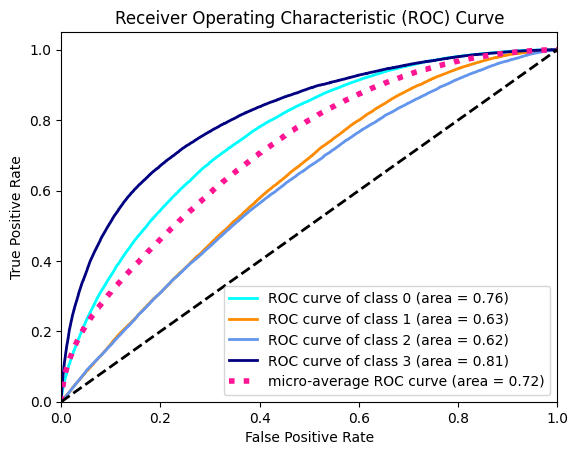

In [ ]:
# Calcular la curva ROC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(np.unique(y))):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], best_prediction_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular la curva ROC media
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), best_prediction_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Dibujar todas las curvas ROC
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'navy']

for i, color in zip(range(len(np.unique(y))), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
                   ''.format(i, roc_auc[i]))

plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4, label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Documentación**

AUC: Scalar that summarizes the performance of a classifier. It represents the probability that a classifier will rank a randomly chosen positive instance higher than a randomly chosen negative one.
- 0.5: No discrimination (equivalent to random guessing).
- 1: Perfect discrimination.
- 0: Perfect inverse discrimination (worst possible model).

**Desempeño individual**

* Clase 0: La curva para esta clase (rendimiento bajo), tiene un AUC de 0.76, lo cual indica un desempeño bueno pra distinguir esta clase de la demás.

* Clase 1:  La curva tiene un AUC de 0.63 para esta clase (renimiento medio-bajo), lo cual indica que el modelo no es muy bueno diciminando esta clase de las demás.

* Clase 2 : La curva para esta clase (renimiento medio-alto) tiene un AUC de 0.62 como en el caso de la clase 1, por lo cual de la misma forma se intuye que el modelo no es muy bueno diciminando esta clase de las demás.

* Clase 3: La curva para esta clase (renimiento alto) tiene un AUC de 0.81, lo cual indica un muy buen desempeño por parte del modelo para discriminar esta clase sobre las demás.

Así pues, se puede observar que es claro como los renimientos extremos (alto y bajo) son fácilmente identificables, mientras los rendimientos medio conllevan reconocimiento más complejo lo que indica que los datos para estos dos son similares y varian en poca medida.

**Desempeño general**

Curva Micro-average ROC:
* Micro :Calculate metrics globally by counting the total true positives, false negatives and false positives.

La curva la cual muestra el desempeño general sobre todas las clases (promedio de los demás desempeños) tiene un AUC de 0.72, lo que indica que en general el modelo tiene un desempeño moderado para la tarea de clasificación.

In [ ]:
# Reporte de clasificación detallado
print(classification_report(y_test, best_prediction))

              precision    recall  f1-score   support

           0       0.46      0.56      0.51     34597
           1       0.33      0.27      0.30     34455
           2       0.34      0.27      0.30     34324
           3       0.55      0.63      0.59     35124

    accuracy                           0.44    138500
   macro avg       0.42      0.43      0.42    138500
weighted avg       0.42      0.44      0.43    138500



Confusion Matrix:
[[19545  7700  4607  2745]
 [12562  9432  7382  5079]
 [ 7331  7657  9319 10017]
 [ 2866  3672  6478 22108]]


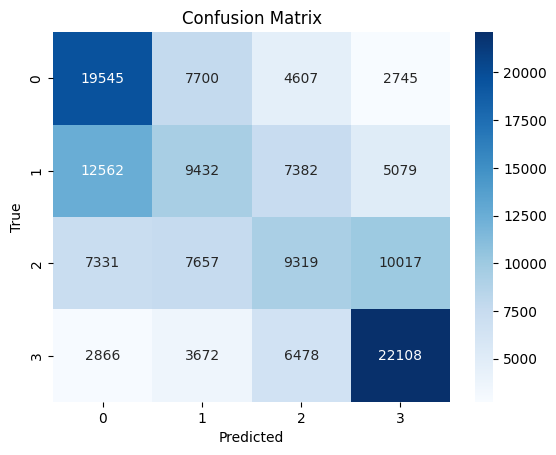

In [ ]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, best_prediction)
print('Confusion Matrix:')
print(conf_matrix)

# Visualizar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Se observa la ditribución de elecciones y correctitud de la misma, donde comprueba lo observado en la curva ROC, donde se tienen mayor cantidad de aciertos en las categorias extremas (rendimeinto alto y bajo). Así mismo, se observa que la lógica del modelo es buena puesto se tienen una buena distribución de elecciones, sin tener mucha cantidad de elecciones iguales (Casos en los que solo selecciono una categoria y hay aparente buen desempeño). Por otro lado, se evidencia que los renidmientos predecidos se encuentran cercanos a su valor real, pues hay muy pocos registros en las esquinas inferior izquierda y superior derecha.

In [ ]:
# Definir el esquema de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ejecutar cross-validation y calcular metricas
cv_accuracy = cross_val_score(bst_xgb, X, y, cv=cv, scoring='accuracy')
cv_precision_weighted = cross_val_score(bst_xgb, X, y, cv=cv, scoring='precision_weighted')
cv_recall_weighted = cross_val_score(bst_xgb, X, y, cv=cv, scoring='recall_weighted')
cv_auc_weighted = cross_val_score(bst_xgb, X, y, cv=cv, scoring='roc_auc_ovr_weighted')

# Imprimir métricas de cross-validation
print(f'Cross-Validated Accuracy: {np.mean(cv_accuracy):.4f}')
print(f'Cross-Validated Precision (Weighted): {np.mean(cv_precision_weighted):.4f}')
print(f'Cross-Validated Recall (Weighted): {np.mean(cv_recall_weighted):.4f}')
print(f'Cross-Validated AUC-ROC (Weighted): {np.mean(cv_auc_weighted):.4f}')

Cross-Validated Accuracy: 0.4360
Cross-Validated Precision (Weighted): 0.4212
Cross-Validated Recall (Weighted): 0.4360
Cross-Validated AUC-ROC (Weighted): 0.7072


In [ ]:
# Print cross-validation metrics
print(f'Cross-Validated Accuracy: {np.mean(cv_accuracy):.4f}')
print(f'Cross-Validated Precision (Weighted): {np.mean(cv_precision_weighted):.4f}')
print(f'Cross-Validated Recall (Weighted): {np.mean(cv_recall_weighted):.4f}')
print(f'Cross-Validated AUC-ROC (Weighted): {np.mean(cv_auc_weighted):.4f}')

Cross-Validated Accuracy: 0.4360
Cross-Validated Precision (Weighted): 0.4212
Cross-Validated Recall (Weighted): 0.4360
Cross-Validated AUC-ROC (Weighted): 0.7072


Observando lasmétricas a partir de cross-validation con todos los datos de entrenamiento segmentados en 5 conjutnos, se ve calro como el modelo seleccionado mantiene el rendimiento con lo cual se descartan las ideas de overfitting y se afianza la idea de una buea generalización (principalemnte con las clases extremas [3: alta- 0: baja]). Además, las medidas de precisión y recall nos muestran como el modelo si tiene la capacidad de predecir cerca del 43% tanto respecto a los que se predijeron mal en esa clase, como a los que se predijeron mal en otras clases, lo cual enfatiza la genralización sobre todos los datos y objetivos,

### Conclusiones y resultados

**Comportamiento de datos**

A partir de todas las pruebas realizadas con modelos así comola exploración y limpieza de datos, se puede determinar que los datos son muy variados y mezclados, pues no se puede generar una frontera o limitación muy precisa para realizar las predicciones, teniendo así rendimientos no del todo tan buenos, rondeando los 44% de acierto. Así mismo, es notable como la clasificación es mucho más facil para las categorias de nivel alto y bajo, pues las columnas pueden tener categorias con valores posibles que lleven a conclusiones muy evidentes para cualquier extremo; Mientras tanto, las clases intermedias tienen caracteristicas similares que hacen mucho más dificil tener una diferenciación clara, teniendo así muchas confusiones y errores en la clasificación de estos mismo.

**Variables determinantes**

Respecto a las variables, la exploración de datos dio insumos para tener ideas de la importancia de muchas de las columnas. En este caso, la columna de *programa académico* es tanto importante como complicada, pues se tienen muchos posibles valores que pueden ser dificiles de procesar de acuerdo a la limpiza de los datos, así como que la variable puede dar mucho peso a pensar que un registro pertenezca a una clasificación extrema (a alto o bajo). Por otro lado, se evidencia que las *variables binarias* son de vital importancia, pues dividen los registros de manera muy clara, pero dentro de estas, aquella referente a *privación de libertad* trae problemas al poder ser de gran insumo en casos de tener otras variables presentes pero puede confundir en muchos otros casos donde esta variable no entra en juego.

Finalmente, la columna de departamento si es de gran importancia para las predicciones al tener en cuenta el estrato y por consiguiente la locación geográfica. Finalmente el peridodo es una variuable la cual no tiene un efecto muy evidente pero puede llegar a ser insumo de elección en algunos casos (Pruebas con diferentes partes del dataset).

**Comportamiento del modelo**

El modelo seleccionado es un modelo muy robuzto y útil par estos porblemas de clasificación con gran cantidad de variables categóricas, ahora bien, el comportamiento del mismo en este problema en específico con el dataset variado es muy sensible, pues cada cambio mínimo en cualquiera de los hiperparámetros así como cambios del dataset pueden cambiar altamanete el rendimiento del mismo tanto sobre los datos de testing como los datos a predecir usados en la competencia de Kaggle. Así mismo, se nota que el modelo es mucho más útil con datos en tipo one hot encoding, totalmente entendible comprendiendo el funcionamiento de los árboles de desición, pero se debe tener en cuenta el número de estas variables, pues muchos lo harian iomposible de procesar o demasiado lento y complejo, lo que pueda llevar a overfitting.

**Mejora del modelo**

Respecto a la mejora de desempeño, primero se incicio con los conocimientos previos de los modelos conocidos para determinar el comportamiento y complejidad necesaria para la tarea de clasificación. Así bien, se llega a modelos mucho más complejos y se inicia con el análisis exhaustivo de los hiperparametros, teniendo así mejoras grandes con el cambio de muchos de estos.
En este caso con el analisis se llevaba a tener preferencia por algunos hiperparametros, pero fue necesario analizar más de uno de ellos, pues la tarea de generalización podia mejorar al sacrificar rendimiento con los datos de test o viceversa, en este caso también se hizo uso de las gráficas y analisis de las mismas para seleccionar valores que hicieran el comportamiento del modelo más conservativo (mínimo overfitting, menor rendimiento entrenamiento) o más agresivo (mayor rendimiento con mayor riesgo de overfitting) respecto a metricas como el accuracy.



### Generación archivo de envío

In [ ]:
def submission(model, dataframe, clean_func, name):
  '''
  Function to generate submission file

  model: model fitted which use to predict test classes
  dataframe: Dataframe from original dataset used for training
  clean_func: function for cleaning the test dataset
  name: string which would be used as name of the file

  '''

  ## Dataset en google drive (Carpeta personalizada)
    # dfSub = pd.read_csv("/content/drive/MyDrive/INTELIGENTES/PROYECTO/test.csv")
  ##Dataset en la misma caarpeta del código
  dfSub = pd.read_csv("test.csv")
  dfSub.set_index(dfSub["ID"], inplace=True)
  ids= dfSub["ID"]
  dfSub.drop(columns=["ID"], inplace=True)

  ##Clean test dataset
  dfSub_clean1 = clean_func(dfSub, dataframe)

  scaler = StandardScaler()
  X_pred = scaler.fit_transform(dfSub_clean1)

  ##Predictions
  y_pred = model.predict(X_pred)

  ##Final dataset
  result = pd.DataFrame(ids, columns=["ID"])
  result["RENDIMIENTO_GLOBAL"]=y_pred
  diccRend ={"bajo":0, "medio-bajo":1, "medio-alto":2, "alto":3}
  result['RENDIMIENTO_GLOBAL'].replace(diccRend.values(), diccRend.keys(), inplace=True)
  result.to_csv(name, index=False)

In [ ]:
submission(bst_xgb, df, data_clean1, 'prueba_saber_XGB_NT_v3 (2).csv')

<ipython-input-111-b6a7e09a5263>:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Df['FAMI_ESTRATOVIVIENDA'].loc[na_indices] = filled_values
